 # **ENGINE WAKTU APLIKASI PUPUK 2025**



 ## Refactored Code Structure

 ## 1. Imports and Setup

In [1786]:
# Standard Libraries
import sys
import os
import datetime
from datetime import timedelta
import subprocess
import traceback
import random

# Third-Party Libraries
import pandas as pd
import pytz
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from tkinter import filedialog
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from reportlab.lib.pagesizes import A4
from reportlab.pdfgen import canvas
from reportlab.lib.utils import ImageReader
from reportlab.lib import colors
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.cm as cm
import numpy as np

# GUI Libraries
import tkinter as tk
from tkinter import ttk, messagebox, StringVar
from tkcalendar import Calendar
from PIL import Image, ImageTk

 ## 2. Configuration and Constants

In [1787]:
def resource_path(relative_path):
    """ Get absolute path to resource, works for dev and for PyInstaller """
    try:
        # PyInstaller creates a temp folder and stores path in _MEIPASS
        base_path = sys._MEIPASS
    except Exception:
        base_path = os.path.abspath(".")
    return os.path.join(base_path, relative_path)

# --- Authentication ---
JSON_PATH = resource_path('enginewaktuaplikasipemupukan-03e33861bae9.json')
SHEET_URL = "https://docs.google.com/spreadsheets/d/1yCrPTPT6xVMEAYs7d31Vya0GhxQ_AySbfg-CXD7UaMw/edit?usp=sharing"
SCOPE = ["https://spreadsheets.google.com/feeds", "https://www.googleapis.com/auth/drive"]
SPLASH_IMAGE = resource_path('bgqa.png')
FOLDER_ID = "1_OgkeR2Iooh9dyoIC6gskIYnJnt8qyJ6"

# --- Sheets ---
SHEET_NAMES_INPUT = ["Input - Production", "Input - Nursery", "Input - Chemist", "Input - Fertilizer"]
SHEET_NAMES_OUTPUT = ["Output - Production", "Output - Nursery", "Output - Chemist", "Output - Fertilizer"]
SHEET_NAMES_OUTPUT_WEIGHT = ["Output (Weight) - Production", "Output (Weight) - Nursery", "Output (Weight) - Chemist", "Output (Weight) - Fertilizer"]

ESTATE_OPTIONS = ["Inti", "Plasma"] # Use constant for options

# Nursery
TITI_PANEN_OPTIONS = [
    "Rasio standar, permanen, kondisi baik", 
    "Rasio standar, semi permanen, kondisi baik", 
    "Rasio kurang standar, semi permanen, kondisi baik", 
    "Rasio kurang standar, semi permanen, kondisi rusak", 
    "Tidak ada sama sekali"]

JALAN_JEMBATAN_OPTIONS = [
    "Jalan rata (tidak lubang/rel), jembatan permanen", 
    "Jalan kondisi sedang, jembatan permanen", 
    "Jalan rusak sebagian, jembatan rusak sebagian", 
    "Jalan dominan rusak, jembatan rusak", 
    "Jalan rusak parah, jembatan rusak parah"]

PEILSCALE_OPTIONS = [
    "> -30cm, kondisi baik, update", 
    "-30cm sampai -20cm, kondisi sedang, update", 
    "-20cm sampai -10cm, kondisi sedang, update", 
    "-10cm sampai 0cm, kondisi rusak, update", 
    "> 0cm, kondisi rusak, tidak update"]

BENEFICIAL_PLAN_OPTIONS = [
    "Semua ruas jalan terdapat tanaman rasio 10m2/ha", 
    "Salah satu MR atau CR saja, populasi sesuai rasio", 
    "Salah satu MR atau CR saja, populasi < rasio", 
    "Salah satu MR atau CR , jarang dan tidak terawat", 
    "Tidak dijumpai tanaman sama sekali"]

BARN_OWL_OPTIONS = [
    "Rasio gupon <40 ha, Ada burung hantu,  gupon aktif, kondisi baik, sensus rutin", 
    "Ada burung hantu,  gupon aktif, kondisi baik, sensus rutin", 
    "Ada atau tidak ada burung hantu,  gupon aktif, kondisi baik atau rusak, sensus jarang", 
    "Tidak ada burung hantu, ada gupon, kondisi baik atau rusak, sensus jarang", 
    "Tidak ada burung hantu, tidak ada gupon, sensus tidak"]

# Fertilizer
CARA_APLIKASI_OPTIONS = [
    "> 95%",
    "85% - < 95%",
    "75% - < 85%",
    "65% - < 75%",
    "< 65%"]

KESESUAIAN_DOSIS_ALAT_TABUR_OPTIONS = [
    "> 95%",
    "90% - < 95%",
    "85% - < 90%",
    "80% - < 85%",
    "< 80%"]

TENAGA_PEMUPUK_OPTIONS = [
    "Organisasi tetap, training rutin",
    "Organisasi tetap, tetapi training tidak rutin",
    "Organisasi tidak tetap, training rutin",
    "Organisasi tidak tetap, training tidak rutin",
    "Organisasi tidak tetap, tidak ada training"]

SUPERVISI_OPTIONS = [
    "Lengkap",
    "Ada semua, kecuali tidak ada Assistant / Mandor 1",
    "Ada semua, kecuali tidak ada Assistant & Security",
    "Ada semua, kecuali tidak ada Assistant & Mandor",
    "Tidak ada sama sekali supervisi"]

PEMERIKSAAN_ANCAK_PEMUPUKAN_OPTIONS = [
    "100%",
    "95% - < 100%",
    "90% - < 95%",
    "85% - < 90%",
    "< 85%"]

JADWAL_PEMUPUKAN_OPTIONS = [
    "Sesuai bulan rekomendasi",
    "Terlambat / maju 1 bulan",
    "Terlambat / maju 2 bulan",
    "Terlambat / maju 3 bulan",
    "Terlambat / maju > 3 bulan"]

APD_PEKERJA_OPTIONS = [
    "Lengkap",
    "Kurang dari 1 item",
    "Kurang dari 2 item",
    "Kurang dari 3 item",
    "Tidak ada APD"]

FISIK_PUPUK_OPTIONS = [
    "Tekstur baik, kondisi kering",
    "Tekstur baik, sebagian menggumpal",
    "Tekstur kurang baik, sebagian menggumpal",
    "Tekstur tidak baik, sebagian menggumpal",
    "Tekstur tidak baik, semua menggumpal"]

PELETAKAN_PUPUK_OPTIONS = [
    "Di TPP / dalam blok, dekat piringan",
    "Dalam blok, jauh dari piringan",
    "Di badan jalan sebagian",
    "Semua diletak di badan jalan",
    "Masuk ke parit jalan"]

PUPUK_TERCECER_OPTIONS = [
    "0%",
    "> 0% - 1%",
    "> 1% - 2%",
    "> 2% - 3%",
    "> 3%"]

PENGEMBALIAN_KARUNG_OPTIONS = [
    "Rapi, gulungan 10 lembar, dikumpul pada hari H",
    "Rapi, gulungan kurang sesuai, dikumpul pada H+1",
    "Kurang rapi, gulungan kurang sesuai, dikumpul pada H+1",
    "Kurang rapi, gulungan kurang sesuai, dikumpul pada H+2",
    "Tidak rapi, gulungan tidak sesuai, dikumpul > H+2"]

# Chemist
BAHAN_HERBISIDA_OPTIONS = [
    "Sesuai gulma sasaran, jumlah yang dibawa sesuai kebutuhan",
    "Kurang sesuai gulma sasaran, jumlah yang dibawa sesuai kebutuhan",
    "Sesuai gulma sasaran, jumlah yang dibawa tidak sesuai kebutuhan",
    "Kurang sesuai gulma sasaran, jumlah tidak sesuai kebutuhan",
    "Tidak sesuai gulma sasaran, jumlah tidak sesuai"]

PENGENDALIAN_GULMA_OPTIONS = [
    "Terdapat RKB/ RKH, sesuai program rotasi",
    "Terdapat RKB/ RKH, kurang sesuai program rotasi",
    "Terdapat RKB/ RKH, tidak sesuai program rotasi",
    "Tidak terdapat RKB/ RKH, sesuai program rotasi",
    "Tidak terdapat RKB/ RKH, tidak sesuai program rotasi"]

APD_PEKERJA_CHEMIST_OPTIONS = [
    "Lengkap",
    "Kurang dari 1 item",
    "Kurang dari 2 item",
    "Kurang dari 3 item",
    "Lebih dari 4 item"]

KOTAK_P3K_OPTIONS = [
    "Lengkap dan dibawa mandor",
    "Kurang dari 1 item, dibawa mandor",
    "Kurang dari 2 item, dibawa mandor",
    "Kurang dari 3 item, tidak dibawa mandor",
    "Tidak ada sama sekali"]

KARTU_PENGAMBILAN_PENCAMPURAN_BAHAN_OPTIONS = [
    "Kartu lengkap dan update",
    "Kartu lengkap, terlambat 1 hari",
    "Kartu lengkap, terlambat > 2 hari",
    "Kartu tidak lengkap, terlambat 1 hari",
    "Kartu dan monitoring tidak ada"]

KALIBRASI_ALAT_NOZEL_OPTIONS = [
    "Rutin dan tercatat",
    "Rutin, tidak tercatat",
    "Kurang rutin, tercatat",
    "Tidak rutin, tercatat",
    "Tidak pernah"]

GELAS_UKUR_PERKAKAS_PERBAIKAN_ALAT_SEMPROT_OPTIONS = [
    "Gelas ukur terkalibrasi, alat perbaikan lengkap",
    "Gelas ukur terkalibrasi, alat perbaikan tidak lengkap",
    "Gelas ukur tidak terkalibrasi, alat perbaikan lengkap",
    "Gelas ukur tidak terkalibrasi, alat perbaikan tidak lengkap",
    "Tidak membawa alat takaran dan alat perbaikan"]

PELETAKAN_ALAT_SEMPROT_OPTIONS = [
    "Semua alat dan tercatat",
    "Semua alat, tidak tercatat",
    "Sebagian alat saja dan tercatat",
    "Sebagian alat saja, tidak tercatat",
    "Tidak ada gudang dan pencatatan"]

YEARLY_WEIGHT_PRODUCTION = {
    "Pencapaian Produksi": {"2025": "20%", "2026": "18%", "2027": "15%"},
    "Kualitas Panen - TBS Tertinggal": {"2025": "15%", "2026": "13%", "2027": "12%"},
    "Kualitas Panen - LF Tertinggal": {"2025": "15%", "2026": "13%", "2027": "12%"},
    "Kualitas Transport - Jjg di TPH": {"2025": "10%", "2026": "8%", "2027": "4%"},
    "Kualitas Transport - LF di TPH": {"2025": "10%", "2026": "8%", "2027": "4%"},
    "Rotasi Panen": {"2025": "15%", "2026": "13%", "2027": "12%"},
    "Restan": {"2025": "10%", "2026": "10%", "2027": "10%"},
    "Pemakaian Jaring/Terpal": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Produktivitas Pemanen": {"2025": "0%", "2026": "7%", "2027": "4%"},
    "Administrasi Panen": {"2025": "0%", "2026": "5%", "2027": "5%"},
    "Kualitas TBS": {"2025": "0%", "2026": "0%", "2027": "12%"},
    "Muatan Overload": {"2025": "0%", "2026": "0%", "2027": "5%"},
}

YEARLY_WEIGHT_NURSERY = {
    "Kondisi Circle, Path dan TPH": {"2025": "20%", "2026": "18%", "2027": "15%"},
    "Kondisi Gawangan": {"2025": "18%", "2026": "15%", "2027": "12%"},
    "Titi Panen": {"2025": "8%", "2026": "10%", "2027": "10%"},
    "Jalan & Jembatan": {"2025": "8%", "2026": "10%", "2027": "10%"},
    "Pruning dan Sanitasi": {"2025": "18%", "2026": "15%", "2027": "15%"},
    "Susunan Pelepah": {"2025": "10%", "2026": "10%", "2027": "8%"},
    "Hama Penyakit": {"2025": "10%", "2026": "10%", "2027": "10%"},
    "Beneficial Plant": {"2025": "3%", "2026": "3%", "2027": "5%"},
    "Peilscale": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Cover Crop (Neprolepis sp.)": {"2025": "0%", "2026": "2%", "2027": "5%"},
    "Barn Owl": {"2025": "0%", "2026": "2%", "2027": "5%"},
}

YEARLY_WEIGHT_FERTILIZER = {
    "Pokok Tidak Terpupuk": {"2025": "20%", "2026": "18%", "2027": "18%"},
    "Kondisi Piringan / Gawangan": {"2025": "15%", "2026": "15%", "2027": "15%"},
    "Cara Aplikasi": {"2025": "12%", "2026": "10%", "2027": "10%"},
    "Keseragaman Alat Tabur": {"2025": "12%", "2026": "10%", "2027": "10%"},
    "Kesesuaian Dosis Alat Tabur": {"2025": "10%", "2026": "10%", "2027": "10%"},
    "Tenaga Pemupuk": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Supervisi": {"2025": "6%", "2026": "5%", "2027": "5%"},
    "Terdapat Pemeriksaan Ancak Pemupukan": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Jadwal Pemupukan": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "APD Pekerja": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Fisik Pupuk": {"2025": "5%", "2026": "3%", "2027": "3%"},
    "Peletakan Pupuk": {"2025": "0%", "2026": "3%", "2027": "3%"},
    "Pupuk Tercecer": {"2025": "0%", "2026": "3%", "2027": "3%"},
    "Pengembalian Karung": {"2025": "0%", "2026": "3%", "2027": "3%"},
}

YEARLY_WEIGHT_CHEMIST = {
    "Kematian Gulma": {"2025": "22%", "2026": "22%", "2027": "20%"},
    "Pokok Tersemprot": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Bahan Herbisida yang Dibawa ke Ancak": {"2025": "10%", "2026": "10%", "2027": "10%"},
    "Kondisi Alat Semprot": {"2025": "10%", "2026": "10%", "2027": "10%"},
    "Keseragaman Nozel": {"2025": "10%", "2026": "8%", "2027": "8%"},
    "Dosis per Knapsack Sesuai Standar Kalibrasi": {"2025": "7%", "2026": "7%", "2027": "7%"},
    "Program Pengendalian Gulma": {"2025": "7%", "2026": "7%", "2027": "7%"},
    "Penggunaan HK Sesuai Norma Pekerjaan": {"2025": "7%", "2026": "7%", "2027": "7%"},
    "APD Pekerja": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Kotak P3K Isi Lengkap dan Dibawa Oleh Mandor": {"2025": "0%", "2026": "4%", "2027": "5%"},
    "Terdapat Kartu Pengambilan dan Pencampuran Bahan": {"2025": "5%", "2026": "4%", "2027": "4%"},
    "Terdapat Kalibrasi Alat dan Nozel": {"2025": "5%", "2026": "4%", "2027": "4%"},
    "Membawa Gelas Ukur & Perkakas Perbaikan Alat Semprot": {"2025": "5%", "2026": "5%", "2027": "5%"},
    "Peletakan Alat Semprot": {"2025": "2%", "2026": "2%", "2027": "3%"},
}

QA_TYPE = ["QA Produksi", "QA Perawatan", "QA Pemupukan", "QA Chemist"]

AVAILABLE_YEAR = ["2025", "2026", "2027"]

FERTILIZER_TYPE = ["NPK 13", "NPK 15", "NPK 12", "Dolomite", "Urea", "MOP", "HGFB", "CuSO4", "Zincop Chelated", "Kieserite", "RP", "Kaptan", "TSP"]

# --- Styling and Misc ---
BORDER_LINE = "=" * 80
PRIMARY_BUTTON_COLOR = "#4CAF50"  # Green
SECONDARY_BUTTON_COLOR = "#2196F3"  # Blue
MAIN_MENU_BUTTON_COLOR = "#f44336"  # Red
EXIT_BUTTON_COLOR = "#f44336" # Red
TEXT_COLOR = "#000000" # Black
BUTTON_TEXT_COLOR = "#ffffff"  # White

# --- Timezone ---
CURRENT_TIMEZONE = pytz.timezone('Asia/Jakarta')


 ## 3. Utility Functions

In [1788]:
def format_datetime(dt):
    # Use datetime.datetime and datetime.date
    if isinstance(dt, (datetime.datetime, datetime.date)):
         # ADD CHECK: Ensure dt is not None before calling strftime
         if dt:
             return dt.strftime('%d/%m/%Y')
    return '' # Return empty string if not a valid date/datetime or if None

def format_datetimehour(dt):
    # Use datetime.datetime
    if isinstance(dt, datetime.datetime):
         # ADD CHECK: Ensure dt is not None
         if dt:
             return dt.strftime('%d/%m/%Y %H:%M:%S')
    return ''

def set_username():
    """Updates the global username string from the StringVar."""
    global username, username_var
    if username_var: # Check if StringVar exists
        username = username_var.get()


In [1789]:
def extract_weights_by_year(weights_dict, year):
    extracted = {}

    for description, year_data in weights_dict.items():
        if year not in year_data:
            raise ValueError(f"Year {year} not found in data for '{description}'.")
        extracted[description] = year_data[year]

    return extracted

In [1790]:
def save_to_sheet(worksheet, sheet_name, data_dict):
    try:
        header = worksheet.row_values(1)  # header from sheet
        values = [data_dict.get(col, "") for col in header]
        worksheet.append_row(values)
        print(f"Sukses menyimpan ke '{sheet_name}' (header matched)")
    except Exception as e:
        print(f"Gagal menyimpan ke '{sheet_name}': {e}")

In [1791]:
def make_scrollable_frame(parent):
    canvas = tk.Canvas(parent, highlightthickness=0)
    scrollbar = ttk.Scrollbar(parent, orient="vertical", command=canvas.yview)
    scrollable_frame = tk.Frame(canvas)

    scrollable_frame_id = canvas.create_window((0, 0), window=scrollable_frame, anchor="nw")

    def _on_frame_configure(event):
        canvas.configure(scrollregion=canvas.bbox("all"))

    def _on_canvas_configure(event):
        canvas.itemconfig(scrollable_frame_id, width=event.width)

    scrollable_frame.bind("<Configure>", _on_frame_configure)
    canvas.bind("<Configure>", _on_canvas_configure)

    canvas.pack(side="left", fill="both", expand=True)
    scrollbar.pack(side="right", fill="y")

    scrollable_frame.bind("<Enter>", lambda e: canvas.bind_all("<MouseWheel>", lambda event: canvas.yview_scroll(int(-1 * (event.delta / 120)), "units")))
    scrollable_frame.bind("<Leave>", lambda e: canvas.unbind_all("<MouseWheel>"))

    return scrollable_frame


In [1792]:
def get_random_color():
    return "#{:06x}".format(random.randint(0x111111, 0xEEEEEE))  # Avoid too-dark or too-light

 ## 4. Global Variables (Application State)

In [1793]:
# --- Core App State ---
root = None
previous_menu = None
root_exists = False
current_menu = None
df = pd.DataFrame() # In-memory data store
current_time_date = datetime.datetime.now(CURRENT_TIMEZONE) # Ensure it uses datetime.datetime
formatted_today = format_datetime(current_time_date)

# --- User State ---
username_var = None # Will be StringVar, created in main_process
username = ""     # Will store the string username

# --- Google Sheets Objects ---
input_production = None
input_nursery = None
input_chemist = None
input_fertilizer = None 
output_production = None
output_nursery = None
output_chemist = None
output_fertilizer = None
output_weight_production = None
output_weight_nursery = None
output_weight_chemist = None
output_weight_fertilizer = None

# --- GUI State ---
success_window = None
missing_dates_widgets = {}

# --- Widget References (Initialized to None in main_process) ---
# These are numerous, keeping them listed in main_process might be okay for now,
# but consider a class structure for larger apps.
# (List of widget variables like label_username, entry_username, etc.)


 ## 5. Google Sheets Interaction

In [1794]:
def load_database(sheet_url, json_path):
    """Only connect to the spreadsheet. Do not load all sheets at once."""
    global client, sheet

    try:
        creds = ServiceAccountCredentials.from_json_keyfile_name(json_path, SCOPE)
        client = gspread.authorize(creds)
        sheet = client.open_by_url(sheet_url)

    except Exception as e:
        messagebox.showerror("Error", f"Gagal konek ke spreadsheet: {e}")
        print(traceback.format_exc())


In [1795]:
def load_sheets_for_menu(qa_type):
    """Load input and output sheet on demand based on the selected QA type."""
    mapping_input = {
        "QA Produksi": "Input - Production",
        "QA Perawatan": "Input - Nursery",
        "QA Chemist": "Input - Chemist",
        "QA Pemupukan": "Input - Fertilizer"
    }
    mapping_output = {
        "QA Produksi": "Output - Production",
        "QA Perawatan": "Output - Nursery",
        "QA Chemist": "Output - Chemist",
        "QA Pemupukan": "Output - Fertilizer"
    }
    mapping_output_weight = {
        "QA Produksi": "Output (Weight) - Production",
        "QA Perawatan": "Output (Weight) - Nursery",
        "QA Chemist": "Output (Weight) - Chemist",
        "QA Pemupukan": "Output (Weight) - Fertilizer"
    }

    input_sheet_name = mapping_input.get(qa_type)
    output_sheet_name = mapping_output.get(qa_type)
    output_weight_sheet_name = mapping_output_weight.get(qa_type)

    if not input_sheet_name or not output_sheet_name or not output_weight_sheet_name:
        raise Exception("QA type tidak dikenali.")

    input_worksheet = sheet.worksheet(input_sheet_name)
    output_worksheet = sheet.worksheet(output_sheet_name)
    output_weight_worksheet = sheet.worksheet(output_weight_sheet_name)

    df_input = pd.DataFrame(input_worksheet.get_all_records())
    df_output = pd.DataFrame(output_worksheet.get_all_records())
    df_output_weight = pd.DataFrame(output_weight_worksheet.get_all_records())

    return df_input, df_output, df_output_weight

 ## 6. Core Logic
 

 ### 6.1 QA Production

In [1796]:
def evaluate_budget_actual(budget, actual):

    difference_actual_budget = (actual / budget) * 100

    if difference_actual_budget > 100: # > 100%
        return 10
    elif 90 <= difference_actual_budget <= 100: # 90 - 100%
        return 8
    elif 80 <= difference_actual_budget < 90: # 80 - 90%
        return 6
    elif 70 <= difference_actual_budget < 80: # 70 - 80%
        return 4
    elif difference_actual_budget < 70: # < 70%
        return 2

In [1797]:
def evaluate_buah_tinggal(buah_tinggal, pokok_sample):
    perhitungan_buah_tinggal = (buah_tinggal / pokok_sample) * 100  # percentage

    if perhitungan_buah_tinggal == 0:  # 0%
        return 10
    elif 0 < perhitungan_buah_tinggal <= 0.2:  # > 0% - 0.2%
        return 8
    elif 0.2 < perhitungan_buah_tinggal <= 0.4:  # > 0.2% - 0.4%
        return 6
    elif 0.4 < perhitungan_buah_tinggal <= 0.6:  # > 0.4% - 0.6%
        return 4
    elif perhitungan_buah_tinggal > 0.6:  # > 0.6%
        return 2

In [1798]:
def evaluate_berondolan_tinggal(berondolan_tinggal, pokok_sample):
    perhitungan_berondolan_tinggal = berondolan_tinggal / pokok_sample

    if perhitungan_berondolan_tinggal <= 0.005: # < 0,5 butir/pkk
        return 10
    elif 0.005 < perhitungan_berondolan_tinggal <= 0.006: # > 0,5 - 0,6 butir/pkk
        return 8
    elif 0.006 < perhitungan_berondolan_tinggal <= 0.0075: # > 0,6 - 0,75 butir/pkk
        return 6
    elif 0.0075 < perhitungan_berondolan_tinggal <= 0.01: # > 0,75 - 1 butir/pkk
        return 4
    elif perhitungan_berondolan_tinggal > 0.01: # > 1 butir/pkk
        return 2

In [1799]:
def evaluate_buah_tinggal_tph(buah_tinggal_tph, pokok_sample):
    perhitungan_buah_tinggal_tph = buah_tinggal_tph/pokok_sample

    if perhitungan_buah_tinggal_tph == 0: # 0 jjg
        return 10
    elif 0 < perhitungan_buah_tinggal_tph <= 0.002: # > 0 - 0,2 jjg
        return 8
    elif 0.002 < perhitungan_buah_tinggal_tph <= 0.004: # > 0,2 - 0,4 jjg
        return 6
    elif 0.004 < perhitungan_buah_tinggal_tph <= 0.006: # > 0,4 - 0,6 jjg
        return 4
    elif perhitungan_buah_tinggal_tph > 0.006: # > 0,6 jjg
        return 2

In [1800]:
def evaluate_berondolan_tinggal_tph(berondolan_tinggal_tph, pokok_sample):

    perhitungan_berondolan_tinggal_tph = berondolan_tinggal_tph/pokok_sample

    if perhitungan_berondolan_tinggal_tph < 5: # < 5 butir
        return 10
    elif 5 < perhitungan_berondolan_tinggal_tph <= 7: # > 5 - 7 butir
        return 8
    elif 7 < perhitungan_berondolan_tinggal_tph <= 10: # > 7 - 10 butir
        return 6
    elif 10 < perhitungan_berondolan_tinggal_tph <= 12: # > 10 - 12 butir
        return 4
    elif perhitungan_berondolan_tinggal_tph > 12: # > 12 butir
        return 2

In [1801]:
def evaluate_rotasi_panen_bulanan(rotasi_panen):
    perhitungan_rotasi_panen = 30/rotasi_panen
    
    if perhitungan_rotasi_panen > 3: # > 3 round
        return 10
    elif 2.7 < perhitungan_rotasi_panen <= 3: # 2,7 - < 3 round
        return 8
    elif 2.4 < perhitungan_rotasi_panen <= 2.7: # 2,4 - < 2,7 round
        return 6
    elif 2.1 < perhitungan_rotasi_panen <= 2.4: # 2,1 - < 2,4 round
        return 4
    elif perhitungan_rotasi_panen < 2.1: # < 2,1 round
        return 2

In [1802]:
# Immediately evaluate restan
def evaluate_restan(restan):
    
    if restan < 4: # < 4 %
        return 10
    elif 4 < restan <= 6: # > 4 - 6 %
        return 8
    elif 6 < restan <= 8: # > 6 - 8 %
        return 6
    elif 8 < restan <= 10: # > 8 - 10 %
        return 4
    elif restan > 10: # > 10 %
        return 2

In [1803]:
# Immediately evaluate jaring
def evaluate_jaring(jaring):
    
    if jaring >= 100: # > 100%
        return 10
    elif 98 <= jaring < 100: # > 98% - 100%
        return 8
    elif 96 <= jaring < 98: # > 96% - 98%
        return 6
    elif 95 <= jaring < 96: # > 95% - 96%
        return 4
    elif jaring < 95: # < 95%
        return 2

In [1804]:
# Immediately evaluate produktivitas pemanen
def evaluate_produktivitas_pemanen(produktivitas_pemanen):
    
    if produktivitas_pemanen > 750: # > 750 kg/HK
        return 10
    elif 700 < produktivitas_pemanen <= 750: # 700 - 750 kg/HK
        return 8
    elif 650 < produktivitas_pemanen <= 700: # 650 - 700 kg/HK
        return 6
    elif 600 < produktivitas_pemanen <= 650: # 600 - 650 kg/HK
        return 4
    elif produktivitas_pemanen < 600: # < 600 kg/HK
        return 2

In [1805]:
# Immediately evaluate administrasi panen
def evaluate_administrasi_panen(administrasi_panen):
    
    if administrasi_panen == 0: # 0
        return 10
    elif 0 < administrasi_panen <= 1: # > 0 - 1
        return 8
    elif 1 < administrasi_panen <= 2: # > 1 - 2
        return 6
    elif 2 < administrasi_panen <= 3: # > 2 - 3
        return 4
    elif administrasi_panen > 3: # > 3
        return 2

In [1806]:
# Immediately evaluate kualitas tbs
def evaluate_kualitas_tbs(kualitas_tbs):
    
    if kualitas_tbs > 98 : # > 98%
        return 10
    elif 97 < kualitas_tbs <= 98: # 97% - < 98%
        return 8
    elif 96 < kualitas_tbs <= 97: # 96% - < 97%
        return 6
    elif 95 < kualitas_tbs <= 96: # 95% - < 96%
        return 4
    elif kualitas_tbs < 95: # < 95%
        return 2

In [1807]:
# Immediately evaluate muatan overload
def evaluate_muatan_overload(muatan_overload):
    
    if muatan_overload > 95 : # > 95%
        return 10
    elif 90 < muatan_overload <= 95: # 90 - < 95 %
        return 8
    elif 85 < muatan_overload <= 90: # 85 - < 90 %
        return 6
    elif 80 < muatan_overload <= 85: # 80 - < 85 %
        return 4
    elif muatan_overload < 80: # < 80 %
        return 2

In [1808]:
def analyse_qa_production(
        identifier_data,
        pokok_sample_float,
        actual_float,
        budget_float,
        buah_tertinggal_float,
        berondolan_tertinggal_float,
        buah_tertinggal_tph_float,
        berondolan_tertinggal_tph_float,
        rotasi_panen_float,
        restan_float,
        jaring_float,
        produktivitas_pemanen_float,
        administrasi_panen_float,
        kualitas_tbs_float,
        muatan_overload_float):
    
    global combobox_chosen_year, chosen_year_weight
    
    # Check chosen year if its empty
    chosen_year = combobox_chosen_year.get()
    if not chosen_year.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan tahun.")
        return

    # Get the rule data based on the chosen menu 
    try:
        chosen_year_weight = extract_weights_by_year(YEARLY_WEIGHT_PRODUCTION, chosen_year)
    except ValueError as e:
        messagebox.showerror("Error", f"Gagal memuat kriteria untuk tahun {chosen_year}: {e}")
        return
    
    # Evaluate each input for production
    score_actual_budget = evaluate_budget_actual(budget_float, actual_float)

    score_buah_tinggal = evaluate_buah_tinggal(buah_tertinggal_float, pokok_sample_float)

    score_berondolan_tinggal = evaluate_berondolan_tinggal(berondolan_tertinggal_float, pokok_sample_float)

    score_buah_tinggal_tph = evaluate_buah_tinggal_tph(buah_tertinggal_tph_float, pokok_sample_float)

    score_berondolan_tinggal_tph = evaluate_berondolan_tinggal_tph(berondolan_tertinggal_tph_float, pokok_sample_float)

    score_rotasi_perbulan = evaluate_rotasi_panen_bulanan(rotasi_panen_float)

    score_restan = evaluate_restan(restan_float)

    score_jaring = evaluate_jaring(jaring_float)

    score_produktivitas_pemanen = evaluate_produktivitas_pemanen(produktivitas_pemanen_float)

    score_administrasi_panen = evaluate_administrasi_panen(administrasi_panen_float)

    score_kualitas_tbs = evaluate_kualitas_tbs(kualitas_tbs_float)

    score_muatan_overload = evaluate_muatan_overload(muatan_overload_float)

    # Store all the calculated scores in to dictionary 
    scores = {
        "Pencapaian Produksi": score_actual_budget,
        "Kualitas Panen - TBS Tertinggal": score_buah_tinggal,
        "Kualitas Panen - LF Tertinggal": score_berondolan_tinggal,
        "Kualitas Transport - Jjg di TPH": score_buah_tinggal_tph,
        "Kualitas Transport - LF di TPH": score_berondolan_tinggal_tph,
        "Rotasi Panen": score_rotasi_perbulan,
        "Restan": score_restan,
        "Pemakaian Jaring/Terpal": score_jaring,
        "Produktivitas Pemanen": score_produktivitas_pemanen,
        "Administrasi Panen": score_administrasi_panen,
        "Kualitas TBS": score_kualitas_tbs,
        "Muatan Overload": score_muatan_overload,
    }
    
    # Calculate the final score after yearly weight
    score_only_data = {}
    nilai_only_data = {}

    for description, score_value in scores.items():
        score_only_data[description] = score_value
        if description in chosen_year_weight:
            weight_percent = float(chosen_year_weight[description].replace("%", "")) / 100
            nilai_only_data[description] = score_value * weight_percent

    # Total
    total_score = sum(score_only_data.values())
    total_nilai = sum(nilai_only_data.values())

    # Merge final dict
    score_data = {**identifier_data, **score_only_data, "Total": total_score}
    nilai_data = {**identifier_data, **nilai_only_data, "Total": total_nilai}
    converted_input_data = {**identifier_data, **scores}

    return score_data, nilai_data, converted_input_data

### 6.2 QA Nursery

In [1809]:
def evaluate_kondisi_circle_path_tph(circle, path, tph, pokok_sample):

    perhitungan_kondisi_circle_path_tph = ((circle/pokok_sample) + (path/pokok_sample) + (tph/pokok_sample)) / 3

    if perhitungan_kondisi_circle_path_tph > 90:  # > 90 %
        return 10
    elif 85 < perhitungan_kondisi_circle_path_tph <= 90:  # > 85 - 90 %
        return 8
    elif 80 < perhitungan_kondisi_circle_path_tph <= 85:  # > 80 - 85 %
        return 6
    elif 75 < perhitungan_kondisi_circle_path_tph <= 80:  # > 75 - 80 %
        return 4
    elif perhitungan_kondisi_circle_path_tph <= 75:  # < 75 %
        return 2

In [1810]:
def evaluate_kondisi_gawangan(lalang, anak_kayu, prupukan, purun_tikus, pakis_udang, pokok_sample):

    perhitungan_kondisi_circle_path_tph = ((lalang/pokok_sample) + (anak_kayu/pokok_sample) + (prupukan/pokok_sample) + (purun_tikus/pokok_sample) + (pakis_udang/pokok_sample)) / 5

    if perhitungan_kondisi_circle_path_tph > 90:  # > 90 %
        return 10
    elif 85 < perhitungan_kondisi_circle_path_tph <= 90:  # > 85 - 90 %
        return 8
    elif 80 < perhitungan_kondisi_circle_path_tph <= 85:  # > 80 - 85 %
        return 6
    elif 75 < perhitungan_kondisi_circle_path_tph <= 80:  # > 75 - 80 %
        return 4
    elif perhitungan_kondisi_circle_path_tph <= 75:  # < 75 %
        return 2

In [1811]:
def evaluate_pruning_sanitasi(pruning_baik, pokok_sample):

    # pruning baik / pokok sample 
    perhitungan_pruning = (pruning_baik / pokok_sample) * 100  # percentage

    if perhitungan_pruning > 90:  # > 90 %
        return 10
    elif 85 < perhitungan_pruning <= 90:  # > 85 - 90 %
        return 8
    elif 80 < perhitungan_pruning <= 85:  # > 80 - 85 %
        return 6
    elif 75 < perhitungan_pruning <= 80:  # > 75 - 80 %
        return 4
    elif perhitungan_pruning <= 75:  # < 75 %
        return 2

In [1812]:
def evaluate_susunan_pelepah(pelepah_rapi, pokok_sample):

    perhitungan_susunan_pelepah = (pelepah_rapi / pokok_sample) * 100  # percentage

    if perhitungan_susunan_pelepah > 90:  # > 90 %
        return 10
    elif 85 < perhitungan_susunan_pelepah <= 90:  # > 85 - 90 %
        return 8
    elif 80 < perhitungan_susunan_pelepah <= 85:  # > 80 - 85 %
        return 6
    elif 75 < perhitungan_susunan_pelepah <= 80:  # > 75 - 80 %
        return 4
    elif perhitungan_susunan_pelepah <= 75:  # < 75 %
        return 2

In [1813]:
def evaluate_hama_penyakit(serangan_tikus, serangan_rayap, serangan_thirathaba, serangan_updks, pokok_sample):

    perhitungan_hama_penyakit = ((serangan_tikus/pokok_sample) + (serangan_rayap/pokok_sample) + (serangan_thirathaba/pokok_sample) + (serangan_updks/pokok_sample)) / 4

    if perhitungan_hama_penyakit <= 1:  # < 1% damage
        return 10
    elif 1 < perhitungan_hama_penyakit <= 2:  # > 1% - 2% damage
        return 8
    elif 2 < perhitungan_hama_penyakit <= 3:  # > 2% - 3% damage
        return 6
    elif 3 < perhitungan_hama_penyakit <= 5:  # > 3% - 5% damage
        return 4
    elif perhitungan_hama_penyakit > 5:  # > 5% damage
        return 2

In [1814]:
def evaluate_cover_crop(cover_crop, pokok_sample):

    perhitungan_cover_crop = (cover_crop / pokok_sample) * 100  # percentage

    if perhitungan_cover_crop > 90:  # > 90 %
        return 10
    elif 80 < perhitungan_cover_crop <= 90:  # > 80 - 90 %
        return 8
    elif 70 < perhitungan_cover_crop <= 80:  # > 70 - 80 %
        return 6
    elif 60 < perhitungan_cover_crop <= 70:  # > 60 - 70 %
        return 4
    elif perhitungan_cover_crop <= 60:  # < 60 %
        return 2

In [1815]:
def analyse_qa_nursery(
        identifier_data,
        pokok_sample_float,
        kondisi_circle_float,
        kondisi_path_float,
        kondisi_tph_float,
        lalang_float,
        anak_kayu_float,
        prupukan_float,
        purun_tikus_float,
        pakis_udang_float,
        score_titi_panen,
        score_jalan_jembatan,
        pruning_baik_float,
        serangan_tikus_float,
        serangan_rayap_float,
        serangan_thirathaba_float,
        serangan_updks_float,
        score_beneficial_plan,
        score_peilscale, 
        cover_crop_float,
        score_barn_owl):
    
    global combobox_chosen_year, chosen_year_weight
    
    # Check chosen year if its empty
    chosen_year = combobox_chosen_year.get()
    if not chosen_year.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan tahun.")
        return

    # Get the rule data based on the chosen menu 
    try:
        chosen_year_weight = extract_weights_by_year(YEARLY_WEIGHT_NURSERY, chosen_year)
        print(chosen_year_weight)
    except ValueError as e:
        messagebox.showerror("Error", f"Gagal memuat kriteria untuk tahun {chosen_year}: {e}")
        return
    
    # Evaluate each input for production
    score_kondisi_circle_path_tph = evaluate_kondisi_circle_path_tph(kondisi_circle_float, kondisi_path_float, kondisi_tph_float, pokok_sample_float)

    score_kondisi_gawangan = evaluate_kondisi_gawangan(lalang_float, anak_kayu_float, prupukan_float, purun_tikus_float, pakis_udang_float, pokok_sample_float)

    score_pruning_sanitasi = evaluate_pruning_sanitasi(pruning_baik_float, pokok_sample_float)

    score_susunan_pelepah = evaluate_susunan_pelepah(pruning_baik_float, pokok_sample_float)

    score_hama_penyakit = evaluate_hama_penyakit(serangan_tikus_float, serangan_rayap_float, serangan_thirathaba_float, serangan_updks_float, pokok_sample_float)

    score_cover_crop = evaluate_cover_crop(cover_crop_float, pokok_sample_float)
    
    # Store all the calculated scores in to dictionary 
    scores = {
        "Kondisi Circle, Path dan TPH": score_kondisi_circle_path_tph,
        "Kondisi Gawangan": score_kondisi_gawangan,
        "Titi Panen": score_titi_panen,
        "Jalan & Jembatan": score_jalan_jembatan,
        "Pruning dan Sanitasi": score_pruning_sanitasi,
        "Susunan Pelepah": score_susunan_pelepah,
        "Hama Penyakit": score_hama_penyakit,
        "Beneficial Plant": score_beneficial_plan,
        "Peilscale": score_peilscale,
        "Cover Crop (Neprolepis sp.)": score_cover_crop,
        "Barn Owl": score_barn_owl,
    }
    
    # Calculate the final score after yearly weight
    score_only_data = {}
    nilai_only_data = {}

    for description, score_value in scores.items():
        score_only_data[description] = score_value
        if description in chosen_year_weight:
            weight_percent = float(chosen_year_weight[description].replace("%", "")) / 100
            nilai_only_data[description] = score_value * weight_percent

    # Total
    total_score = sum(score_only_data.values())
    total_nilai = sum(nilai_only_data.values())

    # Merge final dict
    score_data = {**identifier_data, **score_only_data, "Total": total_score}
    nilai_data = {**identifier_data, **nilai_only_data, "Total": total_nilai}
    converted_input_data = {**identifier_data, **scores}

    return score_data, nilai_data, converted_input_data

### 6.3 QA Fertilizer

In [1816]:
def evaluate_pokok_tidak_terpupuk(pokok_tidak_terpupuk):

    if pokok_tidak_terpupuk == 0:  # 0 pokok
        return 10
    elif 0 < pokok_tidak_terpupuk <= 5:  # 1 - 5 pokok
        return 8
    elif 6 <= pokok_tidak_terpupuk <= 10:  # > 6 - 10 pokok
        return 6
    elif 11 <= pokok_tidak_terpupuk <= 15:  # > 11 - 15 pokok
        return 4
    elif pokok_tidak_terpupuk > 15:  # > 15 pokok
        return 2

In [1817]:
def evaluate_kondisi_piringan_gawangan(piringan_gawangan, pokok_sample):

    perhitungan_piringan_gawangan = (piringan_gawangan / pokok_sample) * 100

    if perhitungan_piringan_gawangan > 95:  # > 95%
        return 10
    elif 85 < perhitungan_piringan_gawangan <= 95:  # 85% - < 95%
        return 8
    elif 75 < perhitungan_piringan_gawangan <= 85:  # 75% - < 85%
        return 6
    elif 65 < perhitungan_piringan_gawangan <= 75:  # 65% - < 75%
        return 4
    elif perhitungan_piringan_gawangan <= 65:  # < 65%
        return 2

In [1818]:
def evaluate_keseragaman_alat_tabur(keseragaman_alat_tabur, total_alat_tabur):

    perhitungan_keseragaman_alat_tabur = (keseragaman_alat_tabur / total_alat_tabur) * 100

    if perhitungan_keseragaman_alat_tabur > 95:  # 100%
        return 10
    elif 85 < perhitungan_keseragaman_alat_tabur <= 95:  # 95% - < 100%
        return 8
    elif 75 < perhitungan_keseragaman_alat_tabur <= 85:  # 90% - < 95%
        return 6
    elif 65 < perhitungan_keseragaman_alat_tabur <= 75:  # 85% - < 90%
        return 4
    elif perhitungan_keseragaman_alat_tabur <= 65:  # < < 85%
        return 2

In [1819]:
def analyse_qa_fertilizer(
        identifier_data,
        pokok_sample_float,
        pokok_tidak_terpupuk_float,
        ancak_gulma_float,
        score_cara_aplikasi,
        alat_tabur_seragam_float,
        total_alat_tabur_float,
        score_kesesuaian_dosis_alat_tabur,
        score_tenaga_pemupuk,
        score_supervisi,
        score_pemeriksaan_ancak,
        score_jadwal_pemupukan,
        score_apd_pekerja,
        score_fisik_pupuk,
        score_peletakan_pupuk,
        score_pupuk_tercecer,
        score_pengembalian_karung):
    
    global combobox_chosen_year, chosen_year_weight
    
    # Check chosen year if its empty
    chosen_year = combobox_chosen_year.get()
    if not chosen_year.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan tahun.")
        return

    # Get the rule data based on the chosen menu 
    try:
        chosen_year_weight = extract_weights_by_year(YEARLY_WEIGHT_FERTILIZER, chosen_year)
        print(chosen_year_weight)
    except ValueError as e:
        messagebox.showerror("Error", f"Gagal memuat kriteria untuk tahun {chosen_year}: {e}")
        return
    
    # Evaluate each input for production
    score_pokok_tidak_terpupuk = evaluate_pokok_tidak_terpupuk(pokok_tidak_terpupuk_float)

    score_kondisi_piringan_gawangan = evaluate_kondisi_piringan_gawangan(ancak_gulma_float, pokok_sample_float)

    score_keseragaman_alat_tabur = evaluate_keseragaman_alat_tabur(alat_tabur_seragam_float, total_alat_tabur_float)
    
    # Store all the calculated scores in to dictionary 
    scores = {
        "Pokok Tidak Terpupuk": score_pokok_tidak_terpupuk,
        "Kondisi Piringan / Gawangan": score_kondisi_piringan_gawangan,
        "Cara Aplikasi": score_cara_aplikasi,
        "Keseragaman Alat Tabur": score_keseragaman_alat_tabur,
        "Kesesuaian Dosis Alat Tabur": score_kesesuaian_dosis_alat_tabur,
        "Tenaga Pemupuk": score_tenaga_pemupuk,
        "Supervisi": score_supervisi,
        "Terdapat Pemeriksaan Ancak Pemupukan": score_pemeriksaan_ancak,
        "Jadwal Pemupukan": score_jadwal_pemupukan,
        "APD Pekerja": score_apd_pekerja,
        "Fisik Pupuk": score_fisik_pupuk,
        "Peletakan Pupuk": score_peletakan_pupuk,
        "Pupuk Tercecer": score_pupuk_tercecer,
        "Pengembalian Karung": score_pengembalian_karung,
    }
    
    # Calculate the final score after yearly weight
    score_only_data = {}
    nilai_only_data = {}

    for description, score_value in scores.items():
        score_only_data[description] = score_value
        if description in chosen_year_weight:
            weight_percent = float(chosen_year_weight[description].replace("%", "")) / 100
            nilai_only_data[description] = score_value * weight_percent

    # Total
    total_score = sum(score_only_data.values())
    total_nilai = sum(nilai_only_data.values())

    # Merge final dict
    score_data = {**identifier_data, **score_only_data, "Total": total_score}
    nilai_data = {**identifier_data, **nilai_only_data, "Total": total_nilai}
    converted_input_data = {**identifier_data, **scores}

    return score_data, nilai_data, converted_input_data

### 6.4 QA Chemist

In [1820]:
def evaluate_pokok_tersemprot(pokok_tersemprot, pokok_sample):
    perhitungan_pokok_tersemprot = (pokok_tersemprot / pokok_sample) * 100  # percentage

    if perhitungan_pokok_tersemprot == 0:  # 0%
        return 10
    elif 0 < perhitungan_pokok_tersemprot <= 1:  # > 0% - 1%
        return 8
    elif 1 < perhitungan_pokok_tersemprot <= 2:  # > 1% - 2%
        return 6
    elif 2 < perhitungan_pokok_tersemprot <= 3:  # > 2% - 3%
        return 4
    elif perhitungan_pokok_tersemprot > 3:  # > 3%
        return 2

In [1821]:
def analyse_qa_chemist(
        identifier_data,
        pokok_sample_float,
        pokok_tersemprot_float,
        score_bahan_herbisida, 
        score_pengendalian_gulma, 
        score_apd_pekerja, 
        score_p3k, 
        score_kartu_pengambilan_pencampuran_bahan, 
        score_kalibrasi_alat_nozel,
        score_alat_ukur_perkakas_perbaikan, 
        score_peletakan_alat_semprot):
    
    global combobox_chosen_year, chosen_year_weight
    
    # Check chosen year if its empty
    chosen_year = combobox_chosen_year.get()
    if not chosen_year.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan tahun.")
        return

    # Get the rule data based on the chosen menu 
    try:
        chosen_year_weight = extract_weights_by_year(YEARLY_WEIGHT_CHEMIST, chosen_year)
    except ValueError as e:
        messagebox.showerror("Error", f"Gagal memuat kriteria untuk tahun {chosen_year}: {e}")
        return
    
    # Evaluate each input for production
    score_pokok_tersemprot = evaluate_pokok_tersemprot(pokok_tersemprot_float, pokok_sample_float)
    
    # Store all the calculated scores in to dictionary 
    scores = {
        "Kematian Gulma": score_pokok_tersemprot, # Change this later
        "Pokok Tersemprot": score_pokok_tersemprot,
        "Bahan Herbisida yang Dibawa ke Ancak": score_bahan_herbisida,
        "Kondisi Alat Semprot": score_pokok_tersemprot, # Change this later
        "Keseragaman Nozel": score_pokok_tersemprot, # Change this later
        "Dosis per Knapsack Sesuai Standar Kalibrasi": score_pokok_tersemprot, # Change this later
        "Program Pengendalian Gulma": score_pengendalian_gulma,
        "Penggunaan HK Sesuai Norma Pekerjaan": score_pokok_tersemprot, # Change this later
        "Kotak P3K Isi Lengkap dan Dibawa Oleh Mandor": score_p3k,
        "APD Pekerja": score_apd_pekerja,
        "Terdapat Kartu Pengambilan dan Pencampuran Bahan": score_kartu_pengambilan_pencampuran_bahan,
        "Terdapat Kalibrasi Alat dan Nozel": score_kalibrasi_alat_nozel,
        "Membawa Gelas Ukur & Perkakas Perbaikan Alat Semprot": score_alat_ukur_perkakas_perbaikan,
        "Peletakan Alat Semprot": score_peletakan_alat_semprot,
    }
    
    # Calculate the final score after yearly weight
    score_only_data = {}
    nilai_only_data = {}

    for description, score_value in scores.items():
        score_only_data[description] = score_value
        if description in chosen_year_weight:
            weight_percent = float(chosen_year_weight[description].replace("%", "")) / 100
            nilai_only_data[description] = score_value * weight_percent

    # Total
    total_score = sum(score_only_data.values())
    total_nilai = sum(nilai_only_data.values())

    # Merge final dict
    score_data = {**identifier_data, **score_only_data, "Total": total_score}
    nilai_data = {**identifier_data, **nilai_only_data, "Total": total_nilai}
    converted_input_data = {**identifier_data, **scores}

    return score_data, nilai_data, converted_input_data

 ## 8. GUI - Utility Functions

In [1822]:
# (Place this function definition somewhere appropriate, e.g., Section 11)
def exit_fullscreen(event=None):
    """Exits fullscreen mode when the Escape key is pressed."""
    global root
    if root:
        print("Escape key pressed, exiting fullscreen.") # Feedback
        root.attributes('-fullscreen', False)
        # Optional: You might want to set a default size after exiting fullscreen
        # root.geometry("1200x800") # Example size
        # Or, just let it revert to its natural size based on content/previous state.

In [1823]:
def configure_bg(color):
    """Sets the background color of the root window."""
    # Simplified: Only set root background. Widgets keep default or specific colors.
    if not root_exists:
        return
    root.configure(bg=color)

In [1824]:
def get_date(entry_widget):
    """Creates a calendar popup and inserts the selected date (yyyy-mm-dd) into the entry widget."""
    if not root_exists: return

    def set_date():
        if not root_exists: return
        selected_date = cal.get_date() # This is "yyyy-mm-dd" from tkcalendar
        entry_widget.delete(0, tk.END)
        entry_widget.insert(0, selected_date)
        top.destroy()

    top = tk.Toplevel(root)
    today = datetime.datetime.now(CURRENT_TIMEZONE)
    cal = Calendar(top, font="Arial 10", selectmode='day',
                   year=today.year, month=today.month, day=today.day,
                   date_pattern="yyyy-mm-dd") # Keep this pattern for consistency
    cal.pack(pady=20)
    confirm_button = tk.Button(top, text="OK", command=set_date)
    confirm_button.pack(pady=10)
    top.transient(root)
    top.grab_set()
    top.wait_window(top)

In [1825]:
def hide_all_widgets():
    """Hides ALL widgets gridded directly onto the root window."""
    if not root_exists: return
    # Be more specific: Hide only widgets placed with grid on root
    for widget in root.grid_slaves():
         widget.grid_forget()

 ## 9. GUI - Screen Creation Functions

In [1826]:
def create_splash_screen():
    """Creates and displays the splash screen."""
    global splash_label, splash_button, root

    if not root_exists: return

    # Ensure root window is clean (optional, good practice)
    for widget in root.winfo_children():
        widget.destroy()

    try:
        # --- Load and Resize Image ---
        image_path = SPLASH_IMAGE # <-- REPLACE with your image filename
        if not os.path.exists(image_path):
             messagebox.showerror("Error", f"Splash image not found at:\n{image_path}")
             # Fallback or exit? Let's proceed without image for now
             img = None
             photo_image = None
        else:
            # Get screen size
            screen_width = root.winfo_screenwidth()
            screen_height = root.winfo_screenheight()

            # Open image with Pillow
            img_original = Image.open(image_path)

            # Resize to fit screen (using LANCZOS for good quality)
            # Pillow versions >= 9.1.0 use Image.Resampling.LANCZOS
            # Older versions use Image.LANCZOS
            try:
                resample_filter = Image.Resampling.LANCZOS
            except AttributeError:
                resample_filter = Image.LANCZOS # Fallback for older Pillow

            img_resized = img_original.resize((screen_width, screen_height), resample_filter)

            # Convert to Tkinter PhotoImage
            photo_image = ImageTk.PhotoImage(img_resized)

        # --- Create Label for Image ---
        splash_label = tk.Label(root, image=photo_image)
        # IMPORTANT: Keep a reference to the image to prevent garbage collection
        if photo_image:
            splash_label.image = photo_image
        splash_label.place(x=0, y=0, relwidth=1, relheight=1) # Cover entire window

        # --- Create Start Button ---
        # Place it slightly offset from the left-right corner
        splash_button = tk.Button(root, text="Start", command=start_main_app,
                                  font=("Arial", 14, "bold"), # Make it stand out
                                  bg="#3f4726", # Green background
                                  fg="white",   # White text
                                  relief=tk.RAISED, bd=3)
        
        splash_button.place(relx=0.27, rely=1.0, anchor='se', x=0, y=-20)

    except FileNotFoundError:
         messagebox.showerror("Error", f"Splash image file not found: {image_path}")
         root.after(100, start_main_app)
    except Exception as e:
        messagebox.showerror("Splash Screen Error", f"Could not load splash screen: {e}")
        traceback.print_exc()
        root.after(100, start_main_app)

In [1827]:
def start_main_app():
    """Destroys splash screen elements, loads data, and starts the main app."""
    global splash_label, splash_button, root, df, sheet_data, sheet_output

    if not root_exists: return # Exit if window closed prematurely

    # Destroy splash screen widgets
    if splash_label:
        splash_label.destroy()
    if splash_button:
        splash_button.destroy()

    # Reset background color to light gray  after splash screen
    root.configure(bg="#f0f0f0")

    # --- Load Initial Data ---
    print("Loading initial data...")
    load_database(SHEET_URL, JSON_PATH)
    
    # --- Now create the main application widgets ---
    create_main_widgets()

In [1828]:
def create_main_widgets():
    global label_username, entry_username, previous_menu, current_menu, back_button, exit_button, label_menu_qa, combobox_menu_qa, label_chosen_year, combobox_chosen_year, label_note_year, button_goto_chosen_qa_menu, button_goto_chosen_analytic_menu, button_analisa_pemupukan, username_var, label_saved_username, username, df # Add df

    if not root_exists: return
    root.geometry("500x400")
    current_menu = "main"
    configure_bg("#f0f0f0") # Default background

    # --- ROW & COLUMN CONFIGURATION RESET ---
    for i in range(20): root.rowconfigure(i, weight=0)
    root.columnconfigure(0, weight=1)
    root.columnconfigure(1, weight=0)
    # --- END CONFIGURATION ---
    
    # --- Username Section ---
    row_offset = 0 # Start widgets at row 0
    if not username:
        label_username = tk.Label(root, text="Masukkan Username:", font=("Arial", 12))
        label_username.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
        row_offset += 1
        entry_username = tk.Entry(root, font=("Arial", 10), textvariable=username_var)
        entry_username.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
        row_offset += 1
        # Setup trace *only if* entry is created
        if not username_var.trace_info(): # Check if trace exists
             username_var.trace_add("write", lambda *args: set_username())
    else:
        label_saved_username = tk.Label(root, text=f"Masuk ke sistem sebagai: {username}", font=("Arial", 12))
        label_saved_username.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
        row_offset += 2 # Skip the row where entry would have been

    # --- QA Section ---
    label_qa_section_title = tk.Label(root, text="Quality Assurance", font=("Arial", 14, "bold"))
    label_qa_section_title.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    label_menu_qa = tk.Label(root, text="Pilih Jenis QA:", font=("Arial", 12))
    label_menu_qa.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    combobox_menu_qa = ttk.Combobox(root, values=QA_TYPE, width=30, font=("Arial", 10))
    combobox_menu_qa.grid(row=row_offset, column=0, padx=10, pady=5, sticky="ew")
    row_offset += 1

    # --- Yearly Weight ---
    label_chosen_year = tk.Label(root, text="Pilih Bobot Tahun:", font=("Arial", 12))
    label_chosen_year.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    combobox_chosen_year = ttk.Combobox(root, values=AVAILABLE_YEAR, width=30, font=("Arial", 10))
    combobox_chosen_year.grid(row=row_offset, column=0, padx=10, pady=5, sticky="ew")
    row_offset += 1

    label_note_year = tk.Label(root, text="Catatan: Untuk tahun 2027 ke atas, gunakan bobot tahun", font=("Arial", 10, "italic"), fg="red")
    label_note_year.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    # --- Buttons ---
    button_goto_chosen_qa_menu = tk.Button(root, text="Submit Menu", command=goto_chosen_qa_menu, font=("Arial", 12), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_goto_chosen_qa_menu.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    # --- Dashboard Section ---
    label_dashboard_section_title = tk.Label(root, text="Dashboard", font=("Arial", 14, "bold"))
    label_dashboard_section_title.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    label_menu_qa = tk.Label(root, text="Pilih Jenis QA Untuk Analisis Dashboard:", font=("Arial", 12))
    label_menu_qa.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    combobox_menu_qa = ttk.Combobox(root, values=QA_TYPE, width=30, font=("Arial", 10))
    combobox_menu_qa.grid(row=row_offset, column=0, padx=10, pady=5, sticky="ew")
    row_offset += 1

    button_goto_chosen_dashboard_menu = tk.Button(root, text="Submit Menu", command=goto_chosen_dashboard_menu, font=("Arial", 12), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_goto_chosen_dashboard_menu.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1
    
    # Add some space before exit button
    root.rowconfigure(row_offset, weight=1) # Add flexible space before exit
    row_offset += 1

    exit_button = tk.Button(root, text="Exit", command=on_closing, font=("Arial", 10), bg=EXIT_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    exit_button.grid(row=row_offset, column=0, padx=10, pady=10)

    previous_menu = None
    back_button = None

 ## 10. GUI - Navigation & Action Functions

### 10.1 QA Production

In [1829]:
def submit_production_analysis(): 
    global username_var, combobox_estate, entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, entry_pokok_panen, entry_actual, entry_budget, \
           entry_buah_panen, entry_buah_tertinggal, entry_berondolan_tertinggal, entry_buah_tertinggal_tph, \
           entry_berondolan_tertinggal_tph, entry_rotasi_panen, entry_restan, entry_jaring, entry_produktivitas_pemanen, \
           entry_administrasi_panen, entry_kualitas_tbs, entry_muatan_overload, entry_upload_note

    if not root_exists: return

    # --- Basic Input Validation ---
    if not combobox_estate.get(): messagebox.showerror("Error", "Tolong masukkan nama estate."); return
    if combobox_estate.get() not in ESTATE_OPTIONS: messagebox.showerror("Error", f"Nama estate invalid: '{combobox_estate.get()}'."); return
    if not entry_divisi.get(): messagebox.showerror("Error", "Tolong masukkan nama divisi."); return
    if not entry_tanggal_qa_terakhir.get(): messagebox.showerror("Error", "Tolong masukkan tanggal QA."); return
    if not entry_blok.get(): messagebox.showerror("Error", "Tolong masukkan nama blok."); return
    if not entry_pokok_sample.get(): messagebox.showerror("Error", "Tolong masukkan pokok sample."); return
    
    if not entry_pokok_panen.get(): messagebox.showerror("Error", "Tolong masukkan pokok panen."); return
    if not entry_actual.get(): messagebox.showerror("Error", "Tolong masukkan produksi actual."); return
    if not entry_budget.get(): messagebox.showerror("Error", "Tolong masukkan budget produksi."); return
    if not entry_buah_panen.get(): messagebox.showerror("Error", "Tolong masukkan jumlah buah terpanen."); return
    if not entry_buah_tertinggal.get(): messagebox.showerror("Error", "Tolong masukkan jumlah buah tertinggal."); return
    if not entry_berondolan_tertinggal.get(): messagebox.showerror("Error", "Tolong masukkan jumlah berondolan tertinggal."); return
    if not entry_buah_tertinggal_tph.get(): messagebox.showerror("Error", "Tolong masukkan jumlah buah tertinggal di mobil."); return
    if not entry_berondolan_tertinggal_tph.get(): messagebox.showerror("Error", "Tolong masukkan jumlah berondolan tertinggal di mobil."); return
    if not entry_rotasi_panen.get(): messagebox.showerror("Error", "Tolong masukkan rotasi panen."); return
    if not entry_restan.get(): messagebox.showerror("Error", "Tolong masukkan nilai restan."); return
    if not entry_jaring.get(): messagebox.showerror("Error", "Tolong masukkan jumlah jaring."); return
    if not entry_produktivitas_pemanen.get(): messagebox.showerror("Error", "Tolong masukkan nilai produktivitas pemanen."); return
    if not entry_administrasi_panen.get(): messagebox.showerror("Error", "Tolong masukkan nilai administrasi panen."); return
    if not entry_kualitas_tbs.get(): messagebox.showerror("Error", "Tolong masukkan nilai kualitas TBS."); return
    if not entry_muatan_overload.get(): messagebox.showerror("Error", "Tolong masukkan jumlah muatan overload."); return

    username = username_var.get()
    if not username.strip():
        messagebox.showerror("Error", "Tolong masukkan username di dalam main menu.")
        return
    
    try:
        pokok_sample_float = float(entry_pokok_sample.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai pokok sample harus berupa angka.")
        return
    
    try:
        pokok_panen_float = float(entry_pokok_panen.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai pokok panen harus berupa angka.")
        return
    
    try:
        actual_float = float(entry_actual.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai produksi actual harus berupa angka.")
        return
    
    try:
        budget_float = float(entry_budget.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai budget produksi harus berupa angka.")
        return
    
    try:
        buah_panen_float = float(entry_buah_panen.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah buah terpanen harus berupa angka.")
        return
    
    try:
        buah_tertinggal_float = float(entry_buah_tertinggal.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah buah tertinggal harus berupa angka.")
        return
    
    try:
        berondolan_tertinggal_float = float(entry_berondolan_tertinggal.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah berondolan tertinggal harus berupa angka.")
        return
    
    try:
        buah_tertinggal_tph_float = float(entry_buah_tertinggal_tph.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah buah tertinggal di mobil harus berupa angka.")
        return
    
    try:
        berondolan_tertinggal_tph_float = float(entry_berondolan_tertinggal_tph.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah berondolan tertinggal di mobil harus berupa angka.")
        return
    
    try:
        rotasi_panen_float = float(entry_rotasi_panen.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai rotasi panen harus berupa angka.")
        return
    
    try:
        restan_float = float(entry_restan.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai restan harus berupa angka.")
        return
    
    try:
        jaring_float = float(entry_jaring.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah jaring harus berupa angka.")
        return
    
    try:
        produktivitas_pemanen_float = float(entry_produktivitas_pemanen.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai produktivitas pemanen harus berupa angka.")
        return
    
    try:
        administrasi_panen_float = float(entry_administrasi_panen.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai administrasi panen harus berupa angka.")
        return
    
    try:
        kualitas_tbs_float = float(entry_kualitas_tbs.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai kualitas TBS harus berupa angka.")
        return
    
    try:
        muatan_overload_float = float(entry_muatan_overload.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai jumlah muatan overload harus berupa angka.")
        return
    
    # Compose a new dictionary for the input
    # Identifier info
    identifier_data = {
        "Blok": entry_blok.get(),
        "Panen Rotasi": rotasi_panen_float,
        "Tanggal Periksa": entry_tanggal_qa_terakhir.get(),
        "DivisiLabel": f"{combobox_estate.get()}-{entry_divisi.get()}", 
        "Divisi": entry_divisi.get(),
        "Estate": combobox_estate.get(),
    }

    actual_data = {
        "Jumlah Pokok Sample": pokok_sample_float,
        "Jumlah Pokok Panen": pokok_panen_float,
        "Actual": actual_float,
        "Budget": budget_float,
        "Jumlah Buah Panen": buah_panen_float,
        "Jumlah Buah Tertinggal": buah_tertinggal_float,
        "Berondolan Tinggal/Tersangkut": berondolan_tertinggal_float,
        "Jumlah Buah Tinggal": buah_tertinggal_tph_float,
        "Jumlah Buah Berondolan": berondolan_tertinggal_tph_float,
        "Rotasi Panen": rotasi_panen_float,
        "Restan": restan_float,
        "Pemakaian Jaring/Terpal": jaring_float,
        "Produktivitas Pemanen": produktivitas_pemanen_float,
        "Administrasi Panen": administrasi_panen_float,
        "Kualitas TBS": kualitas_tbs_float,
        "Muatan Overload": muatan_overload_float,
    }

    input_data = {**identifier_data, **actual_data}
    
    # Analyze the input values 
    final_qa_score, final_qa_nilai, converted_input = analyse_qa_production(
        identifier_data,
        pokok_sample_float,
        actual_float,
        budget_float,
        buah_tertinggal_float,
        berondolan_tertinggal_float,
        buah_tertinggal_tph_float,
        berondolan_tertinggal_tph_float,
        rotasi_panen_float,
        restan_float,
        jaring_float,
        produktivitas_pemanen_float,
        administrasi_panen_float,
        kualitas_tbs_float,
        muatan_overload_float)
    
    # Save all the input and procesed datas into the spreadsheets
    save_to_sheet(input_production, "Input - Production", input_data)
    save_to_sheet(output_production, "Output - Production", final_qa_score)
    save_to_sheet(output_weight_production, "Output (Weight) - Production", final_qa_nilai)

    # Compose PDF report
    generate_pdf_output(final_qa_score, final_qa_nilai, combobox_menu_qa.get(), converted_input)

    # Display success window and go back to main menu
    show_success_window()

### 10.2 QA Nursery

In [1830]:
def convert_titi_panen_to_score(titi_panen):
    """Convert Titi Panen to score."""
    if titi_panen == "Rasio standar, permanen, kondisi baik":
        return 10
    elif titi_panen == "Rasio standar, semi permanen, kondisi baik":
        return 8
    elif titi_panen == "Rasio kurang standar, semi permanen, kondisi baik":
        return 6
    elif titi_panen == "Rasio kurang standar, semi permanen, kondisi rusak":
        return 4
    elif titi_panen == "Tidak ada sama sekali":
        return 2

In [1831]:
def convert_jalan_jembatan_to_score(jalan_jembatan):
    """Convert Jalan/Jembatan to score."""
    if jalan_jembatan == "Jalan rata (tidak lubang/rel), jembatan permanen":
        return 10
    elif jalan_jembatan == "Jalan kondisi sedang, jembatan permanen":
        return 8
    elif jalan_jembatan == "Jalan rusak sebagian, jembatan rusak sebagian":
        return 6
    elif jalan_jembatan == "Jalan dominan rusak, jembatan rusak":
        return 4
    elif jalan_jembatan == "Jalan rusak parah, jembatan rusak parah":
        return 2

In [1832]:
def convert_beneficial_plan_to_score(beneficial_plan):
    """Convert Beneficial Plan to score."""
    if beneficial_plan == "Semua ruas jalan terdapat tanaman rasio 10m2/ha":
        return 10
    elif beneficial_plan == "Salah satu MR atau CR saja, populasi sesuai rasio":
        return 8
    elif beneficial_plan == "Salah satu MR atau CR saja, populasi < rasio":
        return 6
    elif beneficial_plan == "Salah satu MR atau CR , jarang dan tidak terawat":
        return 4
    elif beneficial_plan == "Tidak dijumpai tanaman sama sekali":
        return 2

In [1833]:
def convert_peilscale_to_score(peilscale):
    """Convert Peilscale to score."""
    if peilscale == "> -30cm, kondisi baik, update":
        return 10
    elif peilscale == "-30cm sampai -20cm, kondisi sedang, update":
        return 8
    elif peilscale == "-20cm sampai -10cm, kondisi sedang, update":
        return 6
    elif peilscale == "-10cm sampai 0cm, kondisi rusak, update":
        return 4
    elif peilscale == "> 0cm, kondisi rusak, tidak update":
        return 2

In [1834]:
def convert_barn_owl_to_score(barn_owl):
    """Convert Barn Owl to score."""
    if barn_owl == "Rasio gupon <40 ha, Ada burung hantu,  gupon aktif, kondisi baik, sensus rutin":
        return 10
    elif barn_owl == "Ada burung hantu,  gupon aktif, kondisi baik, sensus rutin":
        return 8
    elif barn_owl == "Ada atau tidak ada burung hantu,  gupon aktif, kondisi baik atau rusak, sensus jarang":
        return 6
    elif barn_owl == "Tidak ada burung hantu, ada gupon, kondisi baik atau rusak, sensus jarang":
        return 4
    elif barn_owl == "Tidak ada burung hantu, tidak ada gupon, sensus tidak":
        return 2

In [1835]:
def submit_nursery_analysis(): 
    global username_var, combobox_estate, entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, \
           entry_kondisi_circle, entry_kondisi_path, entry_kondisi_tph, \
           entry_lalang, entry_anak_kayu, entry_prupukan, entry_purun_tikus, \
           entry_pakis_udang, combobox_titi_panen, combobox_jalan_jembatan, entry_pruning_baik, entry_pruning_over, \
           entry_sengkleh, entry_under_pruning, entry_pelepah_rapi, entry_serangan_tikus, \
           entry_serangan_rayap, entry_serangan_thirathaba, entry_serangan_updks, \
           combobox_beneficial_plan, combobox_peilscale, entry_cover_crop, combobox_barn_owl

    if not root_exists: return

    # --- Basic Input Validation ---
    if not combobox_estate.get(): messagebox.showerror("Error", "Tolong masukkan nama estate."); return
    if combobox_estate.get() not in ESTATE_OPTIONS: messagebox.showerror("Error", f"Nama estate invalid: '{combobox_estate.get()}'."); return
    if not entry_divisi.get(): messagebox.showerror("Error", "Tolong masukkan nama divisi."); return
    if not entry_tanggal_qa_terakhir.get(): messagebox.showerror("Error", "Tolong masukkan tanggal QA."); return
    if not entry_blok.get(): messagebox.showerror("Error", "Tolong masukkan nama blok."); return
    if not entry_pokok_sample.get(): messagebox.showerror("Error", "Tolong masukkan pokok sample."); return
    
    if not entry_kondisi_circle.get(): messagebox.showerror("Error", "Tolong masukkan jumlah kondisi circle baik."); return
    if not entry_kondisi_path.get(): messagebox.showerror("Error", "Tolong masukkan jumlah kondisi path baik."); return
    if not entry_kondisi_tph.get(): messagebox.showerror("Error", "Tolong masukkan jumlah kondisi TPH baik."); return
    
    if not entry_lalang.get(): messagebox.showerror("Error", "Tolong masukkan jumlah lalang."); return
    if not entry_anak_kayu.get(): messagebox.showerror("Error", "Tolong masukkan jumlah anak kayu."); return
    if not entry_prupukan.get(): messagebox.showerror("Error", "Tolong masukkan jumlah prupukan."); return
    if not entry_purun_tikus.get(): messagebox.showerror("Error", "Tolong masukkan jumlah purun tikus."); return
    if not entry_pakis_udang.get(): messagebox.showerror("Error", "Tolong masukkan jumlah pakis udang."); return

    if not combobox_titi_panen.get(): messagebox.showerror("Error", "Tolong masukkan pilihan titi panen."); return
    if combobox_titi_panen.get() not in TITI_PANEN_OPTIONS: messagebox.showerror("Error", f"Pilihan titi panen invalid: '{combobox_titi_panen.get()}'."); return

    if not combobox_jalan_jembatan.get(): messagebox.showerror("Error", "Tolong masukkan pilihan status jalan dan jembatan."); return
    if combobox_jalan_jembatan.get() not in JALAN_JEMBATAN_OPTIONS: messagebox.showerror("Error", f"Pilihan status jalan dan jembatan invalid: '{combobox_jalan_jembatan.get()}'."); return

    if not entry_pruning_baik.get(): messagebox.showerror("Error", "Tolong masukkan jumlah pruning baik."); return
    if not entry_pruning_over.get(): messagebox.showerror("Error", "Tolong masukkan jumlah pruning over."); return
    if not entry_sengkleh.get(): messagebox.showerror("Error", "Tolong masukkan jumlah sengkleh."); return
    if not entry_under_pruning.get(): messagebox.showerror("Error", "Tolong masukkan jumlah under pruning."); return
    if not entry_pelepah_rapi.get(): messagebox.showerror("Error", "Tolong masukkan jumlah pelepah rapi."); return
    if not entry_serangan_tikus.get(): messagebox.showerror("Error", "Tolong masukkan jumlah serangan tikus."); return
    if not entry_serangan_rayap.get(): messagebox.showerror("Error", "Tolong masukkan jumlah serangan rayap."); return
    if not entry_serangan_thirathaba.get(): messagebox.showerror("Error", "Tolong masukkan jumlah serangan thirathaba."); return
    if not entry_serangan_updks.get(): messagebox.showerror("Error", "Tolong masukkan jumlah serangan UPDKS."); return

    if not combobox_beneficial_plan.get(): messagebox.showerror("Error", "Tolong masukkan pilihan status beneficial plan."); return
    if combobox_beneficial_plan.get() not in BENEFICIAL_PLAN_OPTIONS: messagebox.showerror("Error", f"Pilihan status beneficial plan invalid: '{combobox_beneficial_plan.get()}'."); return

    if not combobox_peilscale.get(): messagebox.showerror("Error", "Tolong masukkan pilihan status peilscale."); return
    if combobox_peilscale.get() not in PEILSCALE_OPTIONS: messagebox.showerror("Error", f"Pilihan status peilscale invalid: '{combobox_peilscale.get()}'."); return

    if not entry_cover_crop.get(): messagebox.showerror("Error", "Tolong masukkan jumlah cover crop."); return

    if not combobox_barn_owl.get(): messagebox.showerror("Error", "Tolong masukkan pilihan status barn owl."); return
    if combobox_barn_owl.get() not in BARN_OWL_OPTIONS: messagebox.showerror("Error", f"Pilihan status barn owl invalid: '{combobox_barn_owl.get()}'."); return

    username = username_var.get()
    if not username.strip():
        messagebox.showerror("Error", "Tolong masukkan username di dalam main menu.")
        return
    
    try:
        pokok_sample_float = float(entry_pokok_sample.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai pokok sample harus berupa angka.")
        return
    
    try:
        kondisi_circle_float = float(entry_kondisi_circle.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah kondisi circle baik harus berupa angka.")
        return
    
    try:
        kondisi_path_float = float(entry_kondisi_path.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah kondisi path baik harus berupa angka.")
        return
    
    try:
        kondisi_tph_float = float(entry_kondisi_tph.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah kondisi TPH baik harus berupa angka.")
        return
    
    try:
        lalang_float = float(entry_lalang.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah lalang harus berupa angka.")
        return
    
    try:
        anak_kayu_float = float(entry_anak_kayu.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah anak kayu harus berupa angka.")
        return
    
    try:
        prupukan_float = float(entry_prupukan.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah prupukan harus berupa angka.")
        return
    
    try:
        purun_tikus_float = float(entry_purun_tikus.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah purun tikus harus berupa angka.")
        return
    
    try:
        pakis_udang_float = float(entry_pakis_udang.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah pakis udang harus berupa angka.")
        return
    
    try:
        pruning_baik_float = float(entry_pruning_baik.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah pruning baik harus berupa angka.")
        return
    
    try:
        pruning_over_float = float(entry_pruning_over.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah pruning over harus berupa angka.")
        return
    
    try:
        sengkleh_float = float(entry_sengkleh.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah sengkleh harus berupa angka.")
        return
    
    try:
        under_pruning_float = float(entry_under_pruning.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah under pruning harus berupa angka.")
        return
    
    try:
        pelepah_rapi_float = float(entry_pelepah_rapi.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah pelepah rapi harus berupa angka.")
        return
    
    try:
        serangan_tikus_float = float(entry_serangan_tikus.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah serangan tikus harus berupa angka.")
        return
    
    try:
        serangan_rayap_float = float(entry_serangan_rayap.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah serangan rayap harus berupa angka.")
        return
    
    try:
        serangan_thirathaba_float = float(entry_serangan_thirathaba.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah serangan thirathaba harus berupa angka.")
        return
    
    try:
        serangan_updks_float = float(entry_serangan_updks.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah serangan UPDKS harus berupa angka.")
        return
    
    try:
        cover_crop_float = float(entry_cover_crop.get())
    except ValueError:
        messagebox.showerror("Error", "Jumlah cover crop harus berupa angka.")
        return
    
    
    # Convert combobox option to float
    score_titi_panen = convert_titi_panen_to_score(combobox_titi_panen.get())

    score_jalan_jembatan = convert_jalan_jembatan_to_score(combobox_jalan_jembatan.get())

    score_beneficial_plan = convert_beneficial_plan_to_score(combobox_beneficial_plan.get())

    score_peilscale = convert_peilscale_to_score(combobox_peilscale.get())

    score_barn_owl = convert_barn_owl_to_score(combobox_barn_owl.get())
    
    # Compose a new dictionary for the input
    # Identifier info
    identifier_data = {
        "Blok": entry_blok.get(),
        "Tanggal Periksa": entry_tanggal_qa_terakhir.get(),
        "DivisiLabel": f"{combobox_estate.get()}-{entry_divisi.get()}", 
        "Divisi": entry_divisi.get(),
        "Estate": combobox_estate.get(),
    }

    actual_data = {
        "Jumlah Pokok Sample": pokok_sample_float,
        "Circle Baik": kondisi_circle_float,
        "Path Baik": kondisi_path_float,
        "TPH Baik": kondisi_tph_float,
        "Lalang": lalang_float,
        "Anak Kayu": anak_kayu_float,
        "Prupukan": prupukan_float,
        "Purun Tikus": purun_tikus_float,
        "Pakis Udang": pakis_udang_float,
        "Titi Panen": score_titi_panen,
        "Jalan & Jembatan Baik": score_jalan_jembatan,
        "Pruning Baik": pruning_baik_float,
        "Pruning Over": pruning_over_float,
        "Sengkleh": sengkleh_float,
        "Under Pruning": under_pruning_float,
        "Pelepah Rapi": pelepah_rapi_float,
        "Serangan Tikus": serangan_tikus_float,
        "Serangan Rayap": serangan_rayap_float,
        "Serangan Thirathaba": serangan_thirathaba_float,
        "Serangan UPDKS": serangan_updks_float,
    }

    input_data = {**identifier_data, **actual_data}
    
    # Analyze the input values 
    final_qa_score, final_qa_nilai, converted_input = analyse_qa_nursery(
        identifier_data,
        pokok_sample_float,
        kondisi_circle_float,
        kondisi_path_float,
        kondisi_tph_float,
        lalang_float,
        anak_kayu_float,
        prupukan_float,
        purun_tikus_float,
        pakis_udang_float,
        score_titi_panen,
        score_jalan_jembatan,
        pruning_baik_float,
        serangan_tikus_float,
        serangan_rayap_float,
        serangan_thirathaba_float,
        serangan_updks_float,
        score_beneficial_plan,
        score_peilscale, 
        cover_crop_float,
        score_barn_owl)
    
    # Save all the input and procesed datas into the spreadsheets
    save_to_sheet(input_nursery, "Input - Nursery", input_data)
    save_to_sheet(output_nursery, "Output - Nursery", final_qa_score)
    save_to_sheet(output_weight_nursery, "Output (Weight) - Nursery", final_qa_nilai)

    # Compose PDF report
    generate_pdf_output(final_qa_score, final_qa_nilai, combobox_menu_qa.get(), converted_input)

    # Display success window and go back to main menu
    show_success_window()

### 10.3 QA Fertilizer

In [1836]:
def convert_cara_aplikasi_to_score(cara_aplikasi):
    """Convert Cara Aplikasi to score."""
    if cara_aplikasi == "> 95%":
        return 10
    elif cara_aplikasi == "85% - < 95%":
        return 8
    elif cara_aplikasi == "75% - < 85%":
        return 6
    elif cara_aplikasi == "65% - < 75%":
        return 4
    elif cara_aplikasi == "< 65%":
        return 2

In [1837]:
def convert_kesesuaian_dosis_alat_tabur_to_score(kesesuaian_dosis_alat_tabur):
    """Convert Kesesuaian Dosis Alat Tabur to score."""
    if kesesuaian_dosis_alat_tabur == "> 95%":
        return 10
    elif kesesuaian_dosis_alat_tabur == "90% - < 95%":
        return 8
    elif kesesuaian_dosis_alat_tabur == "85% - < 90%":
        return 6
    elif kesesuaian_dosis_alat_tabur == "80% - < 85%":
        return 4
    elif kesesuaian_dosis_alat_tabur == "< 80%":
        return 2

In [1838]:
def convert_tenaga_pemupuk_to_score(tenaga_pemupuk):
    """Convert Tenaga Pemupuk to score."""
    if tenaga_pemupuk == "Organisasi tetap, training rutin":
        return 10
    elif tenaga_pemupuk == "Organisasi tetap, tetapi training tidak rutin":
        return 8
    elif tenaga_pemupuk == "Organisasi tidak tetap, training rutin":
        return 6
    elif tenaga_pemupuk == "Organisasi tidak tetap, training tidak rutin":
        return 4
    elif tenaga_pemupuk == "Organisasi tidak tetap, tidak ada training":
        return 2

In [1839]:
def convert_supervisi_to_score(supervisi):
    """Convert Supervisi to score."""
    if supervisi == "Lengkap":
        return 10
    elif supervisi == "Ada semua, kecuali tidak ada Assistant / Mandor 1":
        return 8
    elif supervisi == "Ada semua, kecuali tidak ada Assistant & Security":
        return 6
    elif supervisi == "Ada semua, kecuali tidak ada Assistant & Mandor":
        return 4
    elif supervisi == "Tidak ada sama sekali supervisi":
        return 2

In [1840]:
def convert_pemeriksaan_ancak_to_score(pemeriksaan_ancak):
    """Convert Pemeriksaan Ancak to score."""
    if pemeriksaan_ancak == "100%":
        return 10
    elif pemeriksaan_ancak == "95% - < 100%":
        return 8
    elif pemeriksaan_ancak == "90% - < 95%":
        return 6
    elif pemeriksaan_ancak == "85% - < 90%":
        return 4
    elif pemeriksaan_ancak == "< 85%":
        return 2

In [1841]:
def convert_jadwal_pemupukan_to_score(jadwal_pemupukan):
    """Convert Jadwal Pemupukan to score."""
    if jadwal_pemupukan == "Sesuai bulan rekomendasi":
        return 10
    elif jadwal_pemupukan == "Terlambat / maju 1 bulan":
        return 8
    elif jadwal_pemupukan == "Terlambat / maju 2 bulan":
        return 6
    elif jadwal_pemupukan == "Terlambat / maju 3 bulan":
        return 4
    elif jadwal_pemupukan == "Terlambat / maju > 3 bulan":
        return 2

In [1842]:
def convert_apd_pekerja_to_score(apd_pekerja):
    """Convert APD Pekerja to score."""
    if apd_pekerja == "Lengkap":
        return 10
    elif apd_pekerja == "Kurang dari 1 item":
        return 8
    elif apd_pekerja == "Kurang dari 2 item":
        return 6
    elif apd_pekerja == "Kurang dari 3 item":
        return 4
    elif apd_pekerja == "Tidak ada APD":
        return 2

In [1843]:
def convert_fisik_pupuk_to_score(fisik_pupuk):
    """Convert Fisik Pupuk to score."""
    if fisik_pupuk == "Tekstur baik, kondisi kering":
        return 10
    elif fisik_pupuk == "Tekstur baik, sebagian menggumpal":
        return 8
    elif fisik_pupuk == "Tekstur kurang baik, sebagian menggumpal":
        return 6
    elif fisik_pupuk == "Tekstur tidak baik, sebagian menggumpal":
        return 4
    elif fisik_pupuk == "Tekstur tidak baik, semua menggumpal":
        return 2

In [1844]:
def convert_peletakan_pupuk_to_score(peletakan_pupuk):
    """Convert Peletakan Pupuk to score."""
    if peletakan_pupuk == "Di TPP / dalam blok, dekat piringan":
        return 10
    elif peletakan_pupuk == "Dalam blok, jauh dari piringan":
        return 8
    elif peletakan_pupuk == "Di badan jalan sebagian":
        return 6
    elif peletakan_pupuk == "Semua diletak di badan jalan":
        return 4
    elif peletakan_pupuk == "Masuk ke parit jalan":
        return 2

In [1845]:
def convert_pupuk_tercecer_to_score(pupuk_tercecer):
    """Convert Pupuk Tercecer to score."""
    if pupuk_tercecer == "0%":
        return 10
    elif pupuk_tercecer == "> 0% - 1%":
        return 8
    elif pupuk_tercecer == "> 1% - 2%":
        return 6
    elif pupuk_tercecer == "> 2% - 3%":
        return 4
    elif pupuk_tercecer == "> 3%":
        return 2

In [1846]:
def convert_pengembalian_karung_to_score(pengembalian_karung):
    """Convert Pengembalian Karung to score."""
    if pengembalian_karung == "Rapi, gulungan 10 lembar, dikumpul pada hari H":
        return 10
    elif pengembalian_karung == "Rapi, gulungan kurang sesuai, dikumpul pada H+1":
        return 8
    elif pengembalian_karung == "Kurang rapi, gulungan kurang sesuai, dikumpul pada H+1":
        return 6
    elif pengembalian_karung == "Kurang rapi, gulungan kurang sesuai, dikumpul pada H+2":
        return 4
    elif pengembalian_karung == "Tidak rapi, gulungan tidak sesuai, dikumpul > H+2":
        return 2

In [1847]:
def submit_fertilizer_analysis(): 
    global username_var, combobox_estate, entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, \
           entry_dosis_per_pokok, entry_tanggal_pemupukan, \
           entry_pokok_tidak_terpupuk, entry_ancak_gulma, entry_alat_tabur_seragam, entry_total_alat_tabur, \
           combobox_jenis_pupuk, combobox_cara_aplikasi, combobox_kesesuaian_dosis_alat_tabur, combobox_tenaga_pemupuk, combobox_supervisi, \
           combobox_pemeriksaan_ancak, combobox_jadwal_pemupukan, combobox_apd_pekerja, combobox_fisik_pupuk, \
           combobox_peletakan_pupuk, combobox_pupuk_tercecer, combobox_pengembalian_karung 

    if not root_exists: return

    # --- Basic Input Validation ---
    if not combobox_estate.get(): messagebox.showerror("Error", "Tolong masukkan nama estate."); return
    if combobox_estate.get() not in ESTATE_OPTIONS: messagebox.showerror("Error", f"Nama estate invalid: '{combobox_estate.get()}'."); return
    if not entry_divisi.get(): messagebox.showerror("Error", "Tolong masukkan nama divisi."); return
    if not entry_tanggal_qa_terakhir.get(): messagebox.showerror("Error", "Tolong masukkan tanggal QA."); return
    if not entry_blok.get(): messagebox.showerror("Error", "Tolong masukkan nama blok."); return
    if not entry_pokok_sample.get(): messagebox.showerror("Error", "Tolong masukkan pokok sample."); return

    if not combobox_jenis_pupuk.get(): messagebox.showerror("Error", "Tolong masukkan pilihan pupuk."); return
    if combobox_jenis_pupuk.get() not in FERTILIZER_TYPE: messagebox.showerror("Error", f"Pilihan pupuk invalid: '{combobox_jenis_pupuk.get()}'."); return
    
    if not entry_dosis_per_pokok.get(): messagebox.showerror("Error", "Tolong masukkan jumlah dosis per pokok."); return
    if not entry_tanggal_pemupukan.get(): messagebox.showerror("Error", "Tolong masukkan tanggal pemupukan."); return

    if not entry_pokok_tidak_terpupuk.get(): messagebox.showerror("Error", "Tolong masukkan jumlah pokok tidak terpupuk."); return
    if not entry_ancak_gulma.get(): messagebox.showerror("Error", "Tolong masukkan jumlah ancak gulma."); return

    if not combobox_cara_aplikasi.get(): messagebox.showerror("Error", "Tolong masukkan pilihan cara aplikasi."); return
    if combobox_cara_aplikasi.get() not in CARA_APLIKASI_OPTIONS: messagebox.showerror("Error", f"Pilihan cara aplikasi invalid: '{combobox_cara_aplikasi.get()}'."); return

    if not entry_alat_tabur_seragam.get(): messagebox.showerror("Error", "Tolong masukkan jumlah alat tabur seragam."); return
    if not entry_total_alat_tabur.get(): messagebox.showerror("Error", "Tolong masukkan jumlah total alat tabur."); return

    if not combobox_kesesuaian_dosis_alat_tabur.get(): messagebox.showerror("Error", "Tolong masukkan pilihan kesesuaian dosis alat tabur."); return
    if combobox_kesesuaian_dosis_alat_tabur.get() not in KESESUAIAN_DOSIS_ALAT_TABUR_OPTIONS: messagebox.showerror("Error", f"Pilihan kesesuaian dosis alat tabur invalid: '{combobox_kesesuaian_dosis_alat_tabur.get()}'."); return

    if not combobox_tenaga_pemupuk.get(): messagebox.showerror("Error", "Tolong masukkan pilihan tenaga pemupuk."); return
    if combobox_tenaga_pemupuk.get() not in TENAGA_PEMUPUK_OPTIONS: messagebox.showerror("Error", f"Pilihan tenaga pemupuk invalid: '{combobox_tenaga_pemupuk.get()}'."); return

    if not combobox_supervisi.get(): messagebox.showerror("Error", "Tolong masukkan pilihan supervisi."); return
    if combobox_supervisi.get() not in SUPERVISI_OPTIONS: messagebox.showerror("Error", f"Pilihan supervisi invalid: '{combobox_supervisi.get()}'."); return

    if not combobox_pemeriksaan_ancak.get(): messagebox.showerror("Error", "Tolong masukkan pilihan pemeriksaan ancak."); return
    if combobox_pemeriksaan_ancak.get() not in PEMERIKSAAN_ANCAK_PEMUPUKAN_OPTIONS: messagebox.showerror("Error", f"Pilihan pemeriksaan ancak invalid: '{combobox_pemeriksaan_ancak.get()}'."); return

    if not combobox_jadwal_pemupukan.get(): messagebox.showerror("Error", "Tolong masukkan pilihan jadwal pemupukan."); return
    if combobox_jadwal_pemupukan.get() not in JADWAL_PEMUPUKAN_OPTIONS: messagebox.showerror("Error", f"Pilihan jadwal pemupukan invalid: '{combobox_jadwal_pemupukan.get()}'."); return

    if not combobox_apd_pekerja.get(): messagebox.showerror("Error", "Tolong masukkan pilihan APD Pekerja."); return
    if combobox_apd_pekerja.get() not in APD_PEKERJA_OPTIONS: messagebox.showerror("Error", f"Pilihan APD Pekerja invalid: '{combobox_apd_pekerja.get()}'."); return

    if not combobox_fisik_pupuk.get(): messagebox.showerror("Error", "Tolong masukkan pilihan fisik pupuk."); return
    if combobox_fisik_pupuk.get() not in FISIK_PUPUK_OPTIONS: messagebox.showerror("Error", f"Pilihan fisik pupuk invalid: '{combobox_fisik_pupuk.get()}'."); return

    if not combobox_peletakan_pupuk.get(): messagebox.showerror("Error", "Tolong masukkan pilihan peletakan pupuk."); return
    if combobox_peletakan_pupuk.get() not in PELETAKAN_PUPUK_OPTIONS: messagebox.showerror("Error", f"Pilihan peletakan pupuk invalid: '{combobox_peletakan_pupuk.get()}'."); return

    if not combobox_pupuk_tercecer.get(): messagebox.showerror("Error", "Tolong masukkan pilihan pupuk tercecer."); return
    if combobox_pupuk_tercecer.get() not in PUPUK_TERCECER_OPTIONS: messagebox.showerror("Error", f"Pilihan pupuk tercecer invalid: '{combobox_pupuk_tercecer.get()}'."); return

    if not combobox_pengembalian_karung.get(): messagebox.showerror("Error", "Tolong masukkan pilihan pengembalian karung."); return
    if combobox_pengembalian_karung.get() not in PENGEMBALIAN_KARUNG_OPTIONS: messagebox.showerror("Error", f"Pilihan pengembalian karung invalid: '{combobox_pengembalian_karung.get()}'."); return

    username = username_var.get()
    if not username.strip():
        messagebox.showerror("Error", "Tolong masukkan username di dalam main menu.")
        return
    
    try:
        pokok_sample_float = float(entry_pokok_sample.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai pokok sample harus berupa angka.")
        return
    
    try:
        dosis_per_pokok_float = float(entry_dosis_per_pokok.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai dosis per pokok harus berupa angka.")
        return
    
    try:
        pokok_tidak_terpupuk_float = float(entry_pokok_tidak_terpupuk.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah pokok tidak terpupuk harus berupa angka.")
        return
    
    try:
        ancak_gulma_float = float(entry_ancak_gulma.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah ancak gulma harus berupa angka.")
        return
    
    try:
        alat_tabur_seragam_float = float(entry_alat_tabur_seragam.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah alat tabur seragam harus berupa angka.")
        return
    
    try:
        total_alat_tabur_float = float(entry_total_alat_tabur.get())
    except ValueError:
        messagebox.showerror("Error", "jumlah total alat tabur harus berupa angka.")
        return
    
    # Convert combobox option to float
    score_cara_aplikasi = convert_cara_aplikasi_to_score(combobox_cara_aplikasi.get())

    score_kesesuaian_dosis_alat_tabur = convert_kesesuaian_dosis_alat_tabur_to_score(combobox_kesesuaian_dosis_alat_tabur.get())

    score_tenaga_pemupuk = convert_tenaga_pemupuk_to_score(combobox_tenaga_pemupuk.get())

    score_supervisi = convert_supervisi_to_score(combobox_supervisi.get())

    score_pemeriksaan_ancak = convert_pemeriksaan_ancak_to_score(combobox_pemeriksaan_ancak.get())

    score_jadwal_pemupukan = convert_jadwal_pemupukan_to_score(combobox_jadwal_pemupukan.get())

    score_apd_pekerja = convert_apd_pekerja_to_score(combobox_apd_pekerja.get())

    score_fisik_pupuk = convert_fisik_pupuk_to_score(combobox_fisik_pupuk.get())

    score_peletakan_pupuk = convert_peletakan_pupuk_to_score(combobox_peletakan_pupuk.get())

    score_pupuk_tercecer = convert_pupuk_tercecer_to_score(combobox_pupuk_tercecer.get())

    score_pengembalian_karung = convert_pengembalian_karung_to_score(combobox_pengembalian_karung.get())
    
    # Compose a new dictionary for the input
    # Identifier info
    identifier_data = {
        "Jenis Pupuk": combobox_jenis_pupuk.get(),
        "Dosis / Pokok": dosis_per_pokok_float,
        "Tanggal Pemupukan": entry_tanggal_pemupukan.get(),
        "Blok": entry_blok.get(),
        "Tanggal Periksa": entry_tanggal_qa_terakhir.get(),
        "DivisiLabel": f"{combobox_estate.get()}-{entry_divisi.get()}", 
        "Divisi": entry_divisi.get(),
        "Estate": combobox_estate.get(),
    }
    
    actual_data = {
        "Jumlah Pokok Sample": pokok_sample_float,
        "Pokok Tidak Terpupuk": pokok_tidak_terpupuk_float,
        "Jumlah Ancak Semak Atau Gulma": ancak_gulma_float,
        "Cara Aplikasi": score_cara_aplikasi,
        "Jumlah Alat Tabur Seragam": alat_tabur_seragam_float,
        "Total Alat Tabur": total_alat_tabur_float,
        "Kesesuaian Dosis Alat Tabur": score_kesesuaian_dosis_alat_tabur,
        "Tenaga Pemupuk": score_tenaga_pemupuk,
        "Supervisi": score_supervisi,
        "Terdapat Pemeriksaan Ancak Pemupukan": score_pemeriksaan_ancak,
        "Jadwal Pemupukan": score_jadwal_pemupukan,
        "Apd Pekerja": score_apd_pekerja,
        "Fisik Pupuk": score_fisik_pupuk,
        "Peletakan Pupuk": score_peletakan_pupuk,
        "Pupuk Tercecer": score_pupuk_tercecer,
        "Pengembalian Karung": score_pengembalian_karung,
    }

    input_data = {**identifier_data, **actual_data}
    
    # Analyze the input values 
    final_qa_score, final_qa_nilai, converted_input = analyse_qa_fertilizer(
        identifier_data,
        pokok_sample_float,
        pokok_tidak_terpupuk_float,
        ancak_gulma_float,
        score_cara_aplikasi,
        alat_tabur_seragam_float,
        total_alat_tabur_float,
        score_kesesuaian_dosis_alat_tabur,
        score_tenaga_pemupuk,
        score_supervisi,
        score_pemeriksaan_ancak,
        score_jadwal_pemupukan,
        score_apd_pekerja,
        score_fisik_pupuk,
        score_peletakan_pupuk,
        score_pupuk_tercecer,
        score_pengembalian_karung)
    
    # Save all the input and procesed datas into the spreadsheets
    save_to_sheet(input_fertilizer, "Input - Fertilizer", input_data)
    save_to_sheet(output_fertilizer, "Output - Fertilizer", final_qa_score)
    save_to_sheet(output_weight_fertilizer, "Output (Weight) - Fertilizer", final_qa_nilai)

    # Compose PDF report
    generate_pdf_output(final_qa_score, final_qa_nilai, combobox_menu_qa.get(), converted_input)

    # Display success window and go back to main menu
    show_success_window()

### 10.4 QA Chemist

In [1848]:
def convert_bahan_herbisida_to_score(bahan_herbisida):
    """Convert Bahan Herbisida to score."""
    if bahan_herbisida == "Sesuai gulma sasaran, jumlah yang dibawa sesuai kebutuhan":
        return 10
    elif bahan_herbisida == "Kurang sesuai gulma sasaran, jumlah yang dibawa sesuai kebutuhan":
        return 8
    elif bahan_herbisida == "Sesuai gulma sasaran, jumlah yang dibawa tidak sesuai kebutuhan":
        return 6
    elif bahan_herbisida == "Kurang sesuai gulma sasaran, jumlah tidak sesuai kebutuhan":
        return 4
    elif bahan_herbisida == "Tidak sesuai gulma sasaran, jumlah tidak sesuai":
        return 2

In [1849]:
def convert_pengendalian_gulma_to_score(pengendalian_gulma):
    """Convert Pengendalian Gulma to score."""
    if pengendalian_gulma == "Terdapat RKB/ RKH, sesuai program rotasi":
        return 10
    elif pengendalian_gulma == "Terdapat RKB/ RKH, kurang sesuai program rotasi":
        return 8
    elif pengendalian_gulma == "Terdapat RKB/ RKH, tidak sesuai program rotasi":
        return 6
    elif pengendalian_gulma == "Tidak terdapat RKB/ RKH, sesuai program rotasi":
        return 4
    elif pengendalian_gulma == "Tidak terdapat RKB/ RKH, tidak sesuai program rotasi":
        return 2

In [1850]:
def apd_pekerja_chemist_to_score(apd_pekerja_chemist):
    """Convert APD Pekerja Chemist to score."""
    if apd_pekerja_chemist == "Lengkap":
        return 10
    elif apd_pekerja_chemist == "Kurang dari 1 item":
        return 8
    elif apd_pekerja_chemist == "Kurang dari 2 item":
        return 6
    elif apd_pekerja_chemist == "Kurang dari 3 item":
        return 4
    elif apd_pekerja_chemist == "Lebih dari 4 item":
        return 2

In [1851]:
def convert_p3k_to_score(p3k):
    """Convert P3K to score."""
    if p3k == "Lengkap dan dibawa mandor":
        return 10
    elif p3k == "Kurang dari 1 item, dibawa mandor":
        return 8
    elif p3k == "Kurang dari 2 item, dibawa mandor":
        return 6
    elif p3k == "Kurang dari 3 item, tidak dibawa mandor":
        return 4
    elif p3k == "Tidak ada sama sekali":
        return 2

In [1852]:
def convert_kartu_pengambilan_pencampuran_bahan_to_score(kartu_pengambilan_pencampuran_bahan):
    """Convert Kartu Pengambilan Pencampuran Bahan to score."""
    if kartu_pengambilan_pencampuran_bahan == "Kartu lengkap dan update":
        return 10
    elif kartu_pengambilan_pencampuran_bahan == "Kartu lengkap, terlambat 1 hari":
        return 8
    elif kartu_pengambilan_pencampuran_bahan == "Kartu lengkap, terlambat > 2 hari":
        return 6
    elif kartu_pengambilan_pencampuran_bahan == "Kartu tidak lengkap, terlambat 1 hari":
        return 4
    elif kartu_pengambilan_pencampuran_bahan == "Kartu dan monitoring tidak ada":
        return 2

In [1853]:
def convert_kalibrasi_alat_nozel_to_score(kalibrasi_alat_nozel):
    """Convert Kalibrasi Alat Nozel to score."""
    if kalibrasi_alat_nozel == "Rutin dan tercatat":
        return 10
    elif kalibrasi_alat_nozel == "Rutin, tidak tercatat":
        return 8
    elif kalibrasi_alat_nozel == "Kurang rutin, tercatat":
        return 6
    elif kalibrasi_alat_nozel == "Tidak rutin, tercatat":
        return 4
    elif kalibrasi_alat_nozel == "Tidak pernah":
        return 2

In [1854]:
def convert_alat_ukur_perkakas_perbaikan_to_score(alat_ukur_perkakas_perbaikan):
    """Convert Alat Ukur Perkakas Perbaikan to score."""
    if alat_ukur_perkakas_perbaikan == "Gelas ukur terkalibrasi, alat perbaikan lengkap":
        return 10
    elif alat_ukur_perkakas_perbaikan == "Gelas ukur terkalibrasi, alat perbaikan tidak lengkap":
        return 8
    elif alat_ukur_perkakas_perbaikan == "Gelas ukur tidak terkalibrasi, alat perbaikan lengkap":
        return 6
    elif alat_ukur_perkakas_perbaikan == "Gelas ukur tidak terkalibrasi, alat perbaikan tidak lengkap":
        return 4
    elif alat_ukur_perkakas_perbaikan == "Tidak membawa alat takaran dan alat perbaikan":
        return 2

In [1855]:
def convert_peletakan_alat_semprot_to_score(peletakan_alat_semprot):
    """Convert Peletakan Alat Semprot to score."""
    if peletakan_alat_semprot == "Semua alat dan tercatat":
        return 10
    elif peletakan_alat_semprot == "Semua alat, tidak tercatat":
        return 8
    elif peletakan_alat_semprot == "Sebagian alat saja dan tercatat":
        return 6
    elif peletakan_alat_semprot == "Sebagian alat saja, tidak tercatat":
        return 4
    elif peletakan_alat_semprot == "Tidak ada gudang dan pencatatan":
        return 2

In [1856]:
def submit_chemist_analysis(): 
    global username_var, combobox_estate, entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, \
           entry_jenis_chemist, entry_dosis_knapsack, entry_tanggal_semprot, \
           entry_pokok_tersemprot, \
           combobox_bahan_herbisida, combobox_pengendalian_gulma, \
           combobox_apd_pekerja, combobox_p3k, combobox_kartu_pengambilan_pencampuran_bahan, combobox_kalibrasi_alat_nozel, \
           combobox_alat_ukur_perkakas_perbaikan, combobox_peletakan_alat_semprot

    if not root_exists: return

    # --- Basic Input Validation ---
    if not combobox_estate.get(): messagebox.showerror("Error", "Tolong masukkan nama estate."); return
    if combobox_estate.get() not in ESTATE_OPTIONS: messagebox.showerror("Error", f"Nama estate invalid: '{combobox_estate.get()}'."); return
    if not entry_divisi.get(): messagebox.showerror("Error", "Tolong masukkan nama divisi."); return
    if not entry_tanggal_qa_terakhir.get(): messagebox.showerror("Error", "Tolong masukkan tanggal QA."); return
    if not entry_blok.get(): messagebox.showerror("Error", "Tolong masukkan nama blok."); return
    if not entry_pokok_sample.get(): messagebox.showerror("Error", "Tolong masukkan pokok sample."); return
    if not entry_jenis_chemist.get(): messagebox.showerror("Error", "Tolong masukkan jenis chemist."); return
    if not entry_dosis_knapsack.get(): messagebox.showerror("Error", "Tolong masukkan dosis/knapsack."); return
    if not entry_tanggal_semprot.get(): messagebox.showerror("Error", "Tolong masukkan tanggal semprot."); return
    if not entry_pokok_tersemprot.get(): messagebox.showerror("Error", "Tolong masukkan jumlah pokok tersemprot."); return

    if not combobox_bahan_herbisida.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan bahan herbisida yang dibawa ke ancak."); return
    if combobox_bahan_herbisida.get() not in BAHAN_HERBISIDA_OPTIONS: messagebox.showerror("Error", f"Pilihan score bahan herbisida yang dibawa ke ancak invalid: '{combobox_bahan_herbisida.get()}'."); return
    
    if not combobox_pengendalian_gulma.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan program pengendalian gulma."); return
    if combobox_pengendalian_gulma.get() not in PENGENDALIAN_GULMA_OPTIONS: messagebox.showerror("Error", f"Pilihan score program pengendalian gulma invalid: '{combobox_pengendalian_gulma.get()}'."); return

    if not combobox_apd_pekerja.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan APD Pekerja."); return
    if combobox_apd_pekerja.get() not in APD_PEKERJA_CHEMIST_OPTIONS: messagebox.showerror("Error", f"Pilihan score APD Pekerja invalid: '{combobox_apd_pekerja.get()}'."); return

    if not combobox_p3k.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan kotak P3k."); return
    if combobox_p3k.get() not in KOTAK_P3K_OPTIONS: messagebox.showerror("Error", f"Pilihan score pilihan kotak P3k invalid: '{combobox_p3k.get()}'."); return

    if not combobox_kartu_pengambilan_pencampuran_bahan.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan kartu pengambilan dan pencampuran bahan."); return
    if combobox_kartu_pengambilan_pencampuran_bahan.get() not in KARTU_PENGAMBILAN_PENCAMPURAN_BAHAN_OPTIONS: messagebox.showerror("Error", f"Pilihan score pilihan kartu pengambilan dan pencampuran bahan invalid: '{combobox_kartu_pengambilan_pencampuran_bahan.get()}'."); return

    if not combobox_kalibrasi_alat_nozel.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan kalibrasi alat dan nozel."); return
    if combobox_kalibrasi_alat_nozel.get() not in KALIBRASI_ALAT_NOZEL_OPTIONS: messagebox.showerror("Error", f"Pilihan score pilihan kalibrasi alat dan nozel invalid: '{combobox_kalibrasi_alat_nozel.get()}'."); return

    if not combobox_alat_ukur_perkakas_perbaikan.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan gelas ukur dan perkakas perbaikan."); return
    if combobox_alat_ukur_perkakas_perbaikan.get() not in GELAS_UKUR_PERKAKAS_PERBAIKAN_ALAT_SEMPROT_OPTIONS: messagebox.showerror("Error", f"Pilihan score pilihan gelas ukur dan perkakas perbaikan invalid: '{combobox_alat_ukur_perkakas_perbaikan.get()}'."); return

    if not combobox_peletakan_alat_semprot.get(): messagebox.showerror("Error", "Tolong masukkan score pilihan peletakan alat semprot."); return
    if combobox_peletakan_alat_semprot.get() not in PELETAKAN_ALAT_SEMPROT_OPTIONS: messagebox.showerror("Error", f"Pilihan score pilihan peletakan alat semprot invalid: '{combobox_peletakan_alat_semprot.get()}'."); return

    username = username_var.get()
    if not username.strip():
        messagebox.showerror("Error", "Tolong masukkan username di dalam main menu.")
        return
    
    try:
        pokok_sample_float = float(entry_pokok_sample.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai pokok sample harus berupa angka.")
        return
    
    try:
        pokok_tersemprot_float = float(entry_pokok_tersemprot.get())
    except ValueError:
        messagebox.showerror("Error", "Nilai pokok tersemprot harus berupa angka.")
        return
    
    # Convert combobox option to float
    score_bahan_herbisida = convert_bahan_herbisida_to_score(combobox_bahan_herbisida.get())

    score_pengendalian_gulma = convert_pengendalian_gulma_to_score(combobox_pengendalian_gulma.get())

    score_apd_pekerja = apd_pekerja_chemist_to_score(combobox_apd_pekerja.get())

    score_p3k = convert_p3k_to_score(combobox_p3k.get())

    score_kartu_pengambilan_pencampuran_bahan = convert_kartu_pengambilan_pencampuran_bahan_to_score(combobox_kartu_pengambilan_pencampuran_bahan.get())

    score_kalibrasi_alat_nozel = convert_kalibrasi_alat_nozel_to_score(combobox_kalibrasi_alat_nozel.get())

    score_alat_ukur_perkakas_perbaikan = convert_alat_ukur_perkakas_perbaikan_to_score(combobox_alat_ukur_perkakas_perbaikan.get())

    score_peletakan_alat_semprot = convert_peletakan_alat_semprot_to_score(combobox_peletakan_alat_semprot.get())
    
    # Compose a new dictionary for the input
    # Identifier info
    identifier_data = {
        "Tanggal Semprot": entry_tanggal_semprot.get(),
        "Dosis / Knapsack": entry_dosis_knapsack.get(),
        "Jenis Chemist": entry_jenis_chemist.get(),
        "Tanggal Periksa": entry_tanggal_qa_terakhir.get(),
        "Blok": entry_blok.get(),
        "DivisiLabel": f"{combobox_estate.get()}-{entry_divisi.get()}", 
        "Divisi": entry_divisi.get(),
        "Estate": combobox_estate.get(),
    }

    actual_data = {
        "Jumlah Pokok Sample": pokok_sample_float,
        "Kematian Gulma": pokok_tersemprot_float, # Change this later
        "Pokok Tersemprot": pokok_tersemprot_float,
        "Bahan Herbisida yang Dibawa ke Ancak": score_bahan_herbisida,
        "Kondisi Alat Semprot": pokok_tersemprot_float, # Change this later
        "Keseragaman Nozel": pokok_tersemprot_float, # Change this later
        "Dosis per Knapsack Sesuai Standar Kalibrasi": pokok_tersemprot_float, # Change this later
        "Program Pengendalian Gulma": score_pengendalian_gulma,
        "Penggunaan HK Sesuai Norma Pekerjaan": pokok_tersemprot_float, # Change this later
        "Kotak P3K Isi Lengkap dan Dibawa Oleh Mandor": score_p3k,
        "APD Pekerja": score_apd_pekerja,
        "Terdapat Kartu Pengambilan dan Pencampuran Bahan": score_kartu_pengambilan_pencampuran_bahan,
        "Terdapat Kalibrasi Alat dan Nozel": score_kalibrasi_alat_nozel,
        "Membawa Gelas Ukur & Perkakas Perbaikan Alat Semprot": score_alat_ukur_perkakas_perbaikan,
        "Peletakan Alat Semprot": score_peletakan_alat_semprot,
    }

    input_data = {**identifier_data, **actual_data}
    
    # Analyze the input values 
    final_qa_score, final_qa_nilai, converted_input = analyse_qa_chemist(
        identifier_data,
        pokok_sample_float,
        pokok_tersemprot_float,
        score_bahan_herbisida, 
        score_pengendalian_gulma, 
        score_apd_pekerja, 
        score_p3k, 
        score_kartu_pengambilan_pencampuran_bahan, 
        score_kalibrasi_alat_nozel,
        score_alat_ukur_perkakas_perbaikan, 
        score_peletakan_alat_semprot)
    
    # Save all the input and procesed datas into the spreadsheets
    save_to_sheet(input_chemist, "Input - Chemist", input_data)
    save_to_sheet(output_chemist, "Output - Chemist", final_qa_score)
    save_to_sheet(output_weight_chemist, "Output (Weight) - Chemist", final_qa_nilai)

    # Compose PDF report
    print(f"Final QA Score: {final_qa_score}")
    print(f"Final QA Nilai: {final_qa_nilai}")
    generate_pdf_output(final_qa_score, final_qa_nilai, combobox_menu_qa.get(), converted_input)

    # Display success window and go back to main menu
    show_success_window()

In [1857]:
def close_success_and_go_back():
    """Closes the success window and returns to the main menu."""
    global success_window
    if not root_exists:
        return
    
    if success_window:
        success_window.destroy()  # Close the success window
        success_window = None  # Set to None after closing
    back_to_main()  # Go back to the main menu


In [1858]:
def show_success_window():
    """Displays a success window with a button to return to the main menu."""
    global success_window, root  # Declare success_window as global
    if not root_exists:
        return
    
    # Create a new top-level window
    success_window = tk.Toplevel(root)
    success_window.title("Success")
    success_window.geometry("300x100")  # Adjust size as needed

    # Make the new window modal (prevent interaction with the main window)
    success_window.transient(root) 
    success_window.grab_set()   

    label_success = tk.Label(success_window, text="Sukses!", font=("Arial", 12))
    label_success.pack(pady=10)
    
    button_back_to_main = tk.Button(success_window, text="Back to Main Menu", command=close_success_and_go_back, font=("Arial", 10), bg=MAIN_MENU_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR) # set color
    button_back_to_main.pack(pady=5)
    
    success_window.columnconfigure(0, weight=1)


In [1859]:
def go_back():
    """Handles navigation back; uses after_idle and hide_all_widgets."""
    global previous_menu
    if not root_exists:
        print("Root does not exist, cannot go back.")
        return
    
    print("Root does exist, go back.")
    print(f"previous_menu = {previous_menu}")

    if previous_menu == "missing_dates_input":
        hide_all_widgets()
        root.after_idle(show_ESTATE_OPTIONS_for_add_rainfall)
        previous_menu = "rainfall"
    elif previous_menu == "main":
        hide_all_widgets()
        root.after_idle(create_main_widgets)
    elif previous_menu == "rainfall":
        hide_all_widgets()
        root.after_idle(show_rainfall_options)
        previous_menu = "main"
    elif previous_menu == "estate":
        hide_all_widgets()
        root.after_idle(show_ESTATE_OPTIONS)
        previous_menu = "rainfall"
    elif previous_menu == "estate_analysis":
        hide_all_widgets()
        root.after_idle(create_main_widgets)
        previous_menu = "main"
    elif previous_menu == "estate_add_rainfall":
        hide_all_widgets()
        root.after_idle(show_rainfall_options)
        previous_menu = "rainfall"
    elif previous_menu == "analysis_results":
        hide_all_widgets()
        root.after_idle(show_estate_options_for_analysis)
        previous_menu = "estate_analysis"


In [1860]:
def back_to_main():
    """Hides all widgets and recreates the main menu."""
    global previous_menu
    if not root_exists:
        return
    hide_all_widgets()
    create_main_widgets()
    previous_menu = "main"


In [1861]:
def go_to_reanalyze():
    global previous_menu
    if not root_exists:
        return
    hide_all_widgets()
    show_estate_options_for_analysis()
    previous_menu = "estate_analysis" 


### 10.6 Main Menu

In [1862]:
def goto_chosen_qa_menu():
    global previous_menu, entry_username, combobox_menu_qa, combobox_chosen_year, df_input, df_output, df_output_weight, chosen_year_weight

    if not root_exists: return

    # --- ROW & COLUMN CONFIGURATION RESET ---
    for i in range(20): # Reset rows
        root.rowconfigure(i, weight=0)
    root.columnconfigure(0, weight=1) # Configure columns needed by THIS screen
    root.columnconfigure(1, weight=0) # Reset unused columns
    # --- END CONFIGURATION ---

    # 1. Check username
    username = entry_username.get()
    if not username.strip():
        messagebox.showerror("Error", "Tolong masukkan username.")
        return
    
    # 2. Check QA menu
    menu_qa = combobox_menu_qa.get()
    if not menu_qa.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan menu QA.")
        return
    
    # 3. Check chosen year
    chosen_year = combobox_chosen_year.get()
    if not chosen_year.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan tahun.")
        return
    
    # 4. Hide all widget and set previous menu flag to main menu
    previous_menu = "main"
    hide_all_widgets()

    print("combobox_menu_qa", menu_qa)

    # 5 Get the input and ouput data based on the chosen menu 
    try:
        df_input, df_output, df_output_weight = load_sheets_for_menu(menu_qa)
    except Exception as e:
        messagebox.showerror("Error", f"Gagal memuat data untuk {menu_qa}: {e}")
        print(f"Gagal memuat data untuk {menu_qa}: {e}")
        go_back()
        return
    
    if menu_qa == "QA Produksi":
        qa_calculate_production()
    elif menu_qa == "QA Perawatan":
        qa_calculate_nursery()
    elif menu_qa == "QA Pemupukan":
        qa_calculate_fertilizer()
    elif menu_qa == "QA Chemist":
        qa_calculate_chemist()

In [ ]:
def plot_bar_chart(data):
    fig, ax = plt.subplots(figsize=(6, 4))

    values = data["Total"]
    labels = data["DivisiLabel"]

    min_val = values.min()
    max_val = values.max()

    colors = []
    for val in values:
        if val == min_val:
            colors.append("red")
        elif val == max_val:
            colors.append("green")
        else:
            colors.append(get_random_color())

    bars = ax.bar(labels, values, color=colors)

    # Add value labels on top of each bar
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.annotate(f"{val:.2f}",
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

    ax.set_xlabel("Divisi")
    ax.set_ylim(0, 10)
    fig.tight_layout()
    return fig

In [ ]:
def qa_dashboard(chosen_menu_qa, qa_score):
    global current_menu

    if not root_exists:
        return

    hide_all_widgets()
    current_menu = "qa_dashboard"

    df = pd.DataFrame(qa_score)
    df["Total"] = pd.to_numeric(df["Total"], errors="coerce")
    avg_this_month = df.groupby("DivisiLabel")["Total"].mean().reset_index()
    avg_this_month = avg_this_month.sort_values(by="DivisiLabel", ascending=True)

    # === SCROLLABLE CONTAINER ===
    outer_frame = tk.Frame(root)
    outer_frame.grid(row=0, column=0, sticky="nsew")
    root.grid_rowconfigure(0, weight=1)
    root.grid_columnconfigure(0, weight=1)
    outer_frame.grid_rowconfigure(0, weight=1)
    outer_frame.grid_columnconfigure(0, weight=1)

    scrollable_frame = make_scrollable_frame(outer_frame)

    # Add this line to make entries stretch full width
    scrollable_frame.grid_columnconfigure(0, weight=1)

    # --- Dashboard Section ---
    row_offset = 0 # Start widgets at row 0

    label_chosen_menu_qa_title = tk.Label(scrollable_frame, text=f"{chosen_menu_qa}", font=("Arial", 16, "bold"))
    label_chosen_menu_qa_title.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    label_this_month_title = tk.Label(scrollable_frame, text="This Month Dashboard", font=("Arial", 14, "bold"))
    label_this_month_title.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    fig_this_month = plot_bar_chart(avg_this_month)
    canvas_this_month = FigureCanvasTkAgg(fig_this_month, master=scrollable_frame)
    canvas_this_month.draw()
    canvas_this_month.get_tk_widget().grid(row=row_offset, column=0, padx=10, pady=10)
    row_offset += 1

    label_to_date_title = tk.Label(scrollable_frame, text="To Date Dashboard", font=("Arial", 14, "bold"))
    label_to_date_title.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")
    row_offset += 1

    fig_to_date = plot_bar_chart(avg_this_month)
    canvas_to_date = FigureCanvasTkAgg(fig_to_date, master=scrollable_frame)
    canvas_to_date.draw()
    canvas_to_date.get_tk_widget().grid(row=row_offset, column=0, padx=10, pady=10)
    row_offset += 1

    back_button = tk.Button(scrollable_frame, text="Back", command=go_back, font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    back_button.grid(row=row_offset, column=0, padx=10, pady=10, sticky="ew")

In [1865]:
def goto_chosen_dashboard_menu():
    global previous_menu, entry_username, combobox_menu_qa, df_input, df_output, df_output_weight

    if not root_exists: return

    # --- ROW & COLUMN CONFIGURATION RESET ---
    for i in range(20): # Reset rows
        root.rowconfigure(i, weight=0)
    root.columnconfigure(0, weight=1) # Configure columns needed by THIS screen
    root.columnconfigure(1, weight=0) # Reset unused columns
    # --- END CONFIGURATION ---

    # 1. Check username
    username = entry_username.get()
    if not username.strip():
        messagebox.showerror("Error", "Tolong masukkan username.")
        return
    
    # 2. Check QA menu
    menu_qa = combobox_menu_qa.get()
    if not menu_qa.strip():
        messagebox.showerror("Error", "Tolong masukkan pilihan menu QA.")
        return
    
    # 3. Hide all widget and set previous menu flag to main menu
    previous_menu = "main"
    hide_all_widgets()

    print("combobox_menu_qa", menu_qa)

    # 4. Get the input and ouput data based on the chosen menu 
    try:
        df_input, df_output, df_output_weight = load_sheets_for_menu(menu_qa)
    except Exception as e:
        messagebox.showerror("Error", f"Gagal memuat data untuk {menu_qa}: {e}")
        print(f"Gagal memuat data untuk {menu_qa}: {e}")
        go_back()
        return
    
    qa_dashboard(menu_qa, df_output_weight)

In [1866]:
def upload_photo_to_drive(file_path, note=""):
    try:
        # --- Auth using service account ---
        gauth = GoogleAuth()
        gauth.auth_method = 'service'
        gauth.credentials = ServiceAccountCredentials.from_json_keyfile_name(JSON_PATH, SCOPE)

        drive = GoogleDrive(gauth)

        # --- Generate filename with note ---
        filename = f"{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}_{note}.jpg"

        # --- Upload to specified folder ---
        file_drive = drive.CreateFile({
            'title': filename,
            'parents': [{'id': FOLDER_ID}]
        })

        file_drive.SetContentFile(file_path)
        file_drive.Upload()

        messagebox.showinfo("Berhasil", "Foto berhasil diupload ke Google Drive.")
        print(f"Uploaded: {filename} to folder ID {FOLDER_ID}")

    except Exception as e:
        messagebox.showerror("Error", f"Gagal upload foto: {e}")
        print(f"Error uploading to Google Drive: {e}")

In [1867]:
def choose_and_upload_file():
    global uploaded_photo_path
    file_path = filedialog.askopenfilename(filetypes=[("Image files", "*.jpg *.jpeg *.png")])
    if not file_path:
        return

    note_text = entry_upload_note.get()
    uploaded_photo_path = file_path
    upload_photo_to_drive(file_path, note_text)

In [1868]:
def generate_pdf_output(final_qa_scores, final_qa_nilai, combobox_menu_qa, input_data):
    global uploaded_photo_path, \
        entry_keterangan_cpt, entry_keterangan_gawangan, entry_keterangan_titi_panen, \
        entry_keterangan_jalan_jembatan, entry_keterangan_hama_penyakit, entry_keterangan_beneficial_plan, \
        entry_keterangan_peilscale, entry_keterangan_cover_crop, entry_keterangan_barn_owl, \
        entry_keterangan_pokok_tidak_terpupuk, entry_keterangan_piringan_gawangan, entry_keterangan_cara_aplikasi, \
        entry_keterangan_alat_tabur_seragam, entry_keterangan_dosis_alat_tabur, entry_keterangan_tenaga_pemupuk, \
        entry_keterangan_supervisi, entry_keterangan_pemeriksaan_ancak, entry_keterangan_jadwal_pemupukan, \
        entry_keterangan_apd_pekerja, entry_keterangan_fisik_pupuk, entry_keterangan_peletakan_pupuk, \
        entry_keterangan_pupuk_tercecer, entry_keterangan_pengembalian_karung, \
        entry_keterangan_kematian_gulma, entry_keterangan_pokok_tersemprot, entry_keterangan_bahan_herbisida, \
        entry_keterangan_kondisi_alat_semprot, entry_keterangan_keregaman_nozel, entry_keterangan_dosis_knapsack, \
        entry_keterangan_pengendalian_gulma, entry_keterangan_penggunaan_hk, entry_keterangan_apd_pekerja, \
        entry_keterangan_p3k, entry_keterangan_kartu_pengambilan_pencampuran_bahan, \
        entry_keterangan_kalibrasi_alat_nozel, entry_keterangan_alat_ukur_perkakas_perbaikan, entry_keterangan_peletakan_alat_semprot

    pdf_path = f"hasil_analisa_{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
    c = canvas.Canvas(pdf_path, pagesize=A4)
    width, height = A4
    margin = 50

    # --- Title ---
    c.setFont("Helvetica-Bold", 14)
    c.drawString(margin, height - 50, f"Hasil Analisa {combobox_menu_qa}")

    # --- Metadata Section ---
    c.setFont("Helvetica", 11)
    meta_y = height - 80
    left_x = margin
    right_x = margin + 250

    c.drawString(left_x, meta_y, f"Estate  : {final_qa_scores.get('Estate', '')}")
    c.drawString(right_x, meta_y, f"Divisi  : {final_qa_scores.get('Divisi', '')}")
    meta_y -= 15
    c.drawString(right_x, meta_y, f"Blok  : {final_qa_scores.get('Blok', '')}")
    c.drawString(left_x, meta_y, f"Tanggal Periksa  : {final_qa_scores.get('Tanggal Periksa', '')}")

    if "Produksi" in combobox_menu_qa:
        meta_y -= 15
        c.drawString(left_x, meta_y, f"Panen Rotasi  : {final_qa_scores.get('Panen Rotasi', '')}")
    elif "Pemupukan" in combobox_menu_qa:
        meta_y -= 15
        c.drawString(left_x, meta_y, f"Jenis Pupuk  : {final_qa_scores.get('Jenis Pupuk', '')}")
        c.drawString(right_x, meta_y, f"Dosis / Pokok  : {final_qa_scores.get('Dosis / Pokok', '')}")
        meta_y -= 15
        c.drawString(left_x, meta_y, f"Tanggal Pemupukan  : {final_qa_scores.get('Tanggal Pemupukan', '')}")
    elif "Chemist" in combobox_menu_qa:
        meta_y -= 15
        c.drawString(left_x, meta_y, f"Jenis Chemist  : {final_qa_scores.get('Jenis Chemist', '')}")
        c.drawString(right_x, meta_y, f"Dosis / Knapsack  : {final_qa_scores.get('Dosis / Knapsack', '')}")
        meta_y -= 15
        c.drawString(left_x, meta_y, f"Tanggal Semprot  : {final_qa_scores.get('Tanggal Semprot', '')}")

    # --- Table Header ---
    meta_y -= 30
    y = meta_y
    col1_x = margin                    # Deskripsi Penilaian
    col2_x = col1_x + 240              # Score
    col3_x = col2_x + 50               # Nilai
    col4_x = col3_x + 50               # Keterangan

    c.setFont("Helvetica-Bold", 12)
    c.drawString(col1_x, y, "Deskripsi Penilaian")
    c.drawString(col2_x, y, "Score")
    c.drawString(col3_x, y, "Nilai")
    c.drawString(col4_x, y, "Keterangan")
    c.line(col1_x, y - 2, col4_x + 90, y - 2)

    # --- Table Content ---
    y -= 20
    c.setFont("Helvetica", 10)
    for key in final_qa_scores:
        if key in ["Blok", "Panen Rotasi", "Tanggal Periksa", "Divisi", "Estate", "DivisiLabel", "Total", "Jenis Pupuk", "Dosis / Pokok", "Tanggal Pemupukan", "Jenis Chemist", "Dosis / Knapsack", "Tanggal Semprot"]:
            continue

        score = final_qa_scores.get(key, "")
        nilai = final_qa_nilai.get(key, "")

        # --- Draw Description (black) ---
        c.setFillColor(colors.black)
        c.drawString(col1_x, y, str(key))

        # --- Determine score color ---
        try:
            # Try converting the score to a float
            score_val = float(score)
            print(f"Converted Score value: {score_val}")
        except ValueError as e:
            print(f"ValueError: Could not convert {score} to a float.")
            score_val = None
        except TypeError as e:
            print(f"TypeError: Invalid type {type(score)} for conversion to float.")
            score_val = None
        except Exception as e:
            print(f"Unexpected error: {e}")
            score_val = None

        score_bg_color = colors.white
        if score_val == 10:
            score_bg_color = colors.green
        elif score_val == 8:
            score_bg_color = colors.blue
        elif score_val == 6:
            score_bg_color = colors.orange
        elif score_val == 4:
            score_bg_color = colors.yellow
        elif score_val <= 2:
            score_bg_color = colors.red

        # --- Draw colored rectangle for score ---
        rect_x = col2_x - 2
        rect_y = y - 2
        rect_width = 40
        rect_height = 12
        c.setFillColor(score_bg_color)
        c.rect(rect_x, rect_y, rect_width, rect_height, fill=1, stroke=0)

        # --- Draw score text over it (white or black depending on bg) ---
        if score_bg_color in [colors.green, colors.blue, colors.red]:
            text_color = colors.white
        else:
            text_color = colors.black

        c.setFillColor(text_color)
        c.drawCentredString(col2_x + 17, y, str(score))  # 20 = half of score cell width (40)

        # --- Draw nilai normally (black) ---
        c.setFillColor(colors.black)
        c.drawCentredString(col3_x + 17, y, str(round(nilai, 2)) if isinstance(nilai, (float, int)) else str(nilai))

        # --- Generate and Draw Keterangan ---
        raw_value = input_data.get(key, "")
        keterangan = ""

        if "Produksi" in combobox_menu_qa:
            if key == "Pencapaian Produksi":
                keterangan = f"{raw_value}% trhdp Bgd"
            elif key == "Kualitas Panen - TBS Tertinggal":
                keterangan = f"{raw_value}% buah tinggal"
            elif key ==  "Kualitas Panen - LF Tertinggal":
                keterangan = f"{raw_value} butir / pokok"
            elif key == "Kualitas Transport - Jjg di TPH":
                keterangan = f"{raw_value} Jjg/TPH"
            elif key == "Kualitas Transport - LF di TPH":
                keterangan = f"{raw_value} Btr/TPH"
            elif key == "Rotasi Panen":
                keterangan = f"Pusingan {raw_value} hari"
            else:
                keterangan = str(raw_value)

        elif "Perawatan" in combobox_menu_qa:
            if key == "Kondisi Circle, Path dan TPH":
                keterangan = f"{entry_keterangan_cpt.get()}"
            elif key == "Kondisi Gawangan":
                keterangan = f"{entry_keterangan_gawangan.get()}"
            elif key ==  "Titi Panen":
                keterangan = f"{entry_keterangan_titi_panen.get()}"
            elif key == "Jalan & Jembatan":
                keterangan = f"{entry_keterangan_jalan_jembatan.get()}"
            elif key == "Pruning dan Sanitasi":
                keterangan = f"{raw_value} Pruning Baik"
            elif key == "Susunan Pelepah":
                keterangan = f"{raw_value} Susunan Pelepah Baik"
            elif key == "Hama Penyakit":
                keterangan = f"{entry_keterangan_hama_penyakit.get()}"
            elif key == "Beneficial Plant":
                keterangan = f"{entry_keterangan_beneficial_plan.get()}"
            elif key == "Peilscale":
                keterangan = f"{entry_keterangan_peilscale.get()}"
            elif key == "Cover Crop (Neprolepis sp.)":
                keterangan = f"{entry_keterangan_cover_crop.get()}"
            elif key == "Barn Owl":
                keterangan = f"{entry_keterangan_barn_owl.get()}"
            else:
                keterangan = str(raw_value)

        elif "Pemupukan" in combobox_menu_qa:
            if key == "Pokok Tidak Terpupuk":
                keterangan = f"{entry_keterangan_pokok_tidak_terpupuk.get()}"
            elif key == "Kondisi Piringan / Gawangan":
                keterangan = f"{entry_keterangan_piringan_gawangan.get()}"
            elif key ==  "Cara Aplikasi":
                keterangan = f"{entry_keterangan_cara_aplikasi.get()}"
            elif key == "Keseragaman Alat Tabur":
                keterangan = f"{entry_keterangan_alat_tabur_seragam.get()}"
            elif key == "Kesesuaian Dosis Alat Tabur":
                keterangan = f"{entry_keterangan_dosis_alat_tabur.get()}"
            elif key == "Tenaga Pemupuk":
                keterangan = f"{entry_keterangan_tenaga_pemupuk.get()}"
            elif key == "Supervisi":
                keterangan = f"{entry_keterangan_supervisi.get()}"
            elif key == "Terdapat Pemeriksaan Ancak Pemupukan":
                keterangan = f"{entry_keterangan_pemeriksaan_ancak.get()}"
            elif key == "Jadwal Pemupukan":
                keterangan = f"{entry_keterangan_jadwal_pemupukan.get()}"
            elif key == "APD Pekerja":
                keterangan = f"{entry_keterangan_apd_pekerja.get()}"
            elif key == "Fisik Pupuk":
                keterangan = f"{entry_keterangan_fisik_pupuk.get()}"
            elif key == "Peletakan Pupuk":
                keterangan = f"{entry_keterangan_peletakan_pupuk.get()}"
            elif key == "Pupuk Tercecer":
                keterangan = f"{entry_keterangan_pupuk_tercecer.get()}"
            elif key == "Pengembalian Karung":
                keterangan = f"{entry_keterangan_pengembalian_karung.get()}"
            else:
                keterangan = str(raw_value)
        
        elif "Chemist" in combobox_menu_qa:
            if key == "Kematian Gulma":
                keterangan = f"{entry_keterangan_kematian_gulma.get()}"
            elif key == "Pokok Tersemprot":
                keterangan = f"{entry_keterangan_pokok_tersemprot.get()}"
            elif key == "Bahan Herbisida yang Dibawa ke Ancak":
                keterangan = f"{entry_keterangan_bahan_herbisida.get()}"
            elif key == "Kondisi Alat Semprot":
                keterangan = f"{entry_keterangan_kondisi_alat_semprot.get()}"
            elif key == "Keseragaman Nozel":
                keterangan = f"{entry_keterangan_keregaman_nozel.get()}"
            elif key == "Dosis per Knapsack Sesuai Standar Kalibrasi":
                keterangan = f"{entry_keterangan_dosis_knapsack.get()}"
            elif key == "Program Pengendalian Gulma":
                keterangan = f"{entry_keterangan_pengendalian_gulma.get()}"
            elif key == "Penggunaan HK Sesuai Norma Pekerjaan":
                keterangan = f"{entry_keterangan_penggunaan_hk.get()}"
            elif key == "APD Pekerja":
                keterangan = f"{entry_keterangan_apd_pekerja.get()}"
            elif key == "Kotak P3K Isi Lengkap dan Dibawa Oleh Mandor":
                keterangan = f"{entry_keterangan_p3k.get()}"
            elif key == "Terdapat Kartu Pengambilan dan Pencampuran Bahan":
                keterangan = f"{entry_keterangan_kartu_pengambilan_pencampuran_bahan.get()}"
            elif key == "Terdapat Kalibrasi Alat dan Nozel":
                keterangan = f"{entry_keterangan_kalibrasi_alat_nozel.get()}"
            elif key == "Membawa Gelas Ukur & Perkakas Perbaikan Alat Semprot":
                keterangan = f"{entry_keterangan_alat_ukur_perkakas_perbaikan.get()}"
            elif key == "Peletakan Alat Semprot":
                keterangan = f"{entry_keterangan_peletakan_alat_semprot.get()}"
            else:
                keterangan = str(raw_value)

        else:
            keterangan = str(raw_value)

        c.drawString(col4_x, y, keterangan)

        y -= 15
        if y < 100:
            c.showPage()
            y = height - 50

    # --- Total Row ---
    c.setFont("Helvetica-Bold", 10)
    c.drawString(col1_x, y, "Total")
    c.drawString(col2_x, y, str(""))
    c.drawCentredString(col3_x + 17, y, str(round(final_qa_nilai.get("Total", 0), 2)))

    y -= 20

    # --- Signature Section ---
    y = 150  # Adjust this based on previous content positioning
    x_start = margin
    col_width = (width - 2 * margin) / 4
    row_height = 60

    # Titles
    c.setFont("Helvetica-Bold", 10)
    titles = ["Diperiksa", "Disaksikan", "Disetujui", "Diketahui"]
    for i, title in enumerate(titles):
        c.drawCentredString(x_start + col_width * (i + 0.5), y + row_height + 10, title)

    # Empty signature boxes
    for i in range(4):
        c.rect(x_start + col_width * i, y, col_width, row_height)

    # Roles
    c.setFont("Helvetica", 10)
    roles = ["Petugas QA", "Mdr 1 / Mdr Panen", "Asisten", "Manager"]
    for i, role in enumerate(roles):
        c.drawCentredString(x_start + col_width * (i + 0.5), y - 15, role)

    # --- Optional Image ---
    if uploaded_photo_path and os.path.exists(uploaded_photo_path):
        try:
            img = ImageReader(uploaded_photo_path)
            c.drawImage(img, margin, y - 200, width=200, preserveAspectRatio=True, mask='auto')
        except Exception as e:
            c.drawString(margin, y - 20, f"Gagal memuat foto: {e}")

    # --- Finalize ---
    c.showPage()
    c.save()
    messagebox.showinfo("Berhasil", f"PDF berhasil dibuat:\n{pdf_path}")
    os.startfile(pdf_path)


In [1869]:
def qa_calculate_production():
    global label_estate_option, label_tanggal_qa_terakhir, label_divisi, label_blok, label_pokok_sample, label_pokok_panen, label_actual, label_budget, \
           label_buah_panen, label_buah_tertinggal, label_berondolan_tertinggal, label_buah_tertinggal_tph, \
           label_berondolan_tertinggal_tph, label_rotasi_panen, label_restan, label_jaring, label_produktivitas_pemanen, \
           label_administrasi_panen, label_kualitas_tbs, label_muatan_overload, label_upload_note, \
           combobox_estate, entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, entry_pokok_panen, entry_actual, entry_budget, \
           entry_buah_panen, entry_buah_tertinggal, entry_berondolan_tertinggal, entry_buah_tertinggal_tph, \
           entry_berondolan_tertinggal_tph, entry_rotasi_panen, entry_restan, entry_jaring, entry_produktivitas_pemanen, \
           entry_administrasi_panen, entry_kualitas_tbs, entry_muatan_overload, entry_upload_note, \
           button_upload_photo, button_tanggal_qa_terakhir, submit_calculation_production_button, back_button, current_menu

    if not root_exists:
        return

    hide_all_widgets()
    current_menu = "qa_calculate_production"

    # === SCROLLABLE CONTAINER ===
    outer_frame = tk.Frame(root)
    outer_frame.grid(row=0, column=0, sticky="nsew")
    root.grid_rowconfigure(0, weight=1)
    root.grid_columnconfigure(0, weight=1)
    outer_frame.grid_rowconfigure(0, weight=1)
    outer_frame.grid_columnconfigure(0, weight=1)

    scrollable_frame = make_scrollable_frame(outer_frame)

    # Add this line to make entries stretch full width
    scrollable_frame.grid_columnconfigure(0, weight=1)

    row = 0

    label_qa_production = tk.Label(scrollable_frame, text="QA Produksi", font=("Arial", 16, "bold"))
    label_qa_production.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_tanggal_qa_terakhir = tk.Label(scrollable_frame, text="Masukkan tanggal QA:", font=("Arial", 12))
    label_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_tanggal_qa_terakhir = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_tanggal_qa_terakhir = tk.Button(scrollable_frame, text="Select Date", command=lambda: get_date(entry_tanggal_qa_terakhir), font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR) #Added button and color
    button_tanggal_qa_terakhir.grid(row=row, column=0, padx=5, pady=5)
    row += 1

    label_estate_option = tk.Label(scrollable_frame, text="Pilih Estate (Inti/Plasma):", font=("Arial", 12))
    label_estate_option.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_estate = ttk.Combobox(scrollable_frame, values=ESTATE_OPTIONS, width=30, font=("Arial", 10))
    combobox_estate.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_divisi = tk.Label(scrollable_frame, text="Masukkan Nama Divisi:", font=("Arial", 12))
    label_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_divisi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_blok = tk.Label(scrollable_frame, text="Masukkan Nama Blok:", font=("Arial", 12))
    label_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_blok = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_sample = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Sample:", font=("Arial", 12))
    label_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_sample = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_panen = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Panen:", font=("Arial", 12))
    label_pokok_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_panen = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    # Buah
    label_buah = tk.Label(scrollable_frame, text="Buah", font=("Arial", 14, "bold"))
    label_buah.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_actual = tk.Label(scrollable_frame, text="Masukkan Jumlah Produksi Aktual:", font=("Arial", 12))
    label_actual.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_actual = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_actual.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_budget = tk.Label(scrollable_frame, text="Masukkan Jumlah Budget Produksi:", font=("Arial", 12))
    label_budget.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_budget = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_budget.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_buah_panen = tk.Label(scrollable_frame, text="Masukkan Jumlah Buah Panen:", font=("Arial", 12))
    label_buah_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_buah_panen = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_buah_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Berondolan & Buah Tertinggal
    label_berondolan_buah = tk.Label(scrollable_frame, text="Berondolan & Buah Tertinggal", font=("Arial", 14, "bold"))
    label_berondolan_buah.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_buah_tertinggal = tk.Label(scrollable_frame, text="Masukkan Jumlah Buah Tertinggal (di pokok/piringan/path/gawangan (Masak, Overripe, Busuk)):", font=("Arial", 12))
    label_buah_tertinggal.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_buah_tertinggal = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_buah_tertinggal.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_berondolan_tertinggal = tk.Label(scrollable_frame, text="Masukkan Jumlah Berondolan Tertinggal/Tersangkut (di pelepah, piringan, path, gawangan):", font=("Arial", 12))
    label_berondolan_tertinggal.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_berondolan_tertinggal = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_berondolan_tertinggal.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_buah_tertinggal_tph = tk.Label(scrollable_frame, text="Masukkan Jumlah Buah Tertinggal di TPH atau Tercecer di CR & MR:", font=("Arial", 12))
    label_buah_tertinggal_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_buah_tertinggal_tph = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_buah_tertinggal_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_berondolan_tertinggal_tph = tk.Label(scrollable_frame, text="Masukkan Jumlah Berondolan Tertinggal di TPH atau Tercecer di CR & MR:", font=("Arial", 12))
    label_berondolan_tertinggal_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_berondolan_tertinggal_tph = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_berondolan_tertinggal_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Rotasi Panen
    label_rotasi_panen_title = tk.Label(scrollable_frame, text="Rotasi Panen", font=("Arial", 14, "bold"))
    label_rotasi_panen_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_rotasi_panen = tk.Label(scrollable_frame, text="Masukkan Jumlah Rotasi Panen Perbulan:", font=("Arial", 12))
    label_rotasi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_rotasi_panen = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_rotasi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Restan
    label_restan_title = tk.Label(scrollable_frame, text="Restan", font=("Arial", 14, "bold"))
    label_restan_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_restan = tk.Label(scrollable_frame, text="Masukkan nilai restan:", font=("Arial", 12))
    label_restan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_restan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_restan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Pemakaian Jaring
    label_jaring_title = tk.Label(scrollable_frame, text="Pemakaian Jaring", font=("Arial", 14, "bold"))
    label_jaring_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_jaring = tk.Label(scrollable_frame, text="Masukkan Jumlah Pemakaian Jaring:", font=("Arial", 12))
    label_jaring.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_jaring = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_jaring.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Pemanen
    label_pemanen = tk.Label(scrollable_frame, text="Pemanen", font=("Arial", 14, "bold"))
    label_pemanen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_produktivitas_pemanen = tk.Label(scrollable_frame, text="Masukkan Nilai Produktivitas Pemanen:", font=("Arial", 12))
    label_produktivitas_pemanen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_produktivitas_pemanen = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_produktivitas_pemanen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_administrasi_panen = tk.Label(scrollable_frame, text="Masukkan Administrasi Pemanen:", font=("Arial", 12))
    label_administrasi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_administrasi_panen = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_administrasi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Kualitas TBS & Muatan
    label_kualitas_muatan = tk.Label(scrollable_frame, text="Kualitas TBS & Muatan", font=("Arial", 14, "bold"))
    label_kualitas_muatan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_kualitas_tbs = tk.Label(scrollable_frame, text="Masukkan Nilai Kualitas TBS:", font=("Arial", 12))
    label_kualitas_tbs.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_kualitas_tbs = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_kualitas_tbs.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_muatan_overload = tk.Label(scrollable_frame, text="Masukkan Nilai Muatan Overload:", font=("Arial", 12))
    label_muatan_overload.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_muatan_overload = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_muatan_overload.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_upload_note = tk.Label(scrollable_frame, text="Catatan Foto (opsional):", font=("Arial", 12))
    label_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_upload_note = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_upload_photo = tk.Button(scrollable_frame, text="Upload Foto", command=choose_and_upload_file, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_upload_photo.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    submit_calculation_production_button = tk.Button(scrollable_frame, text="Submit", command=submit_production_analysis, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    submit_calculation_production_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    back_button = tk.Button(scrollable_frame, text="Back", command=go_back, font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    back_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")


In [1870]:
def qa_calculate_nursery():
    global label_estate_option, label_tanggal_qa_terakhir, label_divisi, label_blok, label_pokok_sample, label_kondisi_circle, label_kondisi_path, label_kondisi_tph, \
           label_keterangan_cpt, label_keterangan_gawangan, label_keterangan_titi_panen, \
           label_keterangan_jalan_jembatan, label_keterangan_hama_penyakit, label_keterangan_beneficial_plan, \
           label_keterangan_peilscale, label_keterangan_cover_crop, label_keterangan_barn_owl, \
           label_lalang, label_anak_kayu, label_prupukan, label_purun_tikus, \
           label_pakis_udang, label_titi_panen, label_jalan_jembatan, label_pruning_baik, label_pruning_over, \
           label_sengkleh, label_under_pruning, label_pelepah_rapi, label_serangan_tikus, \
           label_serangan_rayap, label_serangan_thirathaba, label_serangan_updks, label_beneficial_plan, label_peilscale, label_cover_crop, label_barn_owl, \
           label_upload_note, \
           combobox_estate, entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, entry_kondisi_circle, entry_kondisi_path, entry_kondisi_tph, \
           entry_keterangan_cpt, entry_keterangan_gawangan, entry_keterangan_titi_panen, \
           entry_keterangan_jalan_jembatan, entry_keterangan_hama_penyakit, entry_keterangan_beneficial_plan, \
           entry_keterangan_peilscale, entry_keterangan_cover_crop, entry_keterangan_barn_owl, \
           entry_lalang, entry_anak_kayu, entry_prupukan, entry_purun_tikus, \
           entry_pakis_udang, combobox_titi_panen, combobox_jalan_jembatan, entry_pruning_baik, entry_pruning_over, \
           entry_sengkleh, entry_under_pruning, entry_pelepah_rapi, entry_serangan_tikus, \
           entry_serangan_rayap, entry_serangan_thirathaba, entry_serangan_updks, \
           combobox_beneficial_plan, combobox_peilscale, entry_cover_crop, combobox_barn_owl, \
           entry_upload_note, \
           button_upload_photo, button_tanggal_qa_terakhir, submit_calculation_nursery_button, back_button, current_menu

    if not root_exists:
        return

    hide_all_widgets()
    current_menu = "qa_calculate_nursery"

    # === SCROLLABLE CONTAINER ===
    outer_frame = tk.Frame(root)
    outer_frame.grid(row=0, column=0, sticky="nsew")
    root.grid_rowconfigure(0, weight=1)
    root.grid_columnconfigure(0, weight=1)
    outer_frame.grid_rowconfigure(0, weight=1)
    outer_frame.grid_columnconfigure(0, weight=1)

    scrollable_frame = make_scrollable_frame(outer_frame)

    # Add this line to make entries stretch full width
    scrollable_frame.grid_columnconfigure(0, weight=1)

    row = 0

    label_qa_nursery = tk.Label(scrollable_frame, text="QA Perawatan", font=("Arial", 16, "bold"))
    label_qa_nursery.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_tanggal_qa_terakhir = tk.Label(scrollable_frame, text="Masukkan tanggal QA:", font=("Arial", 12))
    label_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_tanggal_qa_terakhir = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_tanggal_qa_terakhir = tk.Button(scrollable_frame, text="Select Date", command=lambda: get_date(entry_tanggal_qa_terakhir), font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_tanggal_qa_terakhir.grid(row=row, column=0, padx=5, pady=5)
    row += 1

    label_estate_option = tk.Label(scrollable_frame, text="Pilih Estate (Inti/Plasma):", font=("Arial", 12))
    label_estate_option.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_estate = ttk.Combobox(scrollable_frame, values=ESTATE_OPTIONS, width=30, font=("Arial", 10))
    combobox_estate.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_divisi = tk.Label(scrollable_frame, text="Masukkan Nama Divisi:", font=("Arial", 12))
    label_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_divisi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_blok = tk.Label(scrollable_frame, text="Masukkan Nama Blok:", font=("Arial", 12))
    label_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_blok = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_sample = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Sample:", font=("Arial", 12))
    label_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_sample = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Kondisi Circle, Path dan TPH 
    label_circle_path_tph = tk.Label(scrollable_frame, text="Kondisi Circle, Path dan TPH", font=("Arial", 14, "bold"))
    label_circle_path_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_kondisi_circle = tk.Label(scrollable_frame, text="Masukkan Total Circle Baik:", font=("Arial", 12))
    label_kondisi_circle.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_kondisi_circle = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_kondisi_circle.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_kondisi_path = tk.Label(scrollable_frame, text="Masukkan Total Path Baik:", font=("Arial", 12))
    label_kondisi_path.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_kondisi_path = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_kondisi_path.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_kondisi_tph = tk.Label(scrollable_frame, text="Masukkan Total TPH Baik:", font=("Arial", 12))
    label_kondisi_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_kondisi_tph = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_kondisi_tph.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_cpt = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Kondisi Circle, Path dan TPH:", font=("Arial", 12))
    label_keterangan_cpt.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_cpt = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_cpt.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Kondisi Gawangan
    label_kondisi_gawangan = tk.Label(scrollable_frame, text="Kondisi Gawangan", font=("Arial", 14, "bold"))
    label_kondisi_gawangan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_lalang = tk.Label(scrollable_frame, text="Masukkan Jumlah Lalang:", font=("Arial", 12))
    label_lalang.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_lalang = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_lalang.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_anak_kayu = tk.Label(scrollable_frame, text="Masukkan Jumlah Anak Kayu:", font=("Arial", 12))
    label_anak_kayu.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_anak_kayu = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_anak_kayu.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_prupukan = tk.Label(scrollable_frame, text="Masukkan Jumlah Prupukan:", font=("Arial", 12))
    label_prupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_prupukan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_prupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_purun_tikus = tk.Label(scrollable_frame, text="Masukkan Jumlah Purun Tikus:", font=("Arial", 12))
    label_purun_tikus.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_purun_tikus = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_purun_tikus.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pakis_udang = tk.Label(scrollable_frame, text="Masukkan Jumlah Pakis Udang:", font=("Arial", 12))
    label_pakis_udang.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pakis_udang = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pakis_udang.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_gawangan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Gawangan:", font=("Arial", 12))
    label_keterangan_gawangan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_gawangan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_gawangan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Titi Panen
    label_titi_panen_title = tk.Label(scrollable_frame, text="Titi Panen", font=("Arial", 14, "bold"))
    label_titi_panen_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_titi_panen = tk.Label(scrollable_frame, text="Masukkan Score Titi Panen:", font=("Arial", 12))
    label_titi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_titi_panen = ttk.Combobox(scrollable_frame, values=TITI_PANEN_OPTIONS, width=30, font=("Arial", 10))
    combobox_titi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_titi_panen = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Titi Panen:", font=("Arial", 12))
    label_keterangan_titi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_titi_panen = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_titi_panen.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Jalan dan Jembatan
    label_jalan_jembatan_title = tk.Label(scrollable_frame, text="Jalan dan Jembatan", font=("Arial", 14, "bold"))
    label_jalan_jembatan_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_jalan_jembatan = tk.Label(scrollable_frame, text="Masukkan Score Jalan & Jembatan:", font=("Arial", 12))
    label_jalan_jembatan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_jalan_jembatan = ttk.Combobox(scrollable_frame, values=JALAN_JEMBATAN_OPTIONS, width=30, font=("Arial", 10))
    combobox_jalan_jembatan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_jalan_jembatan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Jalan & Jembatan:", font=("Arial", 12))
    label_keterangan_jalan_jembatan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_jalan_jembatan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_jalan_jembatan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Pruning
    label_pruning_title = tk.Label(scrollable_frame, text="Pruning", font=("Arial", 14, "bold"))
    label_pruning_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pruning_baik = tk.Label(scrollable_frame, text="Masukkan Jumlah Pruning Baik:", font=("Arial", 12))
    label_pruning_baik.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pruning_baik = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pruning_baik.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pruning_over = tk.Label(scrollable_frame, text="Masukkan Jumlah Pruning Over:", font=("Arial", 12))
    label_pruning_over.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pruning_over = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pruning_over.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_sengkleh = tk.Label(scrollable_frame, text="Masukkan Jumlah Sengkleh:", font=("Arial", 12))
    label_sengkleh.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_sengkleh = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_sengkleh.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_under_pruning = tk.Label(scrollable_frame, text="Masukkan Jumlah Under Pruning:", font=("Arial", 12))
    label_under_pruning.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_under_pruning = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_under_pruning.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Susunan Pelepah
    label_susunan_pelepah = tk.Label(scrollable_frame, text="Susunan Pelepah", font=("Arial", 14, "bold"))
    label_susunan_pelepah.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pelepah_rapi = tk.Label(scrollable_frame, text="Masukkan Jumlah Susunan Pelepah Rapi:", font=("Arial", 12))
    label_pelepah_rapi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pelepah_rapi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pelepah_rapi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Hama dan Penyakit
    label_hama_penyakit = tk.Label(scrollable_frame, text="Hama dan Penyakit", font=("Arial", 14, "bold"))
    label_hama_penyakit.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_serangan_tikus = tk.Label(scrollable_frame, text="Masukkan Jumlah Serangan Tikus:", font=("Arial", 12))
    label_serangan_tikus.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_serangan_tikus = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_serangan_tikus.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_serangan_rayap = tk.Label(scrollable_frame, text="Masukkan Jumlah Serangan Rayap:", font=("Arial", 12))
    label_serangan_rayap.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_serangan_rayap = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_serangan_rayap.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_serangan_thirathaba = tk.Label(scrollable_frame, text="Masukkan Jumlah Thirathaba:", font=("Arial", 12))
    label_serangan_thirathaba.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_serangan_thirathaba = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_serangan_thirathaba.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_serangan_updks = tk.Label(scrollable_frame, text="Masukkan Jumlah UPDKS:", font=("Arial", 12))
    label_serangan_updks.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_serangan_updks = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_serangan_updks.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_hama_penyakit = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Hama dan Penyakit:", font=("Arial", 12))
    label_keterangan_hama_penyakit.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_hama_penyakit = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_hama_penyakit.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Beneficial Plan
    label_beneficial_plan_title = tk.Label(scrollable_frame, text="Beneficial Plan", font=("Arial", 14, "bold"))
    label_beneficial_plan_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_beneficial_plan = tk.Label(scrollable_frame, text="Masukkan Score Beneficial Plan:", font=("Arial", 12))
    label_beneficial_plan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_beneficial_plan = ttk.Combobox(scrollable_frame, values=BENEFICIAL_PLAN_OPTIONS, width=30, font=("Arial", 10))
    combobox_beneficial_plan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_beneficial_plan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Beneficial Plan:", font=("Arial", 12))
    label_keterangan_beneficial_plan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_beneficial_plan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_beneficial_plan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Peilscale
    label_peilscale_title = tk.Label(scrollable_frame, text="Peilscale", font=("Arial", 14, "bold"))
    label_peilscale_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_peilscale = tk.Label(scrollable_frame, text="Masukkan Score Peilscale:", font=("Arial", 12))
    label_peilscale.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_peilscale = ttk.Combobox(scrollable_frame, values=PEILSCALE_OPTIONS, width=30, font=("Arial", 10))
    combobox_peilscale.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_peilscale = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Peilscale:", font=("Arial", 12))
    label_keterangan_peilscale.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_peilscale = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_peilscale.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Cover Crop
    label_cover_crop_title = tk.Label(scrollable_frame, text="Cover Crop", font=("Arial", 14, "bold"))
    label_cover_crop_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_cover_crop = tk.Label(scrollable_frame, text="Masukkan Jumlah Cover Crop (Neprolepis sp.):", font=("Arial", 12))
    label_cover_crop.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_cover_crop = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_cover_crop.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_cover_crop = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Cover Crop:", font=("Arial", 12))
    label_keterangan_cover_crop.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_cover_crop = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_cover_crop.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Barn Owl
    label_barn_owl_title = tk.Label(scrollable_frame, text="Barn Owl", font=("Arial", 14, "bold"))
    label_barn_owl_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_barn_owl = tk.Label(scrollable_frame, text="Masukkan Score Barn Owl:", font=("Arial", 12))
    label_barn_owl.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_barn_owl = ttk.Combobox(scrollable_frame, values=BARN_OWL_OPTIONS, width=30, font=("Arial", 10))
    combobox_barn_owl.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_barn_owl = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Barn Owl:", font=("Arial", 12))
    label_keterangan_barn_owl.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_barn_owl = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_barn_owl.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Upload Foto
    label_upload_note = tk.Label(scrollable_frame, text="Catatan Foto (opsional):", font=("Arial", 12))
    label_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_upload_note = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_upload_photo = tk.Button(scrollable_frame, text="Upload Foto", command=choose_and_upload_file, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_upload_photo.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    submit_calculation_nursery_button = tk.Button(scrollable_frame, text="Submit", command=submit_nursery_analysis, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    submit_calculation_nursery_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    back_button = tk.Button(scrollable_frame, text="Back", command=go_back, font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    back_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")


In [1871]:
def qa_calculate_fertilizer():
    global label_estate_option, label_tanggal_qa_terakhir, label_divisi, label_blok, label_pokok_sample, label_pokok_tidak_terpupuk, label_ancak_gulma, label_jenis_pupuk, \
           label_dosis_per_pokok, label_tanggal_pemupukan, \
           label_cara_aplikasi, label_alat_tabur_seragam, label_total_alat_tabur, label_kesesuaian_dosis_alat_tabur, label_tenaga_pemupuk, \
           label_supervisi, label_pemeriksaan_ancak, label_jadwal_pemupukan, label_apd_pekerja, label_fisik_pupuk, \
           label_peletakan_pupuk, label_pupuk_tercecer, label_pengembalian_karung, \
           label_upload_note, label_keterangan_pokok_tidak_terpupuk, label_keterangan_piringan_gawangan, label_keterangan_cara_aplikasi, \
           label_keterangan_alat_tabur_seragam, label_keterangan_dosis_alat_tabur, label_keterangan_tenaga_pemupuk, \
           label_keterangan_supervisi, label_keterangan_pemeriksaan_ancak, label_keterangan_jadwal_pemupukan, \
           label_keterangan_apd_pekerja, label_keterangan_fisik_pupuk, label_keterangan_peletakan_pupuk, \
           label_keterangan_pupuk_tercecer, label_keterangan_pengembalian_karung, \
           entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, entry_dosis_per_pokok, entry_tanggal_pemupukan, \
           entry_pokok_tidak_terpupuk, entry_ancak_gulma, entry_alat_tabur_seragam, entry_total_alat_tabur, \
           entry_keterangan_pokok_tidak_terpupuk, entry_keterangan_piringan_gawangan, entry_keterangan_cara_aplikasi, \
           entry_keterangan_alat_tabur_seragam, entry_keterangan_dosis_alat_tabur, entry_keterangan_tenaga_pemupuk, \
           entry_keterangan_supervisi, entry_keterangan_pemeriksaan_ancak, entry_keterangan_jadwal_pemupukan, \
           entry_keterangan_apd_pekerja, entry_keterangan_fisik_pupuk, entry_keterangan_peletakan_pupuk, \
           entry_keterangan_pupuk_tercecer, entry_keterangan_pengembalian_karung, \
           combobox_estate, combobox_jenis_pupuk, combobox_cara_aplikasi, combobox_kesesuaian_dosis_alat_tabur, combobox_tenaga_pemupuk, combobox_supervisi, combobox_pemeriksaan_ancak, \
           combobox_jadwal_pemupukan, combobox_apd_pekerja, combobox_fisik_pupuk, combobox_peletakan_pupuk, \
           combobox_pupuk_tercecer, combobox_pengembalian_karung, \
           entry_upload_note, \
           button_upload_photo, button_tanggal_qa_terakhir, submit_calculation_fertilizer_button, back_button, current_menu

    if not root_exists:
        return

    hide_all_widgets()
    current_menu = "qa_calculate_fertilizer"

    # === SCROLLABLE CONTAINER ===
    outer_frame = tk.Frame(root)
    outer_frame.grid(row=0, column=0, sticky="nsew")
    root.grid_rowconfigure(0, weight=1)
    root.grid_columnconfigure(0, weight=1)
    outer_frame.grid_rowconfigure(0, weight=1)
    outer_frame.grid_columnconfigure(0, weight=1)

    scrollable_frame = make_scrollable_frame(outer_frame)

    # Add this line to make entries stretch full width
    scrollable_frame.grid_columnconfigure(0, weight=1)

    row = 0

    label_qa_fertilizer = tk.Label(scrollable_frame, text="QA Fertilizer", font=("Arial", 16, "bold"))
    label_qa_fertilizer.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_tanggal_qa_terakhir = tk.Label(scrollable_frame, text="Masukkan tanggal QA:", font=("Arial", 12))
    label_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_tanggal_qa_terakhir = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_tanggal_qa_terakhir = tk.Button(scrollable_frame, text="Select Date", command=lambda: get_date(entry_tanggal_qa_terakhir), font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_tanggal_qa_terakhir.grid(row=row, column=0, padx=5, pady=5)
    row += 1

    label_estate_option = tk.Label(scrollable_frame, text="Pilih Estate (Inti/Plasma):", font=("Arial", 12))
    label_estate_option.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_estate = ttk.Combobox(scrollable_frame, values=ESTATE_OPTIONS, width=30, font=("Arial", 10))
    combobox_estate.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_divisi = tk.Label(scrollable_frame, text="Masukkan Nama Divisi:", font=("Arial", 12))
    label_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_divisi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_blok = tk.Label(scrollable_frame, text="Masukkan Nama Blok:", font=("Arial", 12))
    label_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_blok = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_sample = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Sample:", font=("Arial", 12))
    label_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_sample = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_jenis_pupuk = tk.Label(scrollable_frame, text="Masukkan Jenis Pupuk:", font=("Arial", 12))
    label_jenis_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_jenis_pupuk = ttk.Combobox(scrollable_frame, values=FERTILIZER_TYPE, width=30, font=("Arial", 10))
    combobox_jenis_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_dosis_per_pokok = tk.Label(scrollable_frame, text="Masukkan Jumlah Dosis per Pokok:", font=("Arial", 12))
    label_dosis_per_pokok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_dosis_per_pokok = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_dosis_per_pokok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_tanggal_pemupukan = tk.Label(scrollable_frame, text="Masukkan tanggal pemupukan:", font=("Arial", 12))
    label_tanggal_pemupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_tanggal_pemupukan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_tanggal_pemupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_tanggal_pemupukan = tk.Button(scrollable_frame, text="Select Date", command=lambda: get_date(entry_tanggal_pemupukan), font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_tanggal_pemupukan.grid(row=row, column=0, padx=5, pady=5)
    row += 1

    # Kualitas Aplikasi
    label_kualitas_aplikasi_title = tk.Label(scrollable_frame, text="Kualitas Aplikasi", font=("Arial", 14, "bold"))
    label_kualitas_aplikasi_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_tidak_terpupuk = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Tidak Terpupuk:", font=("Arial", 12))
    label_pokok_tidak_terpupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_tidak_terpupuk = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_tidak_terpupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_pokok_tidak_terpupuk = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan pokok tidak terpupuk:", font=("Arial", 12))
    label_keterangan_pokok_tidak_terpupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_pokok_tidak_terpupuk = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_pokok_tidak_terpupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_ancak_gulma = tk.Label(scrollable_frame, text="Jumlah Ancak Semak atau Gulma:", font=("Arial", 12))
    label_ancak_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_ancak_gulma = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_ancak_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_piringan_gawangan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan ancak semak atau gulma:", font=("Arial", 12))
    label_keterangan_piringan_gawangan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_piringan_gawangan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_piringan_gawangan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_cara_aplikasi = tk.Label(scrollable_frame, text="Masukkan Score Cara Aplikasi:", font=("Arial", 12))
    label_cara_aplikasi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_cara_aplikasi = ttk.Combobox(scrollable_frame, values=CARA_APLIKASI_OPTIONS, width=30, font=("Arial", 10))
    combobox_cara_aplikasi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_cara_aplikasi = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan cara aplikasi:", font=("Arial", 12))
    label_keterangan_cara_aplikasi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_cara_aplikasi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_cara_aplikasi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Kesesuaian Dosis
    label_kesesuaian_dosis_title = tk.Label(scrollable_frame, text="Kesesuaian Dosis", font=("Arial", 14, "bold"))
    label_kesesuaian_dosis_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_alat_tabur_seragam = tk.Label(scrollable_frame, text="Masukkan Jumlah Alat Tabur Seragam:", font=("Arial", 12))
    label_alat_tabur_seragam.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_alat_tabur_seragam = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_alat_tabur_seragam.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_total_alat_tabur = tk.Label(scrollable_frame, text="Masukkan Jumlah Total Alat Tabur:", font=("Arial", 12))
    label_total_alat_tabur.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_total_alat_tabur = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_total_alat_tabur.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_alat_tabur_seragam = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan keseragaman alat tabur:", font=("Arial", 12))
    label_keterangan_alat_tabur_seragam.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_alat_tabur_seragam = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_alat_tabur_seragam.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_kesesuaian_dosis_alat_tabur = tk.Label(scrollable_frame, text="Masukkan Score Kesesuaian Dosis Alat Tabur:", font=("Arial", 12))
    label_kesesuaian_dosis_alat_tabur.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_kesesuaian_dosis_alat_tabur = ttk.Combobox(scrollable_frame, values=KESESUAIAN_DOSIS_ALAT_TABUR_OPTIONS, width=30, font=("Arial", 10))
    combobox_kesesuaian_dosis_alat_tabur.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_dosis_alat_tabur = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan dosis total alat tabur:", font=("Arial", 12))
    label_keterangan_dosis_alat_tabur.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_dosis_alat_tabur = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_dosis_alat_tabur.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    # Organisasi
    label_organisasi_title = tk.Label(scrollable_frame, text="Organisasi", font=("Arial", 14, "bold"))
    label_organisasi_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_tenaga_pemupuk = tk.Label(scrollable_frame, text="Masukkan Score Tenaga Pemupuk:", font=("Arial", 12))
    label_tenaga_pemupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_tenaga_pemupuk = ttk.Combobox(scrollable_frame, values=TENAGA_PEMUPUK_OPTIONS, width=30, font=("Arial", 10))
    combobox_tenaga_pemupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_tenaga_pemupuk = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan tenaga pemupuk:", font=("Arial", 12))
    label_keterangan_tenaga_pemupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_tenaga_pemupuk = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_tenaga_pemupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_supervisi = tk.Label(scrollable_frame, text="Masukkan Score Supervisi:", font=("Arial", 12))
    label_supervisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_supervisi = ttk.Combobox(scrollable_frame, values=SUPERVISI_OPTIONS, width=30, font=("Arial", 10))
    combobox_supervisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_supervisi = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan supervisi:", font=("Arial", 12))
    label_keterangan_supervisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_supervisi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_supervisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_pemeriksaan_ancak = tk.Label(scrollable_frame, text="Masukkan Score Terdapatnya Pemeriksaan Ancak Pemupukan:", font=("Arial", 12))
    label_pemeriksaan_ancak.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_pemeriksaan_ancak = ttk.Combobox(scrollable_frame, values=PEMERIKSAAN_ANCAK_PEMUPUKAN_OPTIONS, width=30, font=("Arial", 10))
    combobox_pemeriksaan_ancak.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_pemeriksaan_ancak = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan pemeriksaan ancak pemupukan:", font=("Arial", 12))
    label_keterangan_pemeriksaan_ancak.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_pemeriksaan_ancak = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_pemeriksaan_ancak.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_jadwal_pemupukan = tk.Label(scrollable_frame, text="Masukkan Score Jadwal Pemupukan:", font=("Arial", 12))
    label_jadwal_pemupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_jadwal_pemupukan = ttk.Combobox(scrollable_frame, values=JADWAL_PEMUPUKAN_OPTIONS, width=30, font=("Arial", 10))
    combobox_jadwal_pemupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_jadwal_pemupukan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan jadwal pemupukan:", font=("Arial", 12))
    label_keterangan_jadwal_pemupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_jadwal_pemupukan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_jadwal_pemupukan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_apd_pekerja = tk.Label(scrollable_frame, text="Masukkan Score APD Kerja:", font=("Arial", 12))
    label_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_apd_pekerja = ttk.Combobox(scrollable_frame, values=APD_PEKERJA_OPTIONS, width=30, font=("Arial", 10))
    combobox_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_apd_pekerja = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan APD Kerja:", font=("Arial", 12))
    label_keterangan_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_apd_pekerja = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    # Penanganan Pupuk
    label_penanganan_pupuk_title = tk.Label(scrollable_frame, text="Penanganan Pupuk", font=("Arial", 14, "bold"))
    label_penanganan_pupuk_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_fisik_pupuk = tk.Label(scrollable_frame, text="Masukkan Score Fisik Pupuk:", font=("Arial", 12))
    label_fisik_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_fisik_pupuk = ttk.Combobox(scrollable_frame, values=FISIK_PUPUK_OPTIONS, width=30, font=("Arial", 10))
    combobox_fisik_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_fisik_pupuk = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan fisik pupuk:", font=("Arial", 12))
    label_keterangan_fisik_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_fisik_pupuk = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_fisik_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_peletakan_pupuk = tk.Label(scrollable_frame, text="Masukkan Score Peletakan Pupuk:", font=("Arial", 12))
    label_peletakan_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_peletakan_pupuk = ttk.Combobox(scrollable_frame, values=PELETAKAN_PUPUK_OPTIONS, width=30, font=("Arial", 10))
    combobox_peletakan_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_peletakan_pupuk = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan peletakan pupuk:", font=("Arial", 12))
    label_keterangan_peletakan_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_peletakan_pupuk = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_peletakan_pupuk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_pupuk_tercecer = tk.Label(scrollable_frame, text="Masukkan Score Pupuk Tercecer:", font=("Arial", 12))
    label_pupuk_tercecer.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_pupuk_tercecer = ttk.Combobox(scrollable_frame, values=PUPUK_TERCECER_OPTIONS, width=30, font=("Arial", 10))
    combobox_pupuk_tercecer.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_pupuk_tercecer = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan pupuk tercecer:", font=("Arial", 12))
    label_keterangan_pupuk_tercecer.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_pupuk_tercecer = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_pupuk_tercecer.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1
    
    label_pengembalian_karung = tk.Label(scrollable_frame, text="Masukkan Score Pengembalian Karung:", font=("Arial", 12))
    label_pengembalian_karung.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_pengembalian_karung = ttk.Combobox(scrollable_frame, values=PENGEMBALIAN_KARUNG_OPTIONS, width=30, font=("Arial", 10))
    combobox_pengembalian_karung.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_pengembalian_karung = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan pengembalian karung:", font=("Arial", 12))
    label_keterangan_pengembalian_karung.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_pengembalian_karung = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_pengembalian_karung.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Upload Foto
    label_upload_note = tk.Label(scrollable_frame, text="Catatan Foto (opsional):", font=("Arial", 12))
    label_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_upload_note = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_upload_photo = tk.Button(scrollable_frame, text="Upload Foto", command=choose_and_upload_file, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_upload_photo.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    # Change button's name to fertilizer
    submit_calculation_fertilizer_button = tk.Button(scrollable_frame, text="Submit", command=submit_fertilizer_analysis, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    submit_calculation_fertilizer_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    back_button = tk.Button(scrollable_frame, text="Back", command=go_back, font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    back_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")


In [1872]:
def qa_calculate_chemist():
    global label_estate_option, label_tanggal_qa_terakhir, label_divisi, label_blok, label_pokok_sample, \
           label_jenis_chemist, label_dosis_knapsack, label_tanggal_semprot, \
           label_pokok_tersemprot, \
           label_bahan_herbisida, label_pengendalian_gulma, label_apd_pekerja, label_p3k,  \
           label_kartu_pengambilan_pencampuran_bahan, label_kalibrasi_alat_nozel, \
           label_alat_ukur_perkakas_perbaikan, label_peletakan_alat_semprot, \
           label_upload_note, \
           label_keterangan_kematian_gulma, label_keterangan_pokok_tersemprot, label_keterangan_bahan_herbisida, \
           label_keterangan_kondisi_alat_semprot, label_keterangan_keregaman_nozel, label_keterangan_dosis_knapsack, \
           label_keterangan_pengendalian_gulma, label_keterangan_penggunaan_hk, entry_keterangan_apd_pekerja, \
           label_keterangan_p3k, label_keterangan_kartu_pengambilan_pencampuran_bahan, label_keterangan_kalibrasi_alat_nozel, \
           label_keterangan_alat_ukur_perkakas_perbaikan, label_keterangan_peletakan_alat_semprot, \
           entry_tanggal_qa_terakhir, entry_divisi, entry_blok, entry_pokok_sample, \
           entry_jenis_chemist, entry_dosis_knapsack, entry_tanggal_semprot, \
           entry_pokok_tersemprot, \
           entry_keterangan_kematian_gulma, entry_keterangan_pokok_tersemprot, entry_keterangan_bahan_herbisida, \
           entry_keterangan_kondisi_alat_semprot, entry_keterangan_keregaman_nozel, entry_keterangan_dosis_knapsack, \
           entry_keterangan_pengendalian_gulma, entry_keterangan_penggunaan_hk, entry_keterangan_apd_pekerja, \
           entry_keterangan_p3k, entry_keterangan_kartu_pengambilan_pencampuran_bahan, \
           entry_keterangan_kalibrasi_alat_nozel, entry_keterangan_alat_ukur_perkakas_perbaikan, entry_keterangan_peletakan_alat_semprot, \
           combobox_estate, combobox_bahan_herbisida, combobox_pengendalian_gulma, combobox_apd_pekerja, \
           combobox_p3k, combobox_kartu_pengambilan_pencampuran_bahan, combobox_kalibrasi_alat_nozel, combobox_alat_ukur_perkakas_perbaikan, \
           combobox_peletakan_alat_semprot, \
           entry_upload_note, \
           button_upload_photo, button_tanggal_qa_terakhir, button_tanggal_semprot, submit_calculation_chemist_button, back_button, current_menu

    if not root_exists:
        return

    hide_all_widgets()
    current_menu = "qa_calculate_chemist"

    # === SCROLLABLE CONTAINER ===
    outer_frame = tk.Frame(root)
    outer_frame.grid(row=0, column=0, sticky="nsew")
    root.grid_rowconfigure(0, weight=1)
    root.grid_columnconfigure(0, weight=1)
    outer_frame.grid_rowconfigure(0, weight=1)
    outer_frame.grid_columnconfigure(0, weight=1)

    scrollable_frame = make_scrollable_frame(outer_frame)

    # Add this line to make entries stretch full width
    scrollable_frame.grid_columnconfigure(0, weight=1)

    row = 0

    label_qa_chemist = tk.Label(scrollable_frame, text="QA Fertilizer", font=("Arial", 16, "bold"))
    label_qa_chemist.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_tanggal_qa_terakhir = tk.Label(scrollable_frame, text="Masukkan tanggal QA:", font=("Arial", 12))
    label_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_tanggal_qa_terakhir = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_tanggal_qa_terakhir.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_tanggal_qa_terakhir = tk.Button(scrollable_frame, text="Select Date", command=lambda: get_date(entry_tanggal_qa_terakhir), font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_tanggal_qa_terakhir.grid(row=row, column=0, padx=5, pady=5)
    row += 1

    label_estate_option = tk.Label(scrollable_frame, text="Pilih Estate (Inti/Plasma):", font=("Arial", 12))
    label_estate_option.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_estate = ttk.Combobox(scrollable_frame, values=ESTATE_OPTIONS, width=30, font=("Arial", 10))
    combobox_estate.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_divisi = tk.Label(scrollable_frame, text="Masukkan Nama Divisi:", font=("Arial", 12))
    label_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_divisi = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_divisi.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_blok = tk.Label(scrollable_frame, text="Masukkan Nama Blok:", font=("Arial", 12))
    label_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_blok = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_blok.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_sample = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Sample:", font=("Arial", 12))
    label_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_sample = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_sample.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_jenis_chemist = tk.Label(scrollable_frame, text="Masukkan jenis chemist:", font=("Arial", 12))
    label_jenis_chemist.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_jenis_chemist = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_jenis_chemist.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_dosis_knapsack = tk.Label(scrollable_frame, text="Masukkan dosis/knapsack:", font=("Arial", 12))
    label_dosis_knapsack.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_dosis_knapsack = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_dosis_knapsack.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_tanggal_semprot = tk.Label(scrollable_frame, text="Masukkan tanggal semprot:", font=("Arial", 12))
    label_tanggal_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_tanggal_semprot = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_tanggal_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_tanggal_semprot = tk.Button(scrollable_frame, text="Select Date", command=lambda: get_date(entry_tanggal_semprot), font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_tanggal_semprot.grid(row=row, column=0, padx=5, pady=5)
    row += 1

    # Kualitas Aplikasi
    label_kualitas_aplikasi_title = tk.Label(scrollable_frame, text="Kualitas Aplikasi", font=("Arial", 14, "bold"))
    label_kualitas_aplikasi_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pokok_tersemprot = tk.Label(scrollable_frame, text="Masukkan Jumlah Pokok Tersemprot:", font=("Arial", 12))
    label_pokok_tersemprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_pokok_tersemprot = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_pokok_tersemprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_kematian_gulma = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan kematian gulma:", font=("Arial", 12))
    label_keterangan_kematian_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_kematian_gulma = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_kematian_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_pokok_tersemprot = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan pokok tersemprot:", font=("Arial", 12))
    label_keterangan_pokok_tersemprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_pokok_tersemprot = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_pokok_tersemprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Kualitas Bahan dan Alat
    label_bahan_alat_title = tk.Label(scrollable_frame, text="Kualitas Bahan dan Alat", font=("Arial", 14, "bold"))
    label_bahan_alat_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_bahan_herbisida = tk.Label(scrollable_frame, text="Bahan Herbisida yang Dibawa ke Ancak:", font=("Arial", 12))
    label_bahan_herbisida.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_bahan_herbisida = ttk.Combobox(scrollable_frame, values=BAHAN_HERBISIDA_OPTIONS, width=30, font=("Arial", 10))
    combobox_bahan_herbisida.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_bahan_herbisida = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan bahan herbisida yang dibawa ke ancak:", font=("Arial", 12))
    label_keterangan_bahan_herbisida.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_bahan_herbisida = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_bahan_herbisida.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_kondisi_alat_semprot = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan kondisi alat semprot:", font=("Arial", 12))
    label_keterangan_kondisi_alat_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_kondisi_alat_semprot = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_kondisi_alat_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_keregaman_nozel = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan keseragaman nozel:", font=("Arial", 12))
    label_keterangan_keregaman_nozel.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_keregaman_nozel = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_keregaman_nozel.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_dosis_knapsack = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan dosis per knapsack:", font=("Arial", 12))
    label_keterangan_dosis_knapsack.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_dosis_knapsack = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_dosis_knapsack.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Organisasi & APD
    label_organisasi_apd_title = tk.Label(scrollable_frame, text="Organisasi & APD", font=("Arial", 14, "bold"))
    label_organisasi_apd_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_pengendalian_gulma = tk.Label(scrollable_frame, text="Program Pengendalian Gulma:", font=("Arial", 12))
    label_pengendalian_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_pengendalian_gulma = ttk.Combobox(scrollable_frame, values=PENGENDALIAN_GULMA_OPTIONS, width=30, font=("Arial", 10))
    combobox_pengendalian_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_pengendalian_gulma = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan pengendalian gulma:", font=("Arial", 12))
    label_keterangan_pengendalian_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_pengendalian_gulma = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_pengendalian_gulma.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_penggunaan_hk = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan penggunaan HK:", font=("Arial", 12))
    label_keterangan_penggunaan_hk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_penggunaan_hk = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_penggunaan_hk.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_apd_pekerja = tk.Label(scrollable_frame, text="Masukkan Score APD Kerja:", font=("Arial", 12))
    label_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_apd_pekerja = ttk.Combobox(scrollable_frame, values=APD_PEKERJA_CHEMIST_OPTIONS, width=30, font=("Arial", 10))
    combobox_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_apd_pekerja = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan APD Pekerja:", font=("Arial", 12))
    label_keterangan_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_apd_pekerja = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_apd_pekerja.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_p3k = tk.Label(scrollable_frame, text="Kotak P3K Isi Lengkap dan Dibawa Mandor:", font=("Arial", 12))
    label_p3k.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_p3k = ttk.Combobox(scrollable_frame, values=KOTAK_P3K_OPTIONS, width=30, font=("Arial", 10))
    combobox_p3k.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_p3k = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Kotak P3K yang Dibawa Mandor:", font=("Arial", 12))
    label_keterangan_p3k.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_p3k = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_p3k.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Administrasi dan Penanganan
    label_administrasi_penanganan_title = tk.Label(scrollable_frame, text="Administrasi dan Penanganan", font=("Arial", 14, "bold"))
    label_administrasi_penanganan_title.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_kartu_pengambilan_pencampuran_bahan = tk.Label(scrollable_frame, text="Terdapat Kartu Pengambilan dan Pencampuran Bahan:", font=("Arial", 12))
    label_kartu_pengambilan_pencampuran_bahan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_kartu_pengambilan_pencampuran_bahan = ttk.Combobox(scrollable_frame, values=KARTU_PENGAMBILAN_PENCAMPURAN_BAHAN_OPTIONS, width=30, font=("Arial", 10))
    combobox_kartu_pengambilan_pencampuran_bahan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_kartu_pengambilan_pencampuran_bahan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Kartu Pengambilan dan Pencampuran Bahan:", font=("Arial", 12))
    label_keterangan_kartu_pengambilan_pencampuran_bahan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_kartu_pengambilan_pencampuran_bahan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_kartu_pengambilan_pencampuran_bahan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_kalibrasi_alat_nozel = tk.Label(scrollable_frame, text="Terdapat Kalibrasi Alat dan Nozel:", font=("Arial", 12))
    label_kalibrasi_alat_nozel.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_kalibrasi_alat_nozel = ttk.Combobox(scrollable_frame, values=KALIBRASI_ALAT_NOZEL_OPTIONS, width=30, font=("Arial", 10))
    combobox_kalibrasi_alat_nozel.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_kalibrasi_alat_nozel = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan Kalibrasi Alat dan Nozel:", font=("Arial", 12))
    label_keterangan_kalibrasi_alat_nozel.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_kalibrasi_alat_nozel = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_kalibrasi_alat_nozel.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_alat_ukur_perkakas_perbaikan = tk.Label(scrollable_frame, text="Membawa Gelas Ukur (atau Takaran Bahan) dan Perkakas Perbaikan Alat Semprot:", font=("Arial", 12))
    label_alat_ukur_perkakas_perbaikan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_alat_ukur_perkakas_perbaikan = ttk.Combobox(scrollable_frame, values=GELAS_UKUR_PERKAKAS_PERBAIKAN_ALAT_SEMPROT_OPTIONS, width=30, font=("Arial", 10))
    combobox_alat_ukur_perkakas_perbaikan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_alat_ukur_perkakas_perbaikan = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan untuk membawa gelas ukur dan perkakas:", font=("Arial", 12))
    label_keterangan_alat_ukur_perkakas_perbaikan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_alat_ukur_perkakas_perbaikan = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_alat_ukur_perkakas_perbaikan.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_peletakan_alat_semprot = tk.Label(scrollable_frame, text="Peletakan Alat Semprot:", font=("Arial", 12))
    label_peletakan_alat_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    combobox_peletakan_alat_semprot = ttk.Combobox(scrollable_frame, values=PELETAKAN_ALAT_SEMPROT_OPTIONS, width=30, font=("Arial", 10))
    combobox_peletakan_alat_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    label_keterangan_peletakan_alat_semprot = tk.Label(scrollable_frame, text="Opsional, masukkan keterangan untuk peletakan alat semprot:", font=("Arial", 12))
    label_keterangan_peletakan_alat_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_keterangan_peletakan_alat_semprot = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_keterangan_peletakan_alat_semprot.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    # Upload Foto
    label_upload_note = tk.Label(scrollable_frame, text="Catatan Foto (opsional):", font=("Arial", 12))
    label_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    entry_upload_note = tk.Entry(scrollable_frame, font=("Arial", 10))
    entry_upload_note.grid(row=row, column=0, padx=10, pady=5, sticky="ew")
    row += 1

    button_upload_photo = tk.Button(scrollable_frame, text="Upload Foto", command=choose_and_upload_file, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    button_upload_photo.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    # Change button's name to chemist
    submit_calculation_chemist_button = tk.Button(scrollable_frame, text="Submit", command=submit_chemist_analysis, font=("Arial", 10), bg=PRIMARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    submit_calculation_chemist_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")
    row += 1

    back_button = tk.Button(scrollable_frame, text="Back", command=go_back, font=("Arial", 10), bg=SECONDARY_BUTTON_COLOR, fg=BUTTON_TEXT_COLOR)
    back_button.grid(row=row, column=0, padx=10, pady=10, sticky="ew")


 ## 11. GUI - Window Management

In [1873]:
def on_closing():
    global root_exists
    root_exists = False
    disable_buttons()
    if root: # Check if root exists before destroying
       root.destroy()

def disable_buttons():
    """Disables all interactive buttons to prevent further events."""
    # Keep this function as is, it's robust.
    # ... (Your existing disable_buttons code) ...


 ## 12. Main Application (`main_process`)

In [1874]:
def main_process():
    # Define all globals used within this function and others it calls
    global root, previous_menu, root_exists, current_menu, \
           df, input_sheets, output_sheets, df_input_sheets, df_output_sheets, \
           df_input, df_output, df_output_weight, \
           chosen_year_weight, \
           photo_image, \
           username_var, username, \
           input_production, input_nursery, input_chemist, input_fertilizer, \
           output_production, output_nursery , output_chemist, output_fertilizer, \
           output_weight_production, output_weight_nursery , output_weight_chemist, output_weight_fertilizer, \
           label_username, entry_username, exit_button, label_rainfall_option, \
           button_update_rainfall, button_add_rainfall, back_button, \
           label_menu_qa, combobox_menu_qa, label_chosen_year, combobox_chosen_year, label_note_year, \
           label_estate_option, combobox_estate, submit_estate_button, \
           main_menu_button, submit_estate_check_button, \
           label_missing_dates_title, missing_dates_widgets, submit_missing_dates_button, \
           canvas, scrollbar, inner_frame, \
           label_daily_rainfall, entry_daily_rainfall, submit_add_rainfall_button, \
           label_update_rainfall, entry_update_rainfall, submit_update_rainfall_button, \
           entry_tanggal_qa_terakhir, entry_blok, entry_divisi, entry_tanggal_rencana_pupuk, entry_pokok_sample, entry_pokok_panen, entry_actual, entry_budget, \
           entry_buah_panen, entry_buah_tertinggal, entry_berondolan_tertinggal, entry_buah_tertinggal_tph, \
           entry_berondolan_tertinggal_tph, entry_rotasi_panen, entry_restan, entry_jaring, entry_produktivitas_pemanen, \
           entry_administrasi_panen, entry_kualitas_tbs, entry_muatan_overload, \
           entry_kondisi_circle, entry_kondisi_path, entry_kondisi_tph, \
           entry_keterangan_cpt, entry_keterangan_gawangan, entry_keterangan_titi_panen, \
           entry_keterangan_jalan_jembatan, entry_keterangan_hama_penyakit, entry_keterangan_beneficial_plan, \
           entry_keterangan_peilscale, entry_keterangan_cover_crop, entry_keterangan_barn_owl, \
           entry_keterangan_pokok_tidak_terpupuk, entry_keterangan_piringan_gawangan, entry_keterangan_cara_aplikasi, \
           entry_keterangan_alat_tabur_seragam, entry_keterangan_dosis_alat_tabur, entry_keterangan_tenaga_pemupuk, \
           entry_keterangan_supervisi, entry_keterangan_pemeriksaan_ancak, entry_keterangan_jadwal_pemupukan, \
           entry_keterangan_apd_pekerja, entry_keterangan_fisik_pupuk, entry_keterangan_peletakan_pupuk, \
           entry_keterangan_pupuk_tercecer, entry_keterangan_pengembalian_karung, \
           entry_keterangan_kematian_gulma, entry_keterangan_pokok_tersemprot, entry_keterangan_bahan_herbisida, \
           entry_keterangan_kondisi_alat_semprot, entry_keterangan_keregaman_nozel, entry_keterangan_dosis_knapsack, \
           entry_keterangan_pengendalian_gulma, entry_keterangan_penggunaan_hk, entry_keterangan_apd_pekerja, \
           entry_keterangan_p3k, entry_keterangan_kartu_pengambilan_pencampuran_bahan, \
           entry_keterangan_kalibrasi_alat_nozel, entry_keterangan_alat_ukur_perkakas_perbaikan, entry_keterangan_peletakan_alat_semprot, \
           entry_lalang, entry_anak_kayu, entry_prupukan, entry_purun_tikus, \
           entry_pakis_udang, entry_pruning_baik, entry_pruning_over, \
           entry_sengkleh, entry_under_pruning, entry_pelepah_rapi, entry_serangan_tikus, \
           entry_serangan_rayap, entry_serangan_thirathaba, entry_serangan_updks, \
           entry_dosis_per_pokok, entry_tanggal_pemupukan, \
           entry_jenis_chemist, entry_dosis_knapsack, entry_tanggal_semprot, \
           entry_pokok_tersemprot, \
           combobox_jenis_pupuk, entry_pokok_tidak_terpupuk, entry_ancak_gulma, entry_alat_tabur_seragam, entry_total_alat_tabur, \
           combobox_titi_panen, combobox_jalan_jembatan, combobox_beneficial_plan, \
           combobox_peilscale, entry_cover_crop, combobox_barn_owl, \
           combobox_cara_aplikasi, combobox_kesesuaian_dosis_alat_tabur, combobox_tenaga_pemupuk, combobox_supervisi, \
           combobox_pemeriksaan_ancak, combobox_jadwal_pemupukan, combobox_apd_pekerja, combobox_fisik_pupuk, \
           combobox_peletakan_pupuk, combobox_pupuk_tercecer, combobox_pengembalian_karung, \
           combobox_bahan_herbisida, combobox_pengendalian_gulma, combobox_apd_pekerja, combobox_p3k, \
           combobox_kartu_pengambilan_pencampuran_bahan, combobox_kalibrasi_alat_nozel, \
           combobox_alat_ukur_perkakas_perbaikan, combobox_peletakan_alat_semprot, \
           label_tanggal_qa_terakhir, label_upload_note, \
           label_blok, label_divisi, label_tanggal_rencana_pupuk, label_pokok_sample, label_pokok_panen, label_actual, label_budget, \
           label_buah_panen, label_buah_tertinggal, label_berondolan_tertinggal, label_buah_tertinggal_tph, \
           label_berondolan_tertinggal_tph, label_rotasi_panen, label_restan, label_jaring, label_produktivitas_pemanen, \
           label_administrasi_panen, label_kualitas_tbs, label_muatan_overload, entry_upload_note, \
           label_kondisi_circle, label_kondisi_path, label_kondisi_tph, \
           label_keterangan_cpt, label_keterangan_gawangan, label_keterangan_titi_panen, \
           label_keterangan_jalan_jembatan, label_keterangan_hama_penyakit, label_keterangan_beneficial_plan, \
           label_keterangan_peilscale, label_keterangan_cover_crop, label_keterangan_barn_owl, \
           label_keterangan_pokok_tidak_terpupuk, label_keterangan_piringan_gawangan, label_keterangan_cara_aplikasi, \
           label_keterangan_alat_tabur_seragam, label_keterangan_dosis_alat_tabur, label_keterangan_tenaga_pemupuk, \
           label_keterangan_supervisi, label_keterangan_pemeriksaan_ancak, label_keterangan_jadwal_pemupukan, \
           label_keterangan_apd_pekerja, label_keterangan_fisik_pupuk, label_keterangan_peletakan_pupuk, \
           label_keterangan_pupuk_tercecer, label_keterangan_pengembalian_karung, \
           label_keterangan_kematian_gulma, label_keterangan_pokok_tersemprot, label_keterangan_bahan_herbisida, \
           label_keterangan_kondisi_alat_semprot, label_keterangan_keregaman_nozel, label_keterangan_dosis_knapsack, \
           label_keterangan_pengendalian_gulma, label_keterangan_penggunaan_hk, entry_keterangan_apd_pekerja, \
           label_keterangan_p3k, label_keterangan_kartu_pengambilan_pencampuran_bahan, label_keterangan_kalibrasi_alat_nozel, \
           label_keterangan_alat_ukur_perkakas_perbaikan, label_keterangan_peletakan_alat_semprot, \
           label_lalang, label_anak_kayu, label_prupukan, label_purun_tikus, \
           label_pakis_udang, label_titi_panen, label_jalan_jembatan, label_pruning_baik, label_pruning_over, \
           label_sengkleh, label_under_pruning, label_pelepah_rapi, label_serangan_tikus, \
           label_serangan_rayap, label_serangan_thirathaba, label_serangan_updks, \
           label_beneficial_plan, label_peilscale, label_cover_crop, label_barn_owl, \
           label_dosis_per_pokok, label_tanggal_pemupukan, \
           label_jenis_pupuk, label_pokok_tidak_terpupuk, label_ancak_gulma, label_cara_aplikasi, label_alat_tabur_seragam, \
           label_total_alat_tabur, label_kesesuaian_dosis_alat_tabur, label_tenaga_pemupuk, label_supervisi, \
           label_pemeriksaan_ancak, label_jadwal_pemupukan, label_apd_pekerja, label_fisik_pupuk, \
           label_peletakan_pupuk, label_pupuk_tercecer, label_pengembalian_karung, \
           label_jenis_chemist, label_dosis_knapsack, label_tanggal_semprot, \
           label_pokok_tersemprot, \
           label_bahan_herbisida, label_pengendalian_gulma, label_apd_pekerja, label_p3k, \
           label_kartu_pengambilan_pencampuran_bahan, label_kalibrasi_alat_nozel, \
           label_alat_ukur_perkakas_perbaikan, label_peletakan_alat_semprot, \
           uploaded_photo_path, \
           button_tanggal_qa_terakhir, button_upload_photo, \
           button_tanggal_semprot, \
           submit_calculation_production_button, submit_calculation_nursery_button, \
           submit_calculation_fertilizer_button, submit_calculation_chemist_button, \
           label_tanggal_analisa, label_nama_user, label_curah_hujan, \
           label_status, label_reason, label_recommendation, label_selected_estate, \
           label_nama_blok, label_tanggal_rencana, label_peilscale_value, \
           label_tanggal_terakhir_value, label_jenis_terakhir_value, \
           label_rencana_jenis_value, back_to_main_button, reanalyze_button, \
           label_saved_username, label_no_data, splash_label, splash_button


    # --- Initialize App ---
    root = tk.Tk()
    root.title("QA Agronomy Services Dept - Pancaran Agro")
    root.attributes('-fullscreen', True)

    # --- Initialize State Variables ---
    username_var = StringVar()
    username = ""
    previous_menu = None
    root_exists = True
    current_menu = None
    df = pd.DataFrame()
    missing_dates_widgets = {}
    photo_image = None
    input_sheets = None
    output_sheets = None
    df_input_sheets = None
    df_output_sheets = None
    df_input = None 
    df_output = None
    df_output_weight = None
    chosen_year_weight = None

    # --- Initialize Widget References (Good Practice) ---
    # (Keep the list of widget=None assignments here)
    label_username = None
    entry_username = None
    exit_button = None
    label_rainfall_option = None
    combobox_rainfall = None
    submit_rainfall_button = None
    back_button = None
    label_menu_qa = None
    combobox_menu_qa = None
    label_chosen_year = None
    combobox_chosen_year = None
    label_note_year = None
    label_estate_option = None
    combobox_estate = None
    submit_estate_button = None
    label_blok = None
    entry_blok = None
    label_divisi = None
    entry_divisi = None
    label_tanggal_rencana_pupuk = None
    entry_tanggal_rencana_pupuk = None
    button_tanggal_qa_terakhir = None

    # Production
    label_pokok_sample = None
    entry_pokok_sample = None
    label_pokok_panen = None
    entry_pokok_panen = None
    label_actual = None
    entry_actual = None
    label_budget = None
    entry_budget = None
    label_buah_panen = None
    entry_buah_panen = None
    label_buah_tertinggal = None
    entry_buah_tertinggal = None
    label_berondolan_tertinggal = None
    entry_berondolan_tertinggal = None
    label_buah_tertinggal_tph = None
    entry_buah_tertinggal_tph = None
    label_berondolan_tertinggal_tph = None
    entry_berondolan_tertinggal_tph = None
    label_rotasi_panen = None
    entry_rotasi_panen = None
    label_restan = None
    entry_restan = None
    label_jaring = None
    entry_jaring = None
    label_produktivitas_pemanen = None
    entry_produktivitas_pemanen = None
    label_administrasi_panen = None
    entry_administrasi_panen = None
    label_kualitas_tbs = None
    entry_kualitas_tbs = None
    label_muatan_overload = None
    entry_muatan_overload = None
    label_upload_note = None
    entry_upload_note = None
    label_tanggal_qa_terakhir = None
    entry_tanggal_qa_terakhir = None
    uploaded_photo_path = None
    button_upload_photo = None
    submit_calculation_production_button = None

    # Nursery
    label_kondisi_circle = None
    entry_kondisi_circle = None
    label_kondisi_path = None
    entry_kondisi_path = None
    label_kondisi_tph = None
    entry_kondisi_tph = None
    label_lalang = None
    entry_lalang = None
    label_anak_kayu = None
    entry_anak_kayu = None
    label_prupukan = None
    entry_prupukan = None
    label_purun_tikus = None
    entry_purun_tikus = None
    label_pakis_udang = None
    entry_pakis_udang = None
    label_titi_panen = None
    combobox_titi_panen = None
    label_jalan_jembatan = None
    combobox_jalan_jembatan = None
    label_pruning_baik = None
    entry_pruning_baik = None
    label_pruning_over = None
    entry_pruning_over = None
    label_sengkleh = None
    entry_sengkleh = None
    label_under_pruning = None
    entry_under_pruning = None
    label_pelepah_rapi = None
    entry_pelepah_rapi = None
    label_serangan_tikus = None
    entry_serangan_tikus = None
    label_serangan_rayap = None
    entry_serangan_rayap = None
    label_serangan_thirathaba = None
    entry_serangan_thirathaba = None
    label_serangan_updks = None
    entry_serangan_updks = None
    label_beneficial_plan = None
    combobox_beneficial_plan = None
    label_peilscale = None
    combobox_peilscale = None
    label_cover_crop = None
    entry_cover_crop = None
    label_barn_owl = None
    combobox_barn_owl = None
    submit_calculation_nursery_button = None

    label_keterangan_cpt = None
    entry_keterangan_cpt = None
    label_keterangan_gawangan = None
    entry_keterangan_gawangan = None
    label_keterangan_titi_panen = None
    entry_keterangan_titi_panen = None
    label_keterangan_jalan_jembatan = None
    entry_keterangan_jalan_jembatan = None
    label_keterangan_hama_penyakit = None
    entry_keterangan_hama_penyakit = None
    label_keterangan_beneficial_plan = None
    entry_keterangan_beneficial_plan = None
    label_keterangan_peilscale = None
    entry_keterangan_peilscale = None
    label_keterangan_cover_crop = None
    entry_keterangan_cover_crop = None
    label_keterangan_barn_owl = None
    entry_keterangan_barn_owl = None

    #Fertilizer
    label_dosis_per_pokok = None
    entry_dosis_per_pokok = None
    label_tanggal_pemupukan = None
    entry_tanggal_pemupukan = None
    label_jenis_pupuk = None
    combobox_jenis_pupuk = None
    label_pokok_tidak_terpupuk = None
    entry_pokok_tidak_terpupuk = None
    label_ancak_gulma = None
    entry_ancak_gulma = None
    label_cara_aplikasi = None
    combobox_cara_aplikasi = None
    label_alat_tabur_seragam = None
    entry_alat_tabur_seragam = None
    label_total_alat_tabur = None
    entry_total_alat_tabur = None
    label_kesesuaian_dosis_alat_tabur = None
    combobox_kesesuaian_dosis_alat_tabur = None
    label_tenaga_pemupuk = None
    combobox_tenaga_pemupuk = None
    label_supervisi = None
    combobox_supervisi = None
    label_pemeriksaan_ancak = None
    combobox_pemeriksaan_ancak = None
    label_jadwal_pemupukan = None
    combobox_jadwal_pemupukan = None
    label_apd_pekerja = None
    combobox_apd_pekerja = None
    label_fisik_pupuk = None
    combobox_fisik_pupuk = None
    label_peletakan_pupuk = None
    combobox_peletakan_pupuk = None
    label_pupuk_tercecer = None
    combobox_pupuk_tercecer = None
    label_pengembalian_karung = None
    combobox_pengembalian_karung = None
    submit_calculation_fertilizer_button = None
    
    label_keterangan_pokok_tidak_terpupuk = None
    entry_keterangan_pokok_tidak_terpupuk = None
    label_keterangan_piringan_gawangan = None
    entry_keterangan_piringan_gawangan = None
    label_keterangan_cara_aplikasi = None
    entry_keterangan_cara_aplikasi = None
    label_keterangan_alat_tabur_seragam = None
    entry_keterangan_alat_tabur_seragam = None
    label_keterangan_dosis_alat_tabur = None
    entry_keterangan_dosis_alat_tabur = None
    label_keterangan_tenaga_pemupuk = None
    entry_keterangan_tenaga_pemupuk = None
    label_keterangan_supervisi = None
    entry_keterangan_supervisi = None
    label_keterangan_pemeriksaan_ancak = None
    entry_keterangan_pemeriksaan_ancak = None
    label_keterangan_jadwal_pemupukan = None
    entry_keterangan_jadwal_pemupukan = None
    label_keterangan_apd_pekerja = None
    entry_keterangan_apd_pekerja = None
    label_keterangan_fisik_pupuk = None
    entry_keterangan_fisik_pupuk = None
    label_keterangan_peletakan_pupuk = None
    entry_keterangan_peletakan_pupuk = None
    label_keterangan_pupuk_tercecer = None
    entry_keterangan_pupuk_tercecer = None
    label_keterangan_pengembalian_karung = None
    entry_keterangan_pengembalian_karung = None

    # Chemist
    label_jenis_chemist = None
    entry_jenis_chemist = None
    label_dosis_knapsack = None
    entry_dosis_knapsack = None
    label_tanggal_semprot = None
    entry_tanggal_semprot = None
    button_tanggal_semprot = None
    label_pokok_tersemprot = None
    entry_pokok_tersemprot = None
    label_bahan_herbisida = None
    combobox_bahan_herbisida = None
    label_pengendalian_gulma = None
    combobox_pengendalian_gulma = None
    label_apd_pekerja = None
    combobox_apd_pekerja = None
    label_p3k = None
    combobox_p3k = None
    label_kartu_pengambilan_pencampuran_bahan = None
    combobox_kartu_pengambilan_pencampuran_bahan = None
    label_kalibrasi_alat_nozel = None
    combobox_kalibrasi_alat_nozel = None
    label_alat_ukur_perkakas_perbaikan = None
    combobox_alat_ukur_perkakas_perbaikan = None
    label_peletakan_alat_semprot = None
    combobox_peletakan_alat_semprot = None
    submit_calculation_chemist_button = None

    label_keterangan_kematian_gulma = None
    entry_keterangan_kematian_gulma = None
    label_keterangan_pokok_tersemprot = None
    entry_keterangan_pokok_tersemprot = None
    label_keterangan_bahan_herbisida = None
    entry_keterangan_bahan_herbisida = None
    label_keterangan_kondisi_alat_semprot = None
    entry_keterangan_kondisi_alat_semprot = None
    label_keterangan_keregaman_nozel = None
    entry_keterangan_keregaman_nozel = None
    label_keterangan_dosis_knapsack = None
    entry_keterangan_dosis_knapsack = None
    label_keterangan_pengendalian_gulma = None
    entry_keterangan_pengendalian_gulma = None
    label_keterangan_penggunaan_hk = None
    entry_keterangan_penggunaan_hk = None
    label_keterangan_apd_pekerja = None
    entry_keterangan_apd_pekerja = None
    label_keterangan_p3k = None
    entry_keterangan_p3k = None
    label_keterangan_kartu_pengambilan_pencampuran_bahan = None
    entry_keterangan_kartu_pengambilan_pencampuran_bahan = None
    label_keterangan_kalibrasi_alat_nozel = None
    entry_keterangan_kalibrasi_alat_nozel = None
    label_keterangan_alat_ukur_perkakas_perbaikan = None
    entry_keterangan_alat_ukur_perkakas_perbaikan = None
    label_keterangan_peletakan_alat_semprot = None
    entry_keterangan_peletakan_alat_semprot = None

    back_to_main_button = None
    reanalyze_button = None
    main_menu_button = None
    label_saved_username = None
    missing_dates_widgets = {}
    label_missing_dates_title = None
    submit_missing_dates_button = None
    splash_label = None
    splash_button = None

    # --- Connect to Google Sheets ---
    try:
        creds = ServiceAccountCredentials.from_json_keyfile_name(JSON_PATH, SCOPE)
        client = gspread.authorize(creds)

        # Sheets for input
        input_production = client.open_by_url(SHEET_URL).worksheet("Input - Production")
        input_nursery = client.open_by_url(SHEET_URL).worksheet("Input - Nursery")
        input_chemist = client.open_by_url(SHEET_URL).worksheet("Input - Chemist")
        input_fertilizer = client.open_by_url(SHEET_URL).worksheet("Input - Fertilizer")

        # Sheets for output
        output_production = client.open_by_url(SHEET_URL).worksheet("Output - Production")
        output_nursery = client.open_by_url(SHEET_URL).worksheet("Output - Nursery")
        output_chemist = client.open_by_url(SHEET_URL).worksheet("Output - Chemist")
        output_fertilizer = client.open_by_url(SHEET_URL).worksheet("Output - Fertilizer")

        # Sheets for output
        output_weight_production = client.open_by_url(SHEET_URL).worksheet("Output (Weight) - Production")
        output_weight_nursery = client.open_by_url(SHEET_URL).worksheet("Output (Weight) - Nursery")
        output_weight_chemist = client.open_by_url(SHEET_URL).worksheet("Output (Weight) - Chemist")
        output_weight_fertilizer = client.open_by_url(SHEET_URL).worksheet("Output (Weight) - Fertilizer")

        print("Successfully connected to Google Sheets.")
    except Exception as e:
        messagebox.showerror("Startup Error", f"Gagal terhubung ke Google Sheets: {e}")
        root.destroy()
        return

    # --- Load Initial Data ---
    print("Loading initial data...")
    load_database(SHEET_URL, JSON_PATH)
    
    # --- Setup Window Closing Protocol ---
    root.protocol("WM_DELETE_WINDOW", on_closing)
    root.columnconfigure(0, weight=1) # Configure root column initially

    root.bind('<Escape>', lambda event: on_closing())

    # --- Start GUI ---
    create_splash_screen()
    root.iconbitmap(resource_path("Logo_Pancaran_Agro-removebg-preview.ico"))  # Make sure the path is correct
    root.mainloop()


 ## 13. Execution Block

Successfully connected to Google Sheets.
Loading initial data...
Loading initial data...
combobox_menu_qa QA Produksi
Root does exist, go back.
previous_menu = main
combobox_menu_qa QA Produksi
Root does exist, go back.
previous_menu = main
combobox_menu_qa QA Produksi
Root does exist, go back.
previous_menu = main
combobox_menu_qa QA Produksi
Root does exist, go back.
previous_menu = main


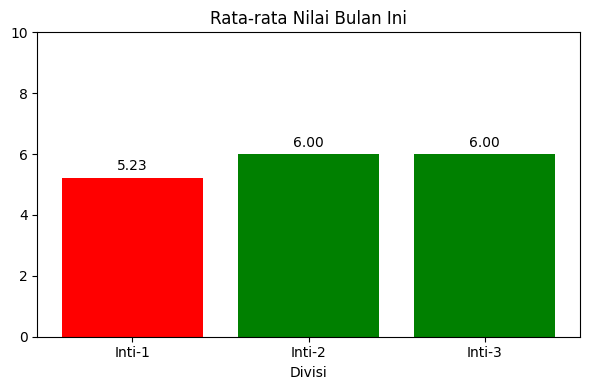

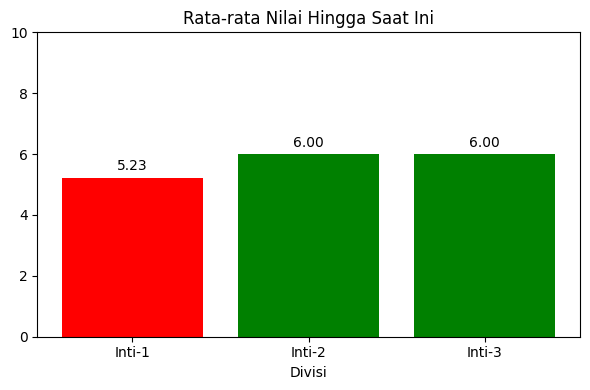

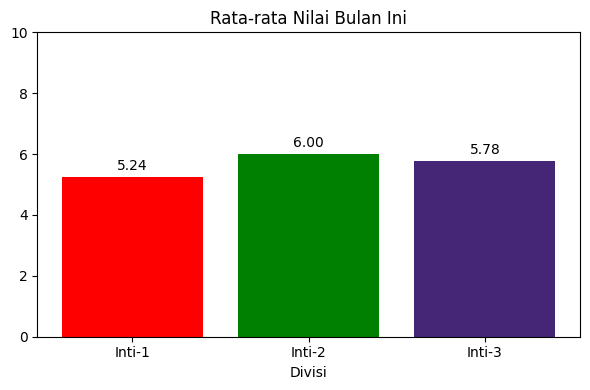

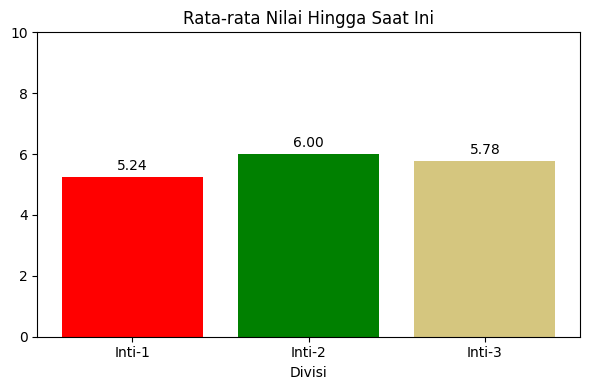

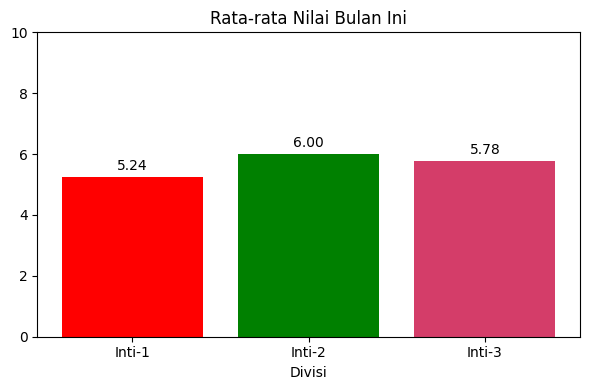

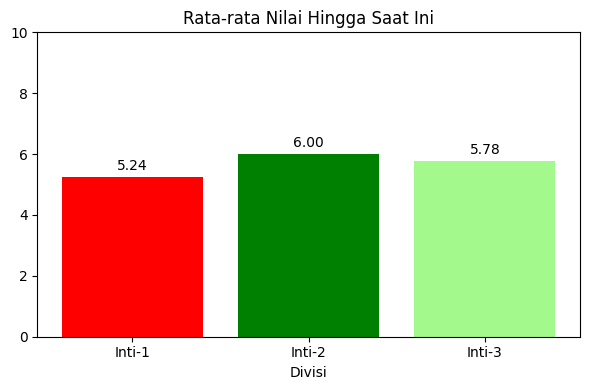

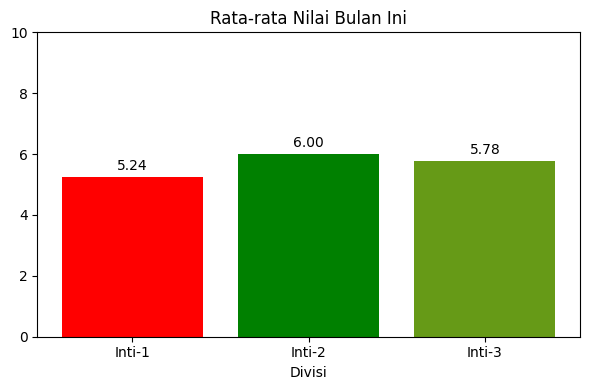

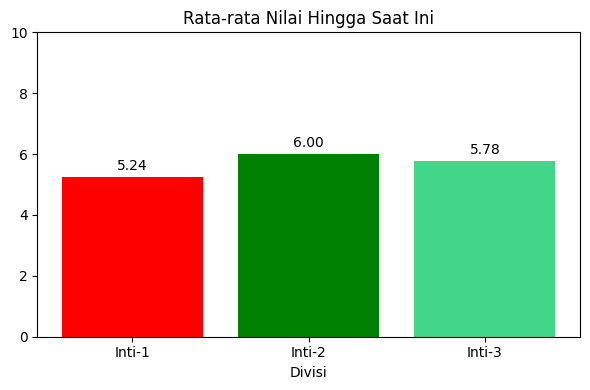

In [1875]:
if __name__ == "__main__":
    # Any setup required before starting the process
    # (like checking for credential file existence maybe)
    if not os.path.exists(JSON_PATH):
         print(f"ERROR: Credential file not found at {JSON_PATH}")
         # Optionally show a Tkinter error box even before root is created
         # temp_root = tk.Tk(); temp_root.withdraw() # Hide temp root
         # messagebox.showerror("Startup Error", f"Credential file missing:\n{JSON_PATH}")
         # temp_root.destroy()
         sys.exit("Credential file missing.") # Exit if critical file missing

    main_process()